## CSCI 32092 | Data Mining and Data Warehousing
## Assignment 02 - Project

### Step 1
Understand and review the dataset.<br>
Deliverables:
* Data understanding summary
* Initial data quality report

### EXTRACT of ETL

In [1]:
import pandas as pd

df = pd.read_csv('sales-data-samples.csv')
df.head()

/Users/subhashbandaraekanayake/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


,OrderDate,Category,City,Country,CustomerName,Discount,OrderID,PostalCode,ProductName,Profit,...,DaystoShipActual,SalesForecast,ShipStatus,DaystoShipScheduled,OrderProfitable,SalesperCustomer,ProfitRatio,SalesaboveTarget,latitude,longitude
0,2011-01-04T00:00:00.000Z,Office Supplies,Houston,United States,Darren Powers,0.2,CA-2011-103800,77095,"Message Book, Wirebound, Four 5 1/2 X 4 Forms/...",6,...,4,22,Shipped Early,6,NaN,16.45,33.8,NaN,29.8941,-95.6481
1,2011-01-05T00:00:00.000Z,Office Supplies,Naperville,United States,Phillina Ober,0.2,CA-2011-112326,60540,Avery 508,4,...,4,15,Shipped Early,6,NaN,11.78,36.3,NaN,41.7662,-88.1410
2,2011-01-05T00:00:00.000Z,Office Supplies,Naperville,United States,Phillina Ober,0.8,CA-2011-112326,60540,GBC Standard Plastic Binding Systems Combs,-5,...,4,5,Shipped Early,6,NaN,3.54,-155.0,NaN,41.7662,-88.1410
3,2011-01-05T00:00:00.000Z,Office Supplies,Naperville,United States,Phillina Ober,0.2,CA-2011-112326,60540,SAFCO Boltless Steel Shelving,-65,...,4,357,Shipped Early,6,NaN,272.74,-23.8,NaN,41.7662,-88.1410
4,2011-01-06T00:00:00.000Z,Office Supplies,Philadelphia,United States,Mick Brown,0.2,CA-2011-141817,19143,Avery Hi-Liter EverBold Pen Style Fluorescent ...,5,...,7,26,Shipped Late,6,NaN,19.54,25.0,NaN,39.9448,-75.2288


In [2]:
df.shape 

(9994, 28)

number of columns - 28 <br>
number of raws - 9994

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   OrderDate            9994 non-null   object 
 1   Category             9994 non-null   object 
 2   City                 9994 non-null   object 
 3   Country              9994 non-null   object 
 4   CustomerName         9994 non-null   object 
 5   Discount             9994 non-null   float64
 6   OrderID              9994 non-null   object 
 7   PostalCode           9994 non-null   int64  
 8   ProductName          9994 non-null   object 
 9   Profit               9994 non-null   int64  
 10  Quantity             9994 non-null   int64  
 11  Region               9994 non-null   object 
 12  Sales                9994 non-null   int64  
 13  Segment              9994 non-null   object 
 14  ShipDate             9994 non-null   object 
 15  ShipMode             9994 non-null   o

This shows a pandas DataFrame summary of a dataset with 9994 entries and 28 columns. Here is a simple description of the columns and their data types: <br>

1. OrderDate, Category, City, Country, CustomerName, Segment, ShipMode, State, Sub_Category: These columns contain string data (objects).
2. Discount, Profit, Quantity, Sales, DaystoShipActual, SalesForecast: These columns have numerical data (integers and floats).
3. OrderID, PostalCode, ProductName: Object data type, likely strings.
4. Latitude, Longitude: Numerical data of type float.

In [4]:
df.describe()

,Discount,PostalCode,Profit,Quantity,Sales,DaystoShipActual,SalesForecast,DaystoShipScheduled,OrderProfitable,SalesperCustomer,ProfitRatio,SalesaboveTarget,latitude,longitude
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,0.0,9994.000000,9994.000000,0.0,9994.000000,9994.000000
mean,0.156203,55190.379428,28.651891,3.789574,229.873324,3.958875,301.200620,4.320692,NaN,229.857992,12.037092,NaN,37.787222,-94.360212
std,0.206452,32063.693350,234.255712,2.225110,623.248946,1.747097,816.700059,2.176059,NaN,623.245119,46.677878,NaN,4.884539,18.058618
min,0.000000,1040.000000,-6600.000000,1.000000,0.000000,0.000000,1.000000,0.000000,NaN,0.440000,-275.000000,NaN,25.476600,-123.099800
25%,0.000000,23223.000000,2.000000,2.000000,17.000000,3.000000,23.000000,3.000000,NaN,17.280000,7.500000,NaN,34.011600,-117.252100
50%,0.200000,56430.500000,9.000000,3.000000,54.500000,4.000000,71.000000,6.000000,NaN,54.490000,27.000000,NaN,38.790200,-87.761150
75%,0.200000,90008.000000,29.000000,5.000000,210.000000,5.000000,275.000000,6.000000,NaN,209.940000,36.300000,NaN,40.801100,-77.394800
max,0.800000,99301.000000,8400.000000,14.000000,22638.000000,7.000000,29665.000000,6.000000,NaN,22638.480000,50.000000,NaN,48.797400,-68.791800


In [5]:
df.columns #showing all columns

Index(['OrderDate', 'Category', 'City', 'Country', 'CustomerName', 'Discount',
       'OrderID', 'PostalCode', 'ProductName', 'Profit', 'Quantity', 'Region',
       'Sales', 'Segment', 'ShipDate', 'ShipMode', 'State', 'Sub_Category',
       'DaystoShipActual', 'SalesForecast', 'ShipStatus',
       'DaystoShipScheduled', 'OrderProfitable', 'SalesperCustomer',
       'ProfitRatio', 'SalesaboveTarget', 'latitude', 'longitude'],
      dtype='object')

In [6]:
df.dtypes 

OrderDate               object
Category                object
City                    object
Country                 object
CustomerName            object
Discount               float64
OrderID                 object
PostalCode               int64
ProductName             object
Profit                   int64
Quantity                 int64
Region                  object
Sales                    int64
Segment                 object
ShipDate                object
ShipMode                object
State                   object
Sub_Category            object
DaystoShipActual         int64
SalesForecast            int64
ShipStatus              object
DaystoShipScheduled      int64
OrderProfitable        float64
SalesperCustomer       float64
ProfitRatio            float64
SalesaboveTarget       float64
latitude               float64
longitude              float64
dtype: object

According to above data type of 'OrderDate' and 'ShipDate' should convert to DateTime data type

### Data Understanding Summary:

The dataset contains 9994 records with 28 columns, representing sales and customer-related information. The dataset includes the following types of columns:

* **Categorical (Object Type)**:

  * Includes fields like `OrderDate`, `Category`, `City`, `Country`, `CustomerName`, `ProductName`, `Region`, `Segment`, `ShipDate`, `ShipMode`, `State`, `Sub_Category`, and `ShipStatus`. These columns provide descriptive information about the sales transactions and customer details.

* **Numerical (Integer and Float Types)**:

  * Columns like `Discount`, `Profit`, `Quantity`, `Sales`, `DaystoShipActual`, `SalesForecast`, `DaystoShipScheduled`, `SalesperCustomer`, `ProfitRatio`, `SalesaboveTarget`, `latitude`, and `longitude` contain numerical data, which can be used for analysis such as profit calculations, sales performance, and geographic data.

* **Missing Values**:

  * `OrderProfitable` and `SalesaboveTarget` have missing (NaN) values, indicating that these columns might need further investigation or imputation to handle the missing data.

### Initial Data Quality Report:

* **Total Entries**: 9994 rows.
* **Non-Null Data**: Most columns have 9994 non-null values, except for the `OrderProfitable` and `SalesaboveTarget` columns.
* **Data Types**:

  * `object`: 14 columns (categorical data).
  * `int64`: 7 columns (integer data).
  * `float64`: 7 columns (floating-point numerical data).
* **Missing Data**:

  * `OrderProfitable` and `SalesaboveTarget` contain only missing values (NaN), which should be addressed based on business needs.
* **Memory Usage**: The dataset occupies 2.1 MB of memory.

This dataset is well-structured for analysis but requires handling of missing values and potential conversions (e.g., dates) before deeper analysis or model building.


### Step 2
Data cleaning, preprocessing, and feature engineering. <br>
Deliverables:
* Cleaned dataset
* Python script or notebook

### TRANSFORM of ETL

### Data cleaning and preprocessing

1. Handeling missing values

In [7]:
df.isnull().sum() #checking for null values

OrderDate                 0
Category                  0
City                      0
Country                   0
CustomerName              0
Discount                  0
OrderID                   0
PostalCode                0
ProductName               0
Profit                    0
Quantity                  0
Region                    0
Sales                     0
Segment                   0
ShipDate                  0
ShipMode                  0
State                     0
Sub_Category              0
DaystoShipActual          0
SalesForecast             0
ShipStatus                0
DaystoShipScheduled       0
OrderProfitable        9994
SalesperCustomer          0
ProfitRatio               0
SalesaboveTarget       9994
latitude                  0
longitude                 0
dtype: int64

'OrderProfitable' and 'SalesaboveTarget' have null values and should remove these columns

In [8]:
df = df.drop(['OrderProfitable','SalesaboveTarget'], axis=1 )
df.head(5)

,OrderDate,Category,City,Country,CustomerName,Discount,OrderID,PostalCode,ProductName,Profit,...,State,Sub_Category,DaystoShipActual,SalesForecast,ShipStatus,DaystoShipScheduled,SalesperCustomer,ProfitRatio,latitude,longitude
0,2011-01-04T00:00:00.000Z,Office Supplies,Houston,United States,Darren Powers,0.2,CA-2011-103800,77095,"Message Book, Wirebound, Four 5 1/2 X 4 Forms/...",6,...,Texas,Paper,4,22,Shipped Early,6,16.45,33.8,29.8941,-95.6481
1,2011-01-05T00:00:00.000Z,Office Supplies,Naperville,United States,Phillina Ober,0.2,CA-2011-112326,60540,Avery 508,4,...,Illinois,Labels,4,15,Shipped Early,6,11.78,36.3,41.7662,-88.1410
2,2011-01-05T00:00:00.000Z,Office Supplies,Naperville,United States,Phillina Ober,0.8,CA-2011-112326,60540,GBC Standard Plastic Binding Systems Combs,-5,...,Illinois,Binders,4,5,Shipped Early,6,3.54,-155.0,41.7662,-88.1410
3,2011-01-05T00:00:00.000Z,Office Supplies,Naperville,United States,Phillina Ober,0.2,CA-2011-112326,60540,SAFCO Boltless Steel Shelving,-65,...,Illinois,Storage,4,357,Shipped Early,6,272.74,-23.8,41.7662,-88.1410
4,2011-01-06T00:00:00.000Z,Office Supplies,Philadelphia,United States,Mick Brown,0.2,CA-2011-141817,19143,Avery Hi-Liter EverBold Pen Style Fluorescent ...,5,...,Pennsylvania,Art,7,26,Shipped Late,6,19.54,25.0,39.9448,-75.2288


In [9]:
df.isnull().sum() #after removing check again for nulls

OrderDate              0
Category               0
City                   0
Country                0
CustomerName           0
Discount               0
OrderID                0
PostalCode             0
ProductName            0
Profit                 0
Quantity               0
Region                 0
Sales                  0
Segment                0
ShipDate               0
ShipMode               0
State                  0
Sub_Category           0
DaystoShipActual       0
SalesForecast          0
ShipStatus             0
DaystoShipScheduled    0
SalesperCustomer       0
ProfitRatio            0
latitude               0
longitude              0
dtype: int64

2. Removing duplicate values

In [10]:
df.duplicated().sum() #check for duplicate values

1

In [11]:
df = df.drop_duplicates() #drop duplicates

In [12]:
df.duplicated().sum() #after droping check again for duplicate values

0

3. Set up data types for appropriate columns

In [13]:
df.dtypes #check data types

OrderDate               object
Category                object
City                    object
Country                 object
CustomerName            object
Discount               float64
OrderID                 object
PostalCode               int64
ProductName             object
Profit                   int64
Quantity                 int64
Region                  object
Sales                    int64
Segment                 object
ShipDate                object
ShipMode                object
State                   object
Sub_Category            object
DaystoShipActual         int64
SalesForecast            int64
ShipStatus              object
DaystoShipScheduled      int64
SalesperCustomer       float64
ProfitRatio            float64
latitude               float64
longitude              float64
dtype: object

'OrderDate' and 'ShipDate' has 'object' data type should convert into 'datetime'

In [14]:
df['OrderDate'] = pd.to_datetime(df['OrderDate']) #convert into 'datetime' data type
df['ShipDate'] = pd.to_datetime(df['ShipDate'])
df.dtypes

OrderDate              datetime64[ns, UTC]
Category                            object
City                                object
Country                             object
CustomerName                        object
Discount                           float64
OrderID                             object
PostalCode                           int64
ProductName                         object
Profit                               int64
Quantity                             int64
Region                              object
Sales                                int64
Segment                             object
ShipDate               datetime64[ns, UTC]
ShipMode                            object
State                               object
Sub_Category                        object
DaystoShipActual                     int64
SalesForecast                        int64
ShipStatus                          object
DaystoShipScheduled                  int64
SalesperCustomer                   float64
ProfitRatio

In [15]:
df.head(5)

,OrderDate,Category,City,Country,CustomerName,Discount,OrderID,PostalCode,ProductName,Profit,...,State,Sub_Category,DaystoShipActual,SalesForecast,ShipStatus,DaystoShipScheduled,SalesperCustomer,ProfitRatio,latitude,longitude
0,2011-01-04 00:00:00+00:00,Office Supplies,Houston,United States,Darren Powers,0.2,CA-2011-103800,77095,"Message Book, Wirebound, Four 5 1/2 X 4 Forms/...",6,...,Texas,Paper,4,22,Shipped Early,6,16.45,33.8,29.8941,-95.6481
1,2011-01-05 00:00:00+00:00,Office Supplies,Naperville,United States,Phillina Ober,0.2,CA-2011-112326,60540,Avery 508,4,...,Illinois,Labels,4,15,Shipped Early,6,11.78,36.3,41.7662,-88.1410
2,2011-01-05 00:00:00+00:00,Office Supplies,Naperville,United States,Phillina Ober,0.8,CA-2011-112326,60540,GBC Standard Plastic Binding Systems Combs,-5,...,Illinois,Binders,4,5,Shipped Early,6,3.54,-155.0,41.7662,-88.1410
3,2011-01-05 00:00:00+00:00,Office Supplies,Naperville,United States,Phillina Ober,0.2,CA-2011-112326,60540,SAFCO Boltless Steel Shelving,-65,...,Illinois,Storage,4,357,Shipped Early,6,272.74,-23.8,41.7662,-88.1410
4,2011-01-06 00:00:00+00:00,Office Supplies,Philadelphia,United States,Mick Brown,0.2,CA-2011-141817,19143,Avery Hi-Liter EverBold Pen Style Fluorescent ...,5,...,Pennsylvania,Art,7,26,Shipped Late,6,19.54,25.0,39.9448,-75.2288


In [16]:
date_columns = ['OrderDate','ShipDate'] #change date format and remove unnecessary time detail in each date

for col in date_columns:
    df[col] = df[col].dt.strftime('%Y-%m-%d')

In [17]:
df.head(5).T

,0,1,2,3,4
OrderDate,2011-01-04,2011-01-05,2011-01-05,2011-01-05,2011-01-06
Category,Office Supplies,Office Supplies,Office Supplies,Office Supplies,Office Supplies
City,Houston,Naperville,Naperville,Naperville,Philadelphia
Country,United States,United States,United States,United States,United States
CustomerName,Darren Powers,Phillina Ober,Phillina Ober,Phillina Ober,Mick Brown
Discount,0.2,0.2,0.8,0.2,0.2
OrderID,CA-2011-103800,CA-2011-112326,CA-2011-112326,CA-2011-112326,CA-2011-141817
PostalCode,77095,60540,60540,60540,19143
ProductName,"Message Book, Wirebound, Four 5 1/2 X 4 Forms/...",Avery 508,GBC Standard Plastic Binding Systems Combs,SAFCO Boltless Steel Shelving,Avery Hi-Liter EverBold Pen Style Fluorescent ...
Profit,6,4,-5,-65,5


In [18]:
df['OrderDate'] = pd.to_datetime(df['OrderDate']) #convert into 'datetime' data type
df['ShipDate'] = pd.to_datetime(df['ShipDate'])
df.dtypes

OrderDate              datetime64[ns]
Category                       object
City                           object
Country                        object
CustomerName                   object
Discount                      float64
OrderID                        object
PostalCode                      int64
ProductName                    object
Profit                          int64
Quantity                        int64
Region                         object
Sales                           int64
Segment                        object
ShipDate               datetime64[ns]
ShipMode                       object
State                          object
Sub_Category                   object
DaystoShipActual                int64
SalesForecast                   int64
ShipStatus                     object
DaystoShipScheduled             int64
SalesperCustomer              float64
ProfitRatio                   float64
latitude                      float64
longitude                     float64
dtype: objec

In [19]:
df.head(5)

,OrderDate,Category,City,Country,CustomerName,Discount,OrderID,PostalCode,ProductName,Profit,...,State,Sub_Category,DaystoShipActual,SalesForecast,ShipStatus,DaystoShipScheduled,SalesperCustomer,ProfitRatio,latitude,longitude
0,2011-01-04,Office Supplies,Houston,United States,Darren Powers,0.2,CA-2011-103800,77095,"Message Book, Wirebound, Four 5 1/2 X 4 Forms/...",6,...,Texas,Paper,4,22,Shipped Early,6,16.45,33.8,29.8941,-95.6481
1,2011-01-05,Office Supplies,Naperville,United States,Phillina Ober,0.2,CA-2011-112326,60540,Avery 508,4,...,Illinois,Labels,4,15,Shipped Early,6,11.78,36.3,41.7662,-88.1410
2,2011-01-05,Office Supplies,Naperville,United States,Phillina Ober,0.8,CA-2011-112326,60540,GBC Standard Plastic Binding Systems Combs,-5,...,Illinois,Binders,4,5,Shipped Early,6,3.54,-155.0,41.7662,-88.1410
3,2011-01-05,Office Supplies,Naperville,United States,Phillina Ober,0.2,CA-2011-112326,60540,SAFCO Boltless Steel Shelving,-65,...,Illinois,Storage,4,357,Shipped Early,6,272.74,-23.8,41.7662,-88.1410
4,2011-01-06,Office Supplies,Philadelphia,United States,Mick Brown,0.2,CA-2011-141817,19143,Avery Hi-Liter EverBold Pen Style Fluorescent ...,5,...,Pennsylvania,Art,7,26,Shipped Late,6,19.54,25.0,39.9448,-75.2288


4. Label encoding categorical data

4.1 label encoding for 'Category' column

In [20]:
df['Category'].value_counts() #counting values for unique category

Category
Office Supplies    6026
Furniture          2120
Technology         1847
Name: count, dtype: int64

In [21]:
# Custom mapping
category_map = {
    'Office Supplies': 1,
    'Furniture': 2,
    'Technology': 3
}

df['Category_encoded'] = df['Category'].map(category_map)


4.2 label encoding for 'Region' column

In [22]:
df['Region'].value_counts() #counting values for unique Region

Region
West       3203
East       2847
Central    2323
South      1620
Name: count, dtype: int64

In [23]:
# Custom mapping
category_map = {
    'West': 1,
    'East': 2,
    'Central': 3,
    'South':4
}

df['Region_encoded'] = df['Region'].map(category_map)

4.3 Label encoding for 'Segment' column

In [24]:
df['Segment'].value_counts() #counting values for unique segment

Segment
Consumer       5191
Corporate      3020
Home Office    1782
Name: count, dtype: int64

In [25]:
category_map = {
    'Consumer': 1,
    'Corporate': 2,
    'Home Office': 3
}

df['Segment_encoded'] = df['Segment'].map(category_map)

4.4 Label encoding for 'ShipMode' column

In [26]:
df['ShipMode'].value_counts() #counting values for unique ShipMode

ShipMode
Standard Class    5967
Second Class      1945
First Class       1538
Same Day           543
Name: count, dtype: int64

In [27]:
category_map = {
    'Standard Class': 1,
    'Second Class': 2,
    'First Class': 3,
    'Same Day':4
}

df['ShipMode_encoded'] = df['ShipMode'].map(category_map)

4.5 Label encoding for 'ShipStatus' column

In [28]:
df['ShipStatus'].value_counts() #counting values for unique ShipStatus

ShipStatus
Shipped Early      4907
Shipped Late       2639
Shipped On Time    2447
Name: count, dtype: int64

In [29]:
category_map = {
    'Shipped Early': 1,
    'Shipped Late': 2,
    'Shipped On Time': 3
}

df['ShipStatus_encoded'] = df['ShipStatus'].map(category_map)

4.6 Label encoding for 'Sub_Category' column

In [30]:
df['Sub_Category'].value_counts()

Sub_Category
Binders        1523
Paper          1370
Furnishings     957
Phones          889
Storage         846
Art             796
Accessories     775
Chairs          616
Appliances      466
Labels          364
Tables          319
Envelopes       254
Bookcases       228
Fasteners       217
Supplies        190
Machines        115
Copiers          68
Name: count, dtype: int64

In [31]:
category_map = {
    'Binders': 1,
    'Paper': 2,
    'Furnishings': 3,
    'Phones' : 4,
    'Storage':5,
    'Art':6,
    'Accessories':7,
    'Chairs':8,
    'Appliances':9,
    'Labels':10,
    'Tables':11,
    'Envelopes':12,
    'Bookcases':13,
    'Fasteners':14,
    'Supplies':15,
    'Machines':16,
    'Copiers':17
}

df['Sub_Category_encoded'] = df['Sub_Category'].map(category_map)

In [32]:
df.head(5) #after encoding check dataset

,OrderDate,Category,City,Country,CustomerName,Discount,OrderID,PostalCode,ProductName,Profit,...,SalesperCustomer,ProfitRatio,latitude,longitude,Category_encoded,Region_encoded,Segment_encoded,ShipMode_encoded,ShipStatus_encoded,Sub_Category_encoded
0,2011-01-04,Office Supplies,Houston,United States,Darren Powers,0.2,CA-2011-103800,77095,"Message Book, Wirebound, Four 5 1/2 X 4 Forms/...",6,...,16.45,33.8,29.8941,-95.6481,1,3,1,1,1,2
1,2011-01-05,Office Supplies,Naperville,United States,Phillina Ober,0.2,CA-2011-112326,60540,Avery 508,4,...,11.78,36.3,41.7662,-88.1410,1,3,3,1,1,10
2,2011-01-05,Office Supplies,Naperville,United States,Phillina Ober,0.8,CA-2011-112326,60540,GBC Standard Plastic Binding Systems Combs,-5,...,3.54,-155.0,41.7662,-88.1410,1,3,3,1,1,1
3,2011-01-05,Office Supplies,Naperville,United States,Phillina Ober,0.2,CA-2011-112326,60540,SAFCO Boltless Steel Shelving,-65,...,272.74,-23.8,41.7662,-88.1410,1,3,3,1,1,5
4,2011-01-06,Office Supplies,Philadelphia,United States,Mick Brown,0.2,CA-2011-141817,19143,Avery Hi-Liter EverBold Pen Style Fluorescent ...,5,...,19.54,25.0,39.9448,-75.2288,1,2,1,1,2,6


### Feature engineering

In [33]:
df.dtypes #check again for data types

OrderDate               datetime64[ns]
Category                        object
City                            object
Country                         object
CustomerName                    object
Discount                       float64
OrderID                         object
PostalCode                       int64
ProductName                     object
Profit                           int64
Quantity                         int64
Region                          object
Sales                            int64
Segment                         object
ShipDate                datetime64[ns]
ShipMode                        object
State                           object
Sub_Category                    object
DaystoShipActual                 int64
SalesForecast                    int64
ShipStatus                      object
DaystoShipScheduled              int64
SalesperCustomer               float64
ProfitRatio                    float64
latitude                       float64
longitude                

Drop unnecassary columns

In [34]:
drop_columns = ['Category','Country','CustomerName','Region','Segment','ShipMode','Sub_Category','ShipStatus',]
df_v1 = df.drop(drop_columns, axis=1)
df_v1.head(10)

,OrderDate,City,Discount,OrderID,PostalCode,ProductName,Profit,Quantity,Sales,ShipDate,...,SalesperCustomer,ProfitRatio,latitude,longitude,Category_encoded,Region_encoded,Segment_encoded,ShipMode_encoded,ShipStatus_encoded,Sub_Category_encoded
0,2011-01-04,Houston,0.2,CA-2011-103800,77095,"Message Book, Wirebound, Four 5 1/2 X 4 Forms/...",6,2,16,2011-01-08,...,16.45,33.8,29.8941,-95.6481,1,3,1,1,1,2
1,2011-01-05,Naperville,0.2,CA-2011-112326,60540,Avery 508,4,3,12,2011-01-09,...,11.78,36.3,41.7662,-88.1410,1,3,3,1,1,10
2,2011-01-05,Naperville,0.8,CA-2011-112326,60540,GBC Standard Plastic Binding Systems Combs,-5,2,4,2011-01-09,...,3.54,-155.0,41.7662,-88.1410,1,3,3,1,1,1
3,2011-01-05,Naperville,0.2,CA-2011-112326,60540,SAFCO Boltless Steel Shelving,-65,3,273,2011-01-09,...,272.74,-23.8,41.7662,-88.1410,1,3,3,1,1,5
4,2011-01-06,Philadelphia,0.2,CA-2011-141817,19143,Avery Hi-Liter EverBold Pen Style Fluorescent ...,5,3,20,2011-01-13,...,19.54,25.0,39.9448,-75.2288,1,2,1,1,2,6
5,2011-01-07,Henderson,0.0,CA-2011-167199,42420,Global Deluxe High-Back Managers Chair,746,9,2574,2011-01-11,...,2573.82,29.0,37.8274,-87.5632,2,4,3,1,1,8
6,2011-01-07,Athens,0.0,CA-2011-106054,30605,"Dixon Prang Watercolor Pencils, 10-Color Set w...",5,3,13,2011-01-08,...,12.78,41.0,33.9321,-83.3525,1,4,2,3,3,6
7,2011-01-07,Henderson,0.0,CA-2011-167199,42420,"Alliance Super-Size Bands, Assorted Sizes",0,4,31,2011-01-11,...,31.12,1.0,37.8274,-87.5632,1,4,3,1,1,14
8,2011-01-07,Henderson,0.0,CA-2011-167199,42420,Ibico Hi-Tech Manual Binding System,274,2,610,2011-01-11,...,609.98,45.0,37.8274,-87.5632,1,4,3,1,1,1
9,2011-01-07,Henderson,0.0,CA-2011-167199,42420,Rogers Handheld Barrel Pencil Sharpener,1,2,5,2011-01-11,...,5.48,27.0,37.8274,-87.5632,1,4,3,1,1,6


In [35]:
df_v1.shape #reduced fetures from 28 into 24

(9993, 24)

In [36]:
df_v1.dtypes

OrderDate               datetime64[ns]
City                            object
Discount                       float64
OrderID                         object
PostalCode                       int64
ProductName                     object
Profit                           int64
Quantity                         int64
Sales                            int64
ShipDate                datetime64[ns]
State                           object
DaystoShipActual                 int64
SalesForecast                    int64
DaystoShipScheduled              int64
SalesperCustomer               float64
ProfitRatio                    float64
latitude                       float64
longitude                      float64
Category_encoded                 int64
Region_encoded                   int64
Segment_encoded                  int64
ShipMode_encoded                 int64
ShipStatus_encoded               int64
Sub_Category_encoded             int64
dtype: object

### Step 3
Shema Design.<br>
Deliverables:
* Justification for schema choice
* Schema Diagram
* ER Diagram showing table relationships

1. Justification for select star schema

The Star Schema is a great choice for your project because it offers a simple and clear structure, with the Fact Table (e.g., FactSales) at the center and Dimension Tables (e.g., DimTime, DimCustomer, DimProduct, DimShipping) around it. This design makes querying easy and fast, especially for business analysis like sales by customer or product. It helps to minimize data redundancy and improves query performance. The schema also makes time-based analysis (like sales trends) easier and can scale as your business grows, allowing you to add new dimensions without disrupting the existing structure. Overall, it's efficient, flexible, and perfect for generating reports and insights.

2. Star schema design

![star schema.drawio.png](<attachment:star schema.drawio.png>)
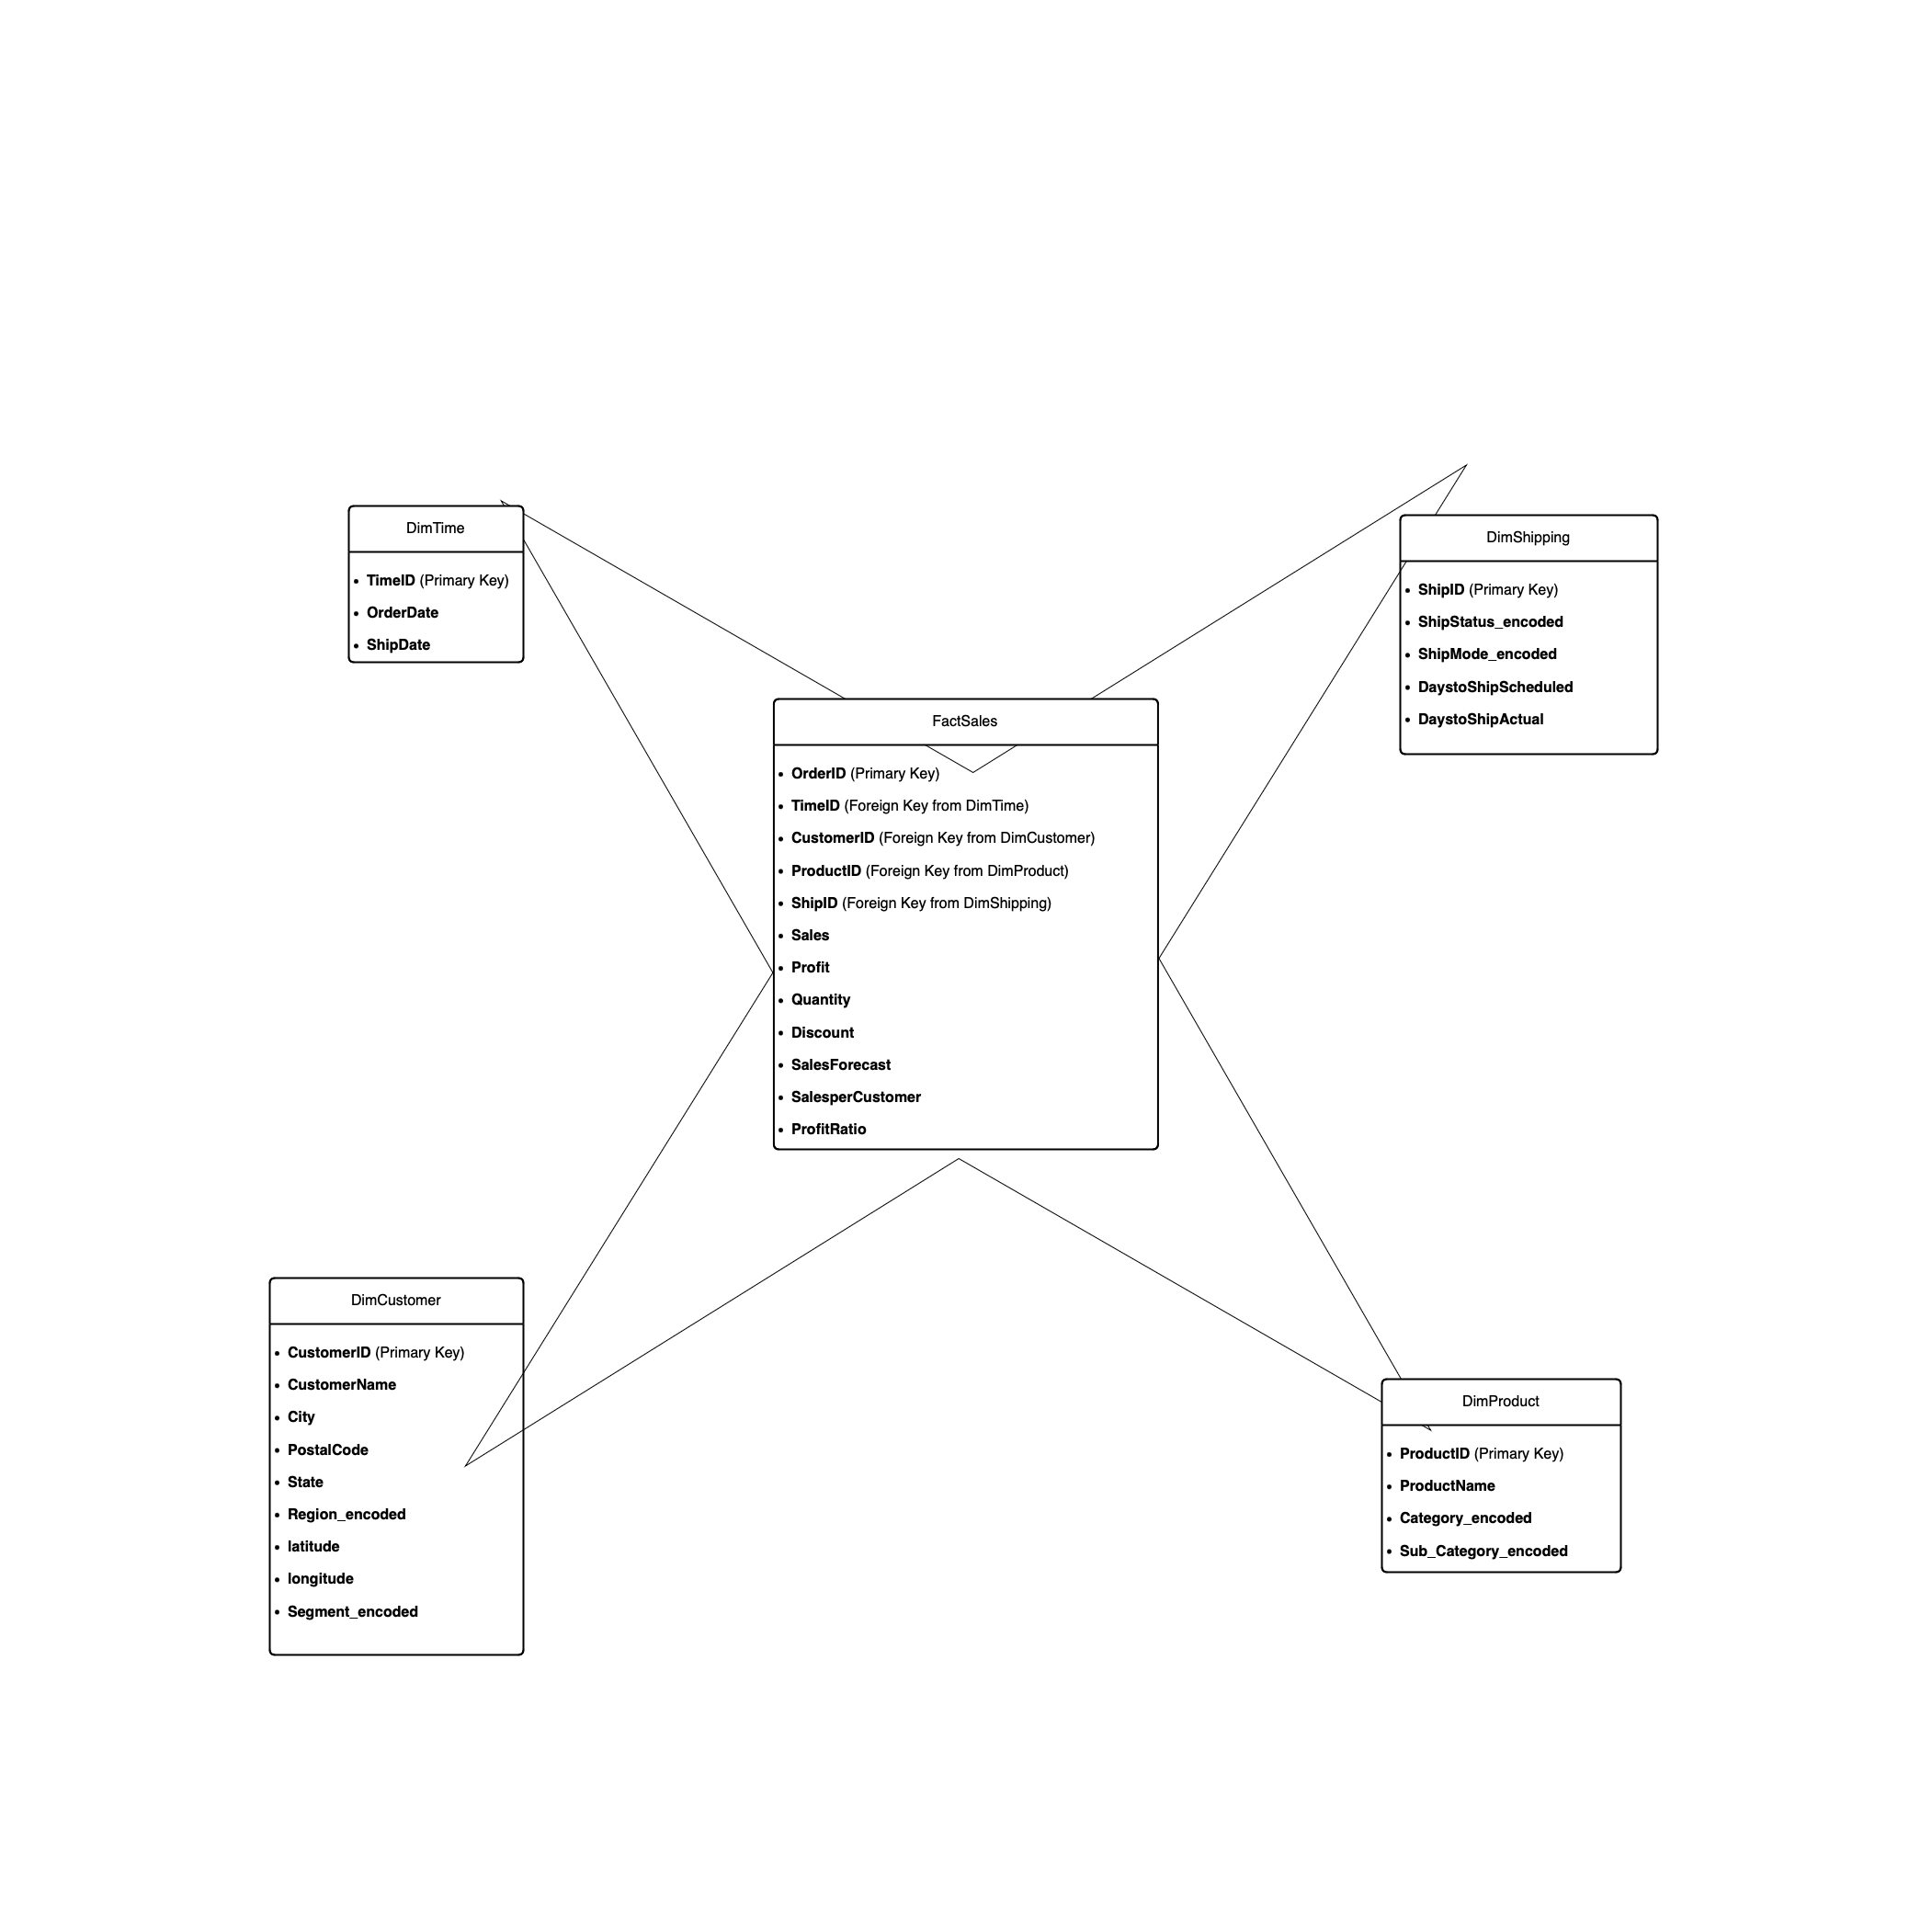

3.ER diagram

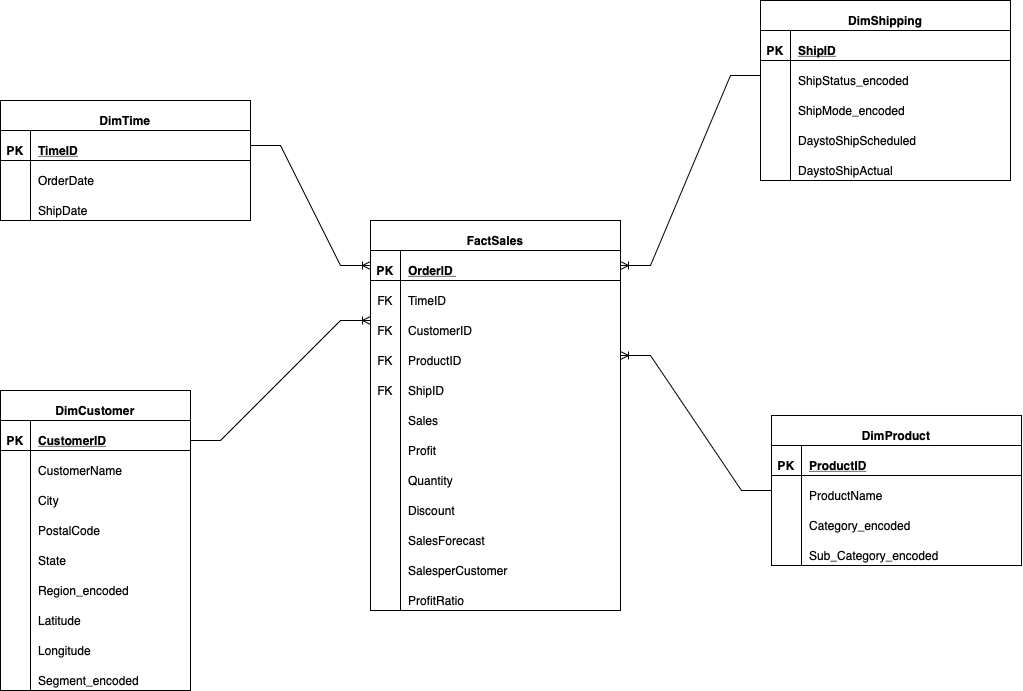

### Step 4
Implementing the in Snowflake (or Similar Warehouse).<br>
Create tables in Snowflake according to the schema design and load cleaned data into the appropriate tables.<br>
Deliverables:
* SQL scripts for schema creation
* Screenshots or logs showing successful data load

#### Load cleaned data into STAGE area of snowflake schema

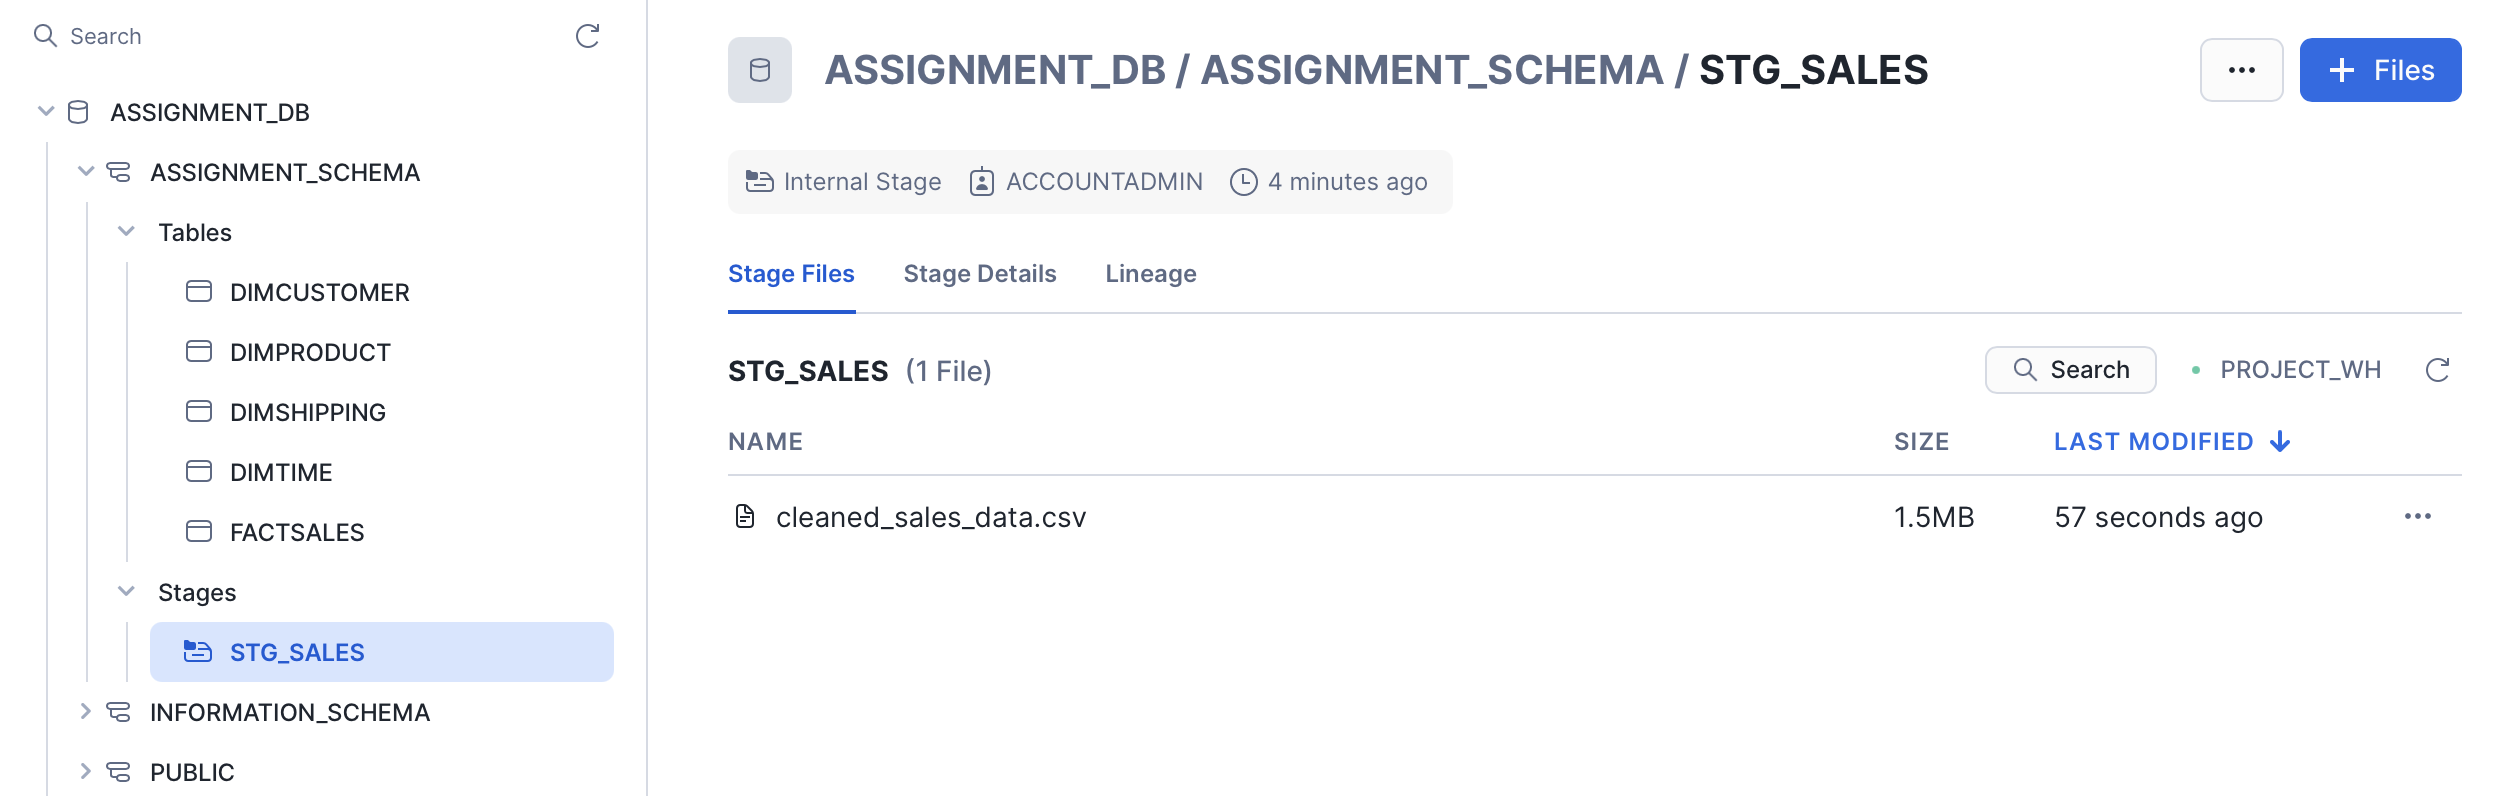

Create star schema in snowflake using SQL scripts

1. SQL script for FACTSALES


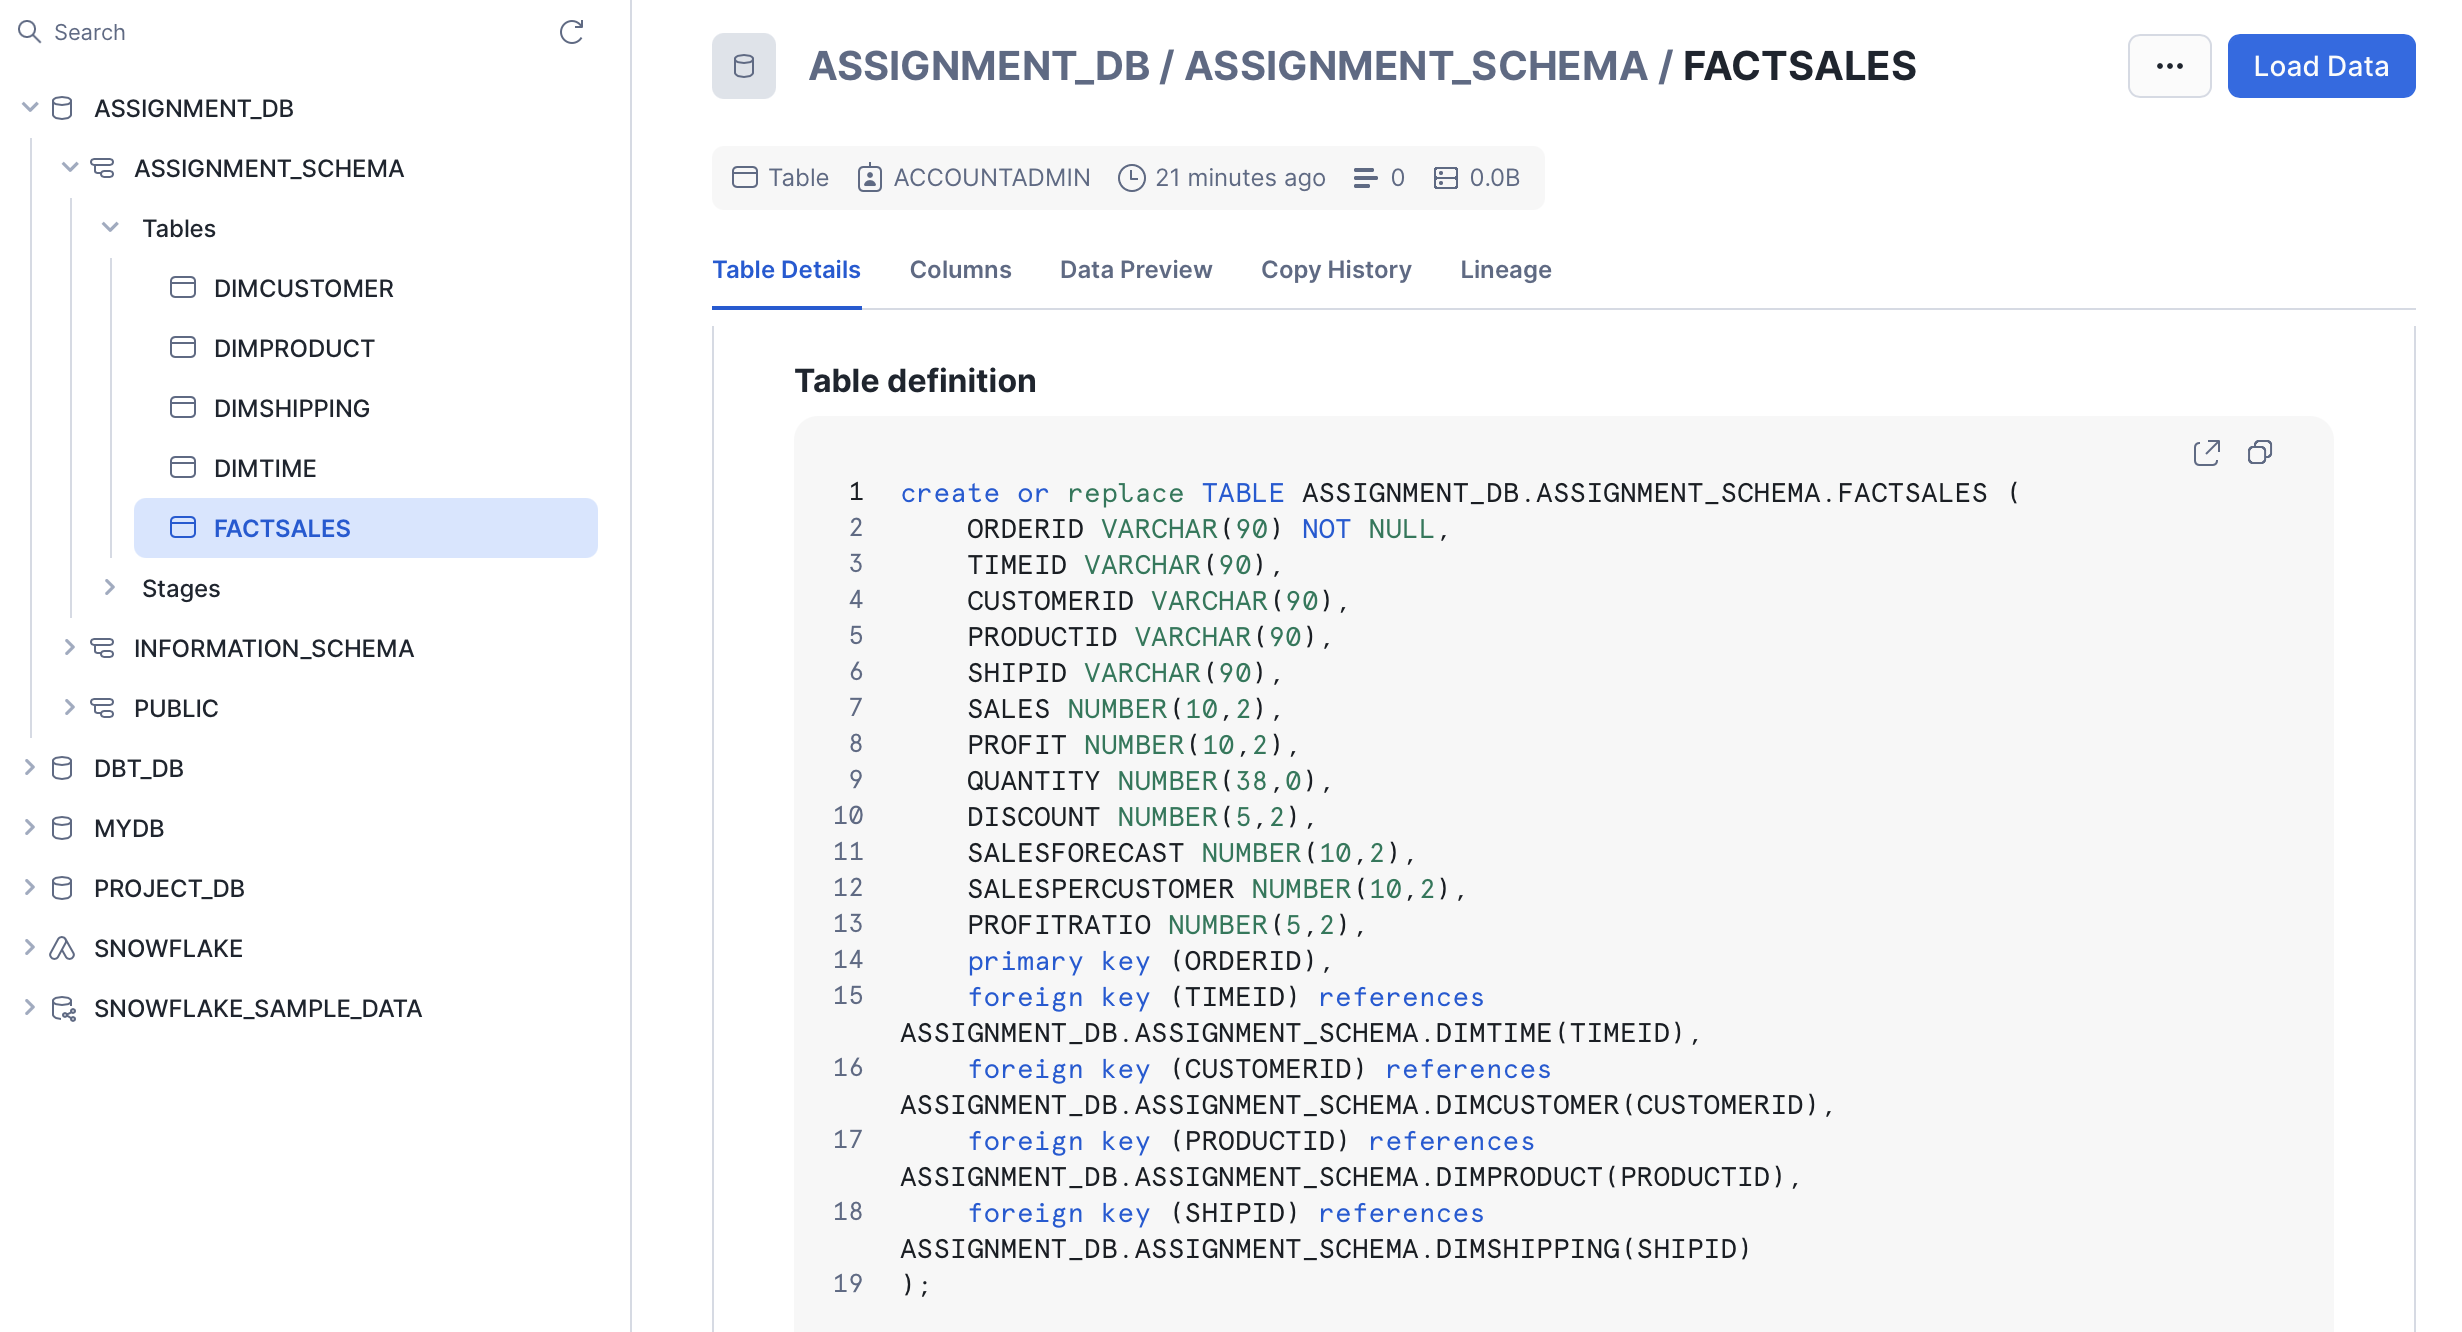

2. SQL script for DIMTIME


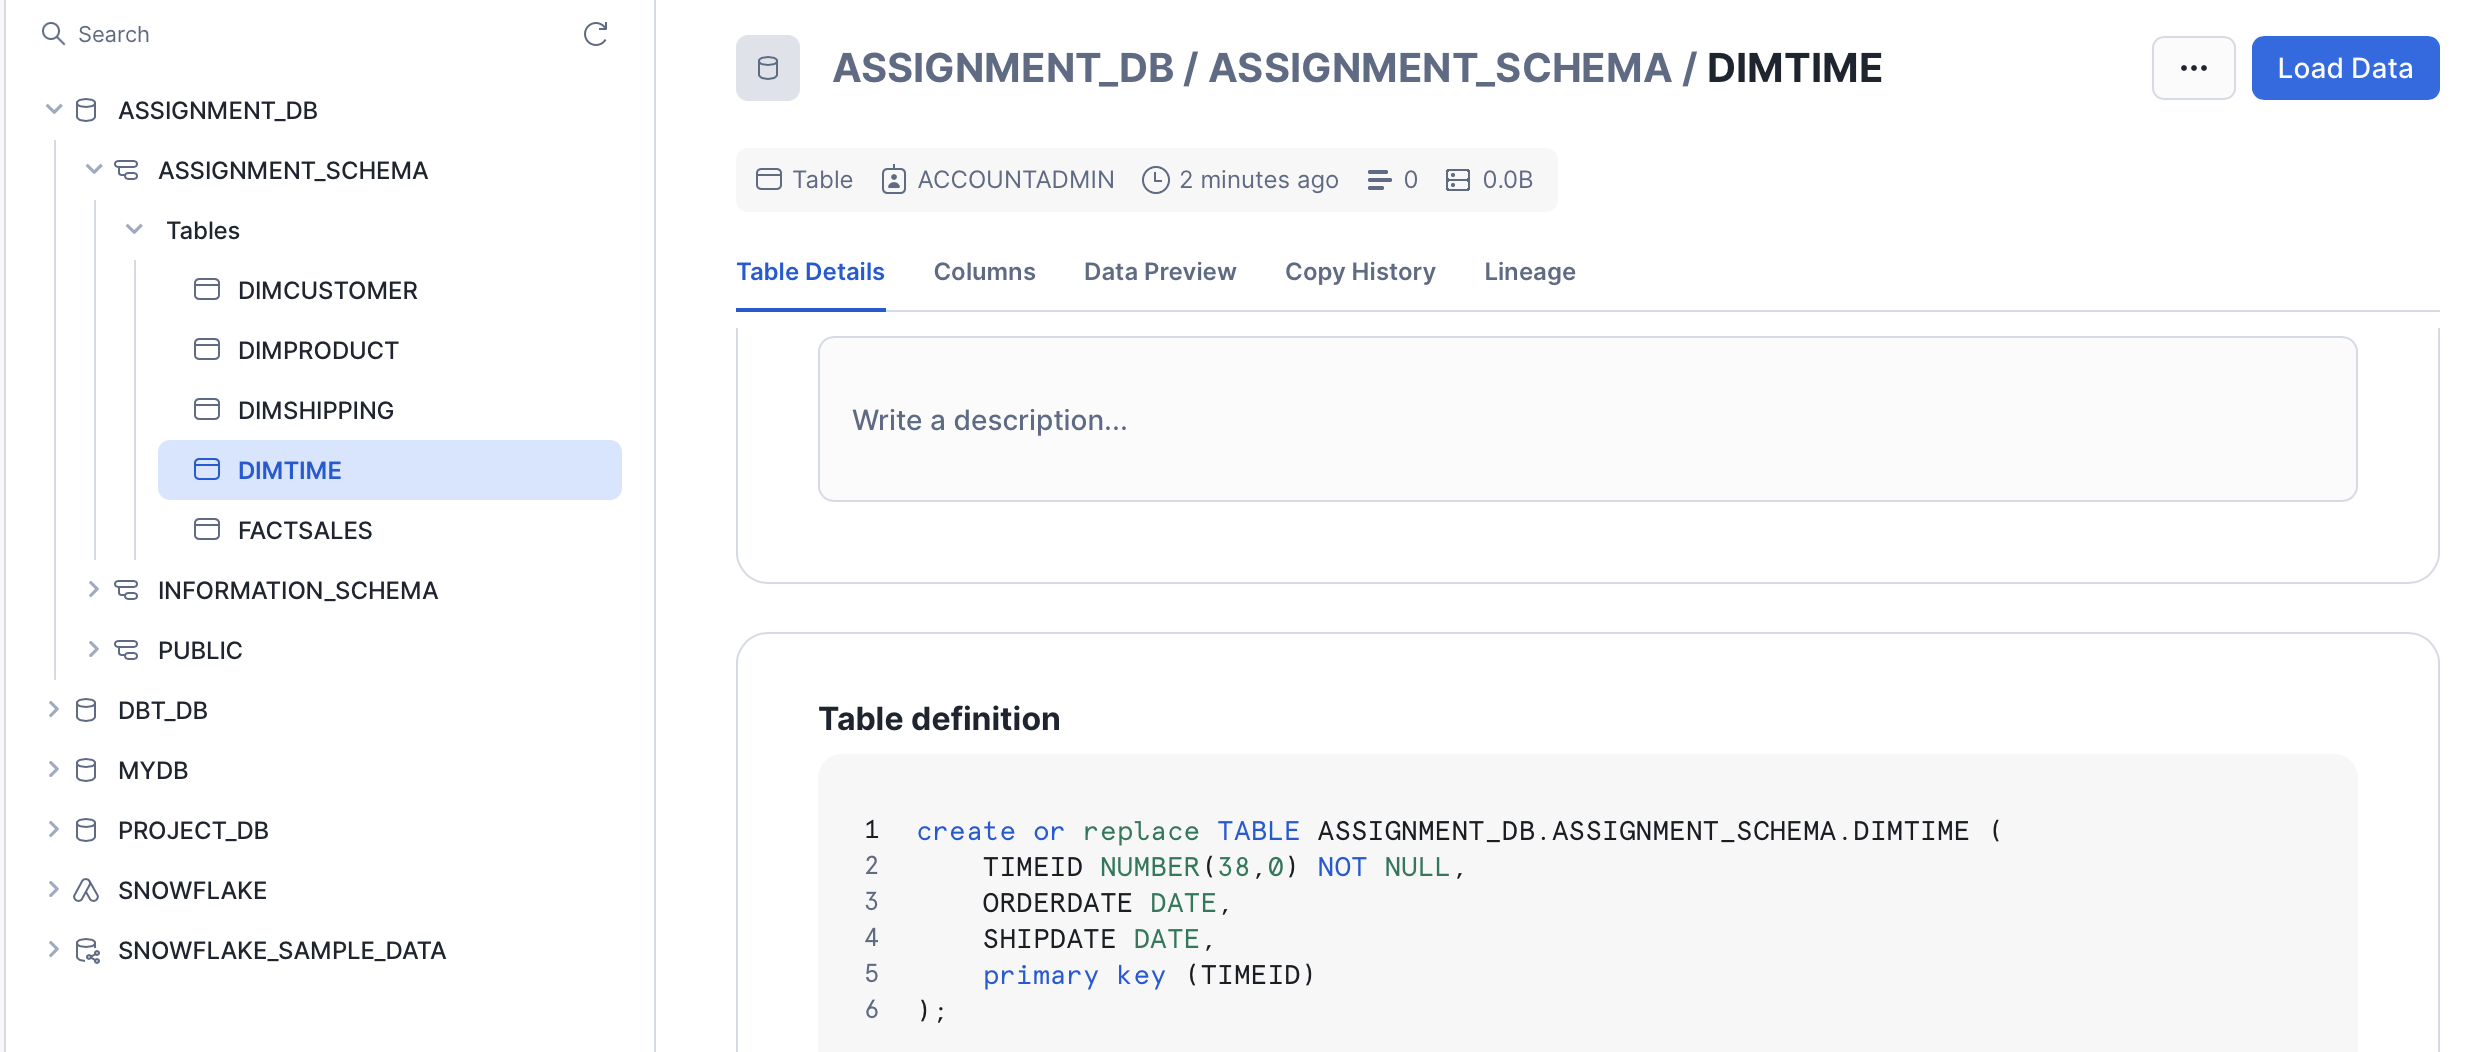

3. SQL script for DIMSHIPPING


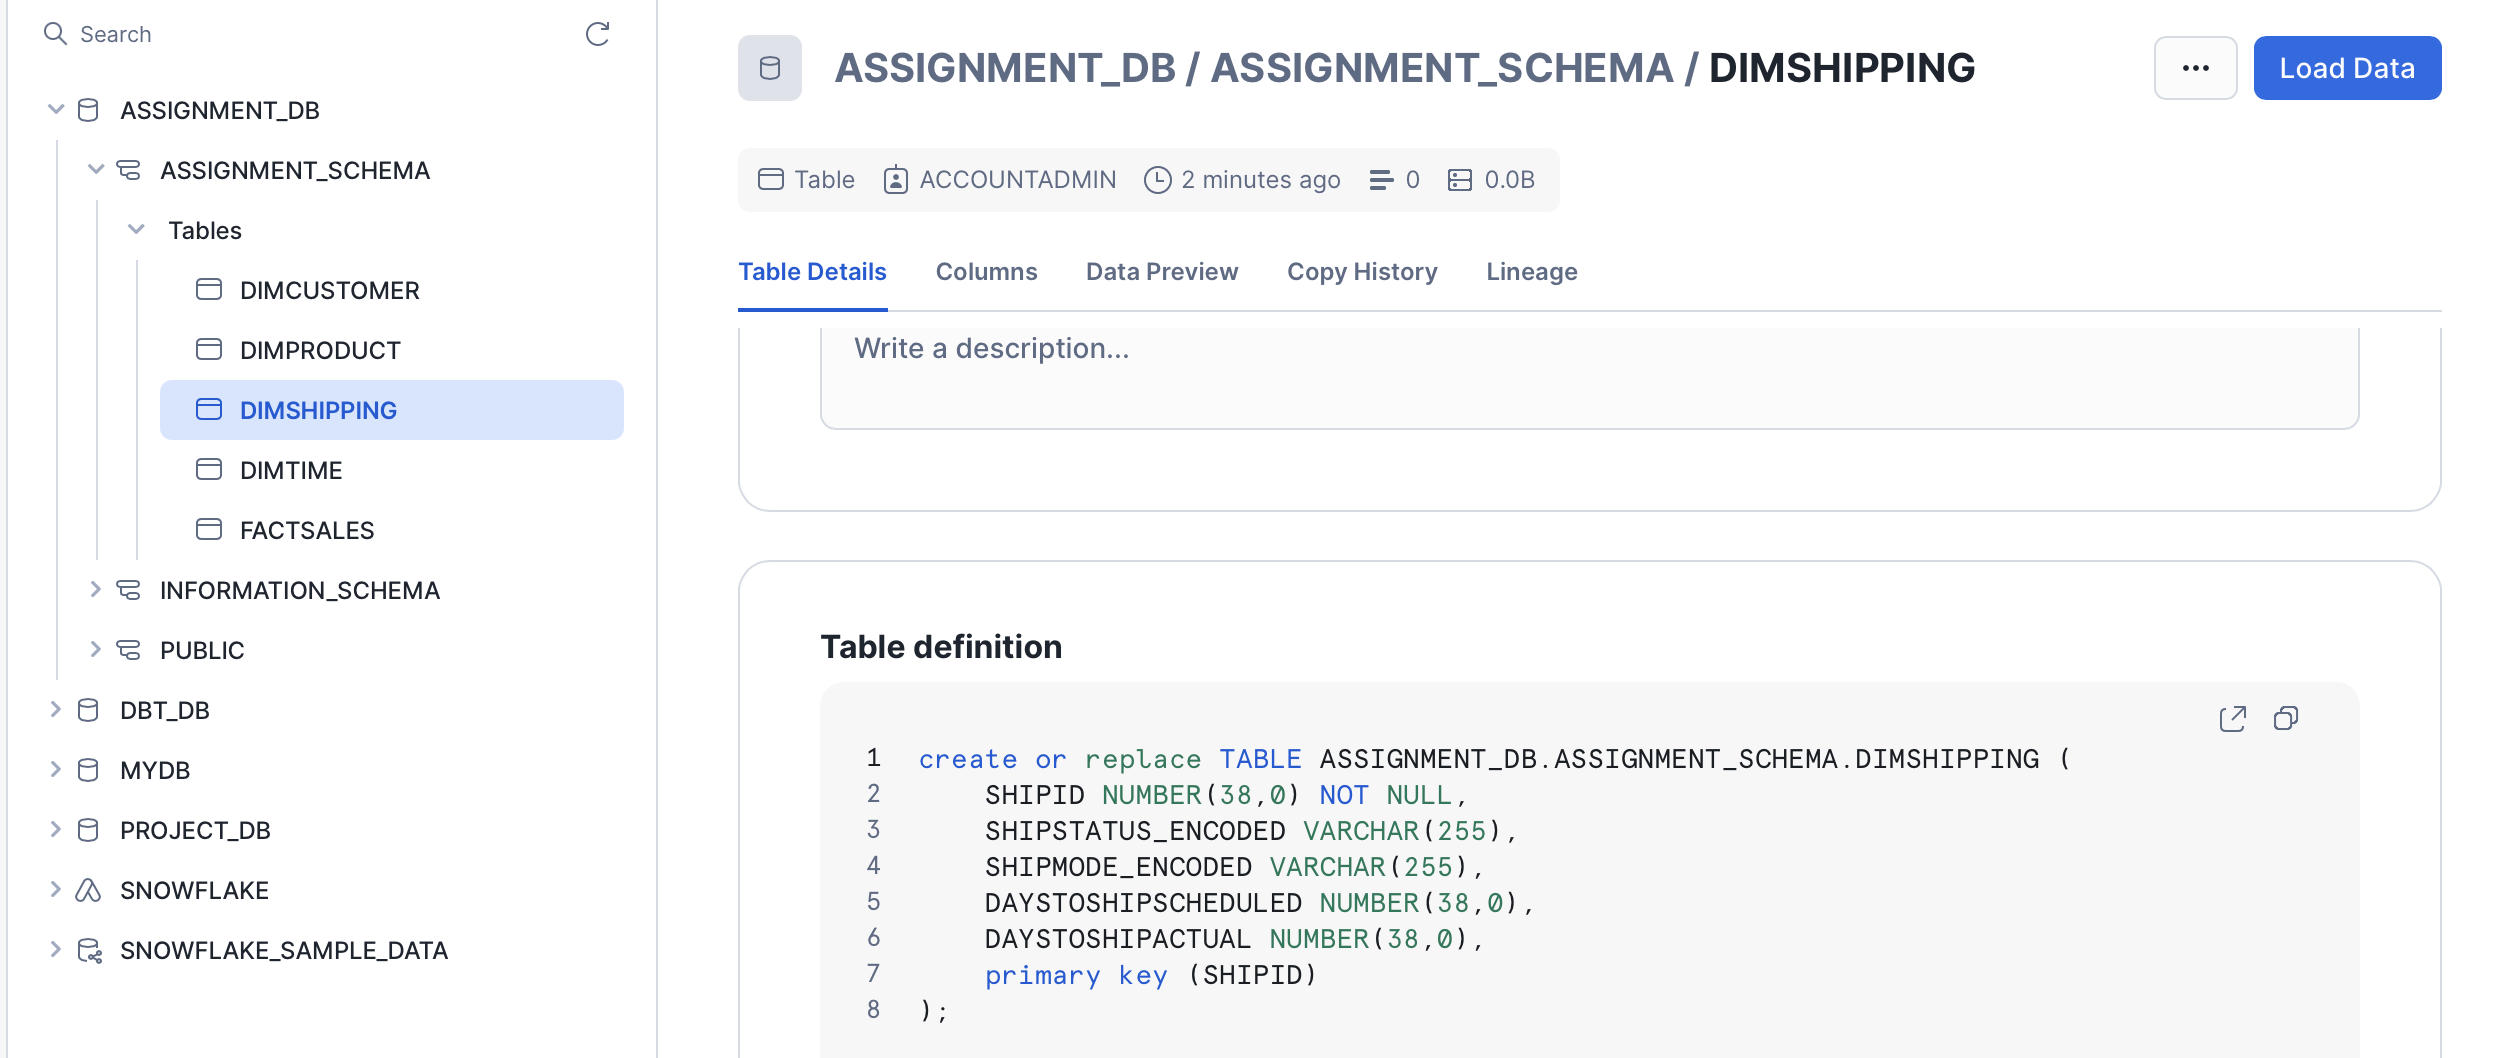

4. SQL script for DIMPRODUCT


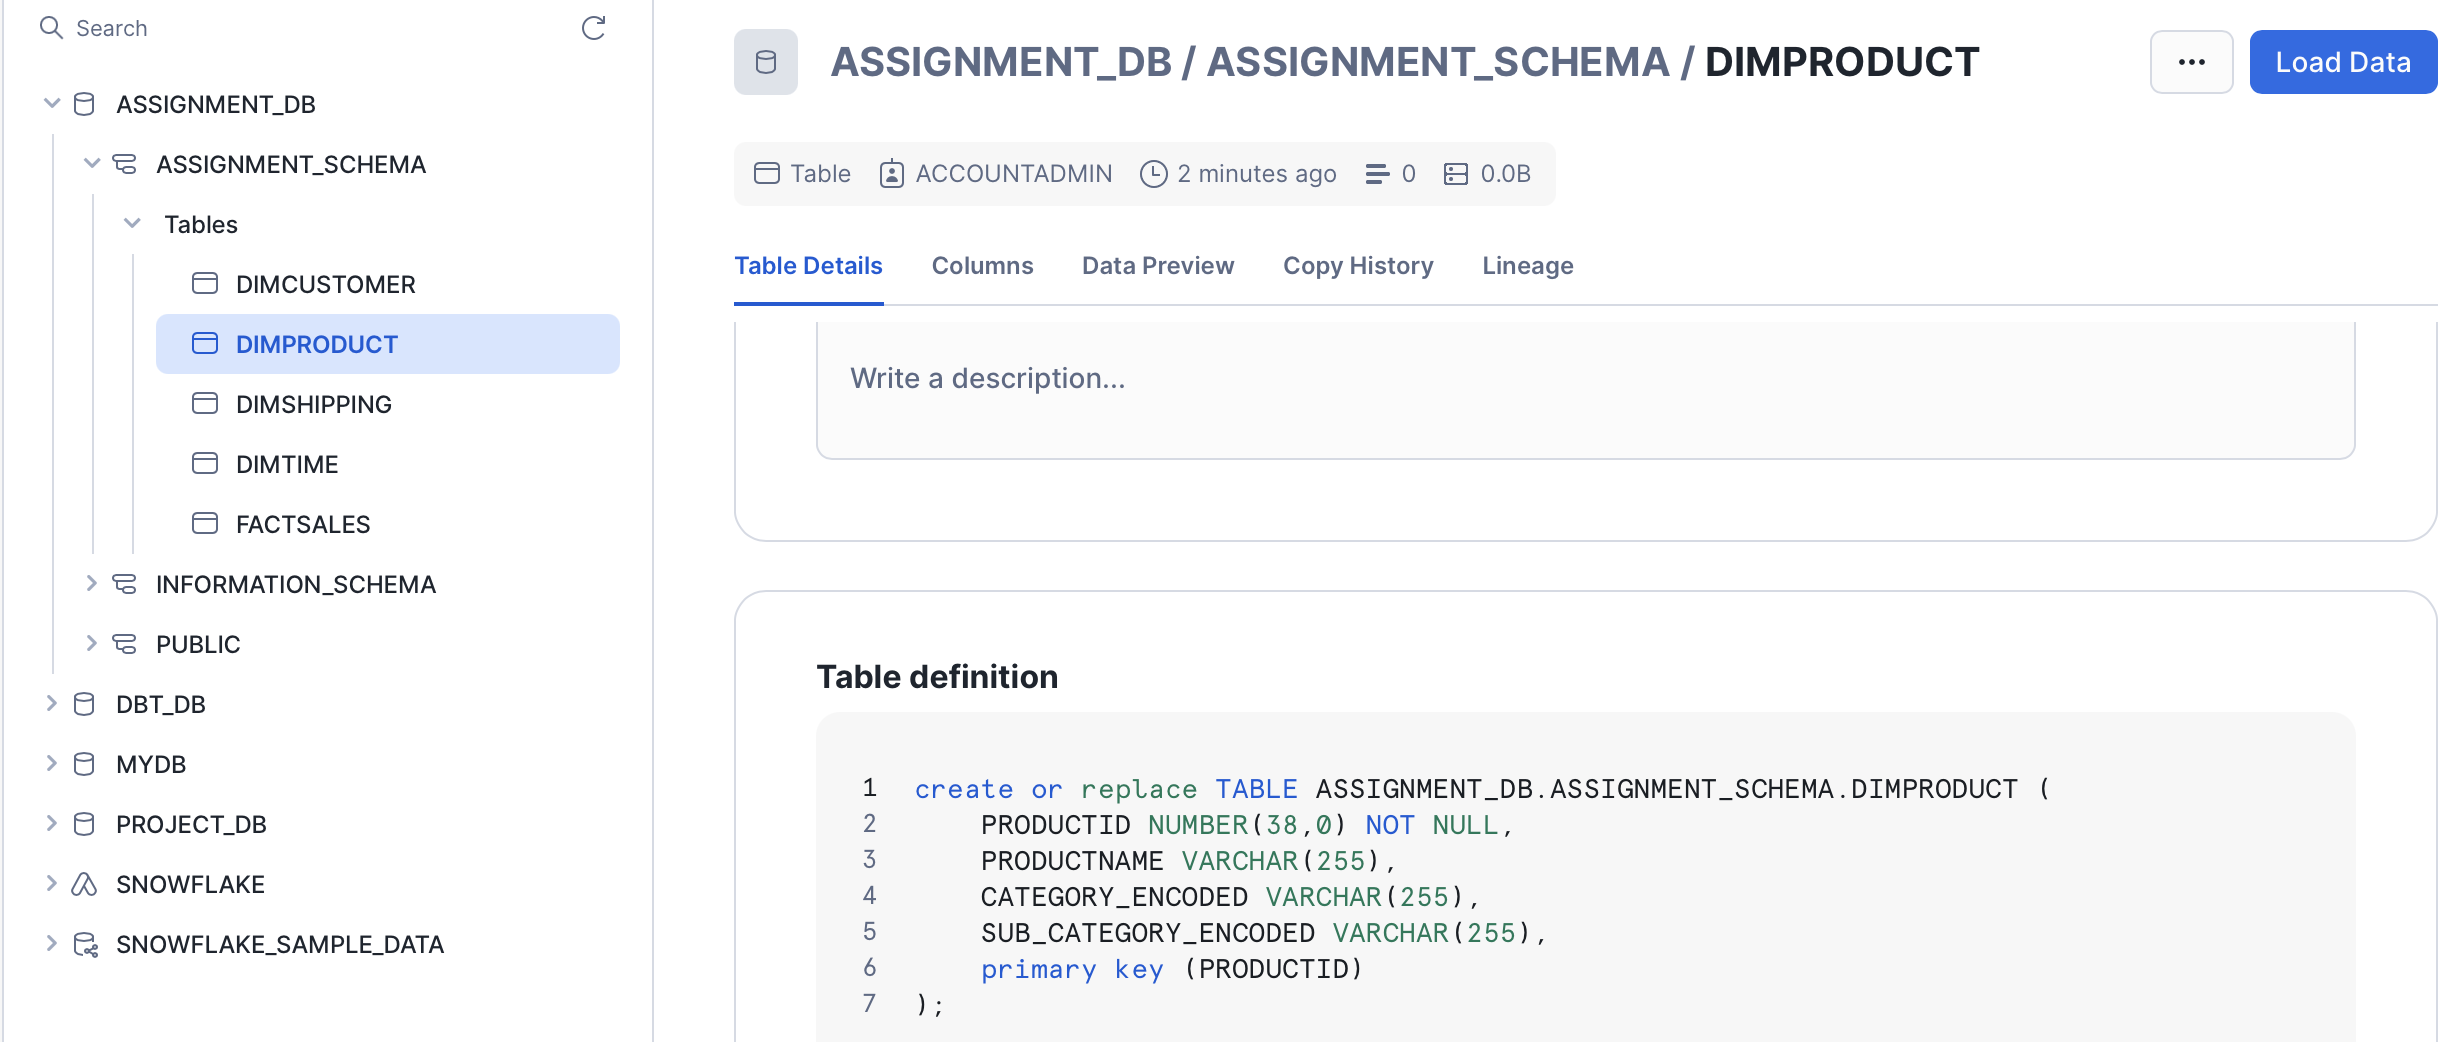

5. SQL script for DIMCUSTOMER


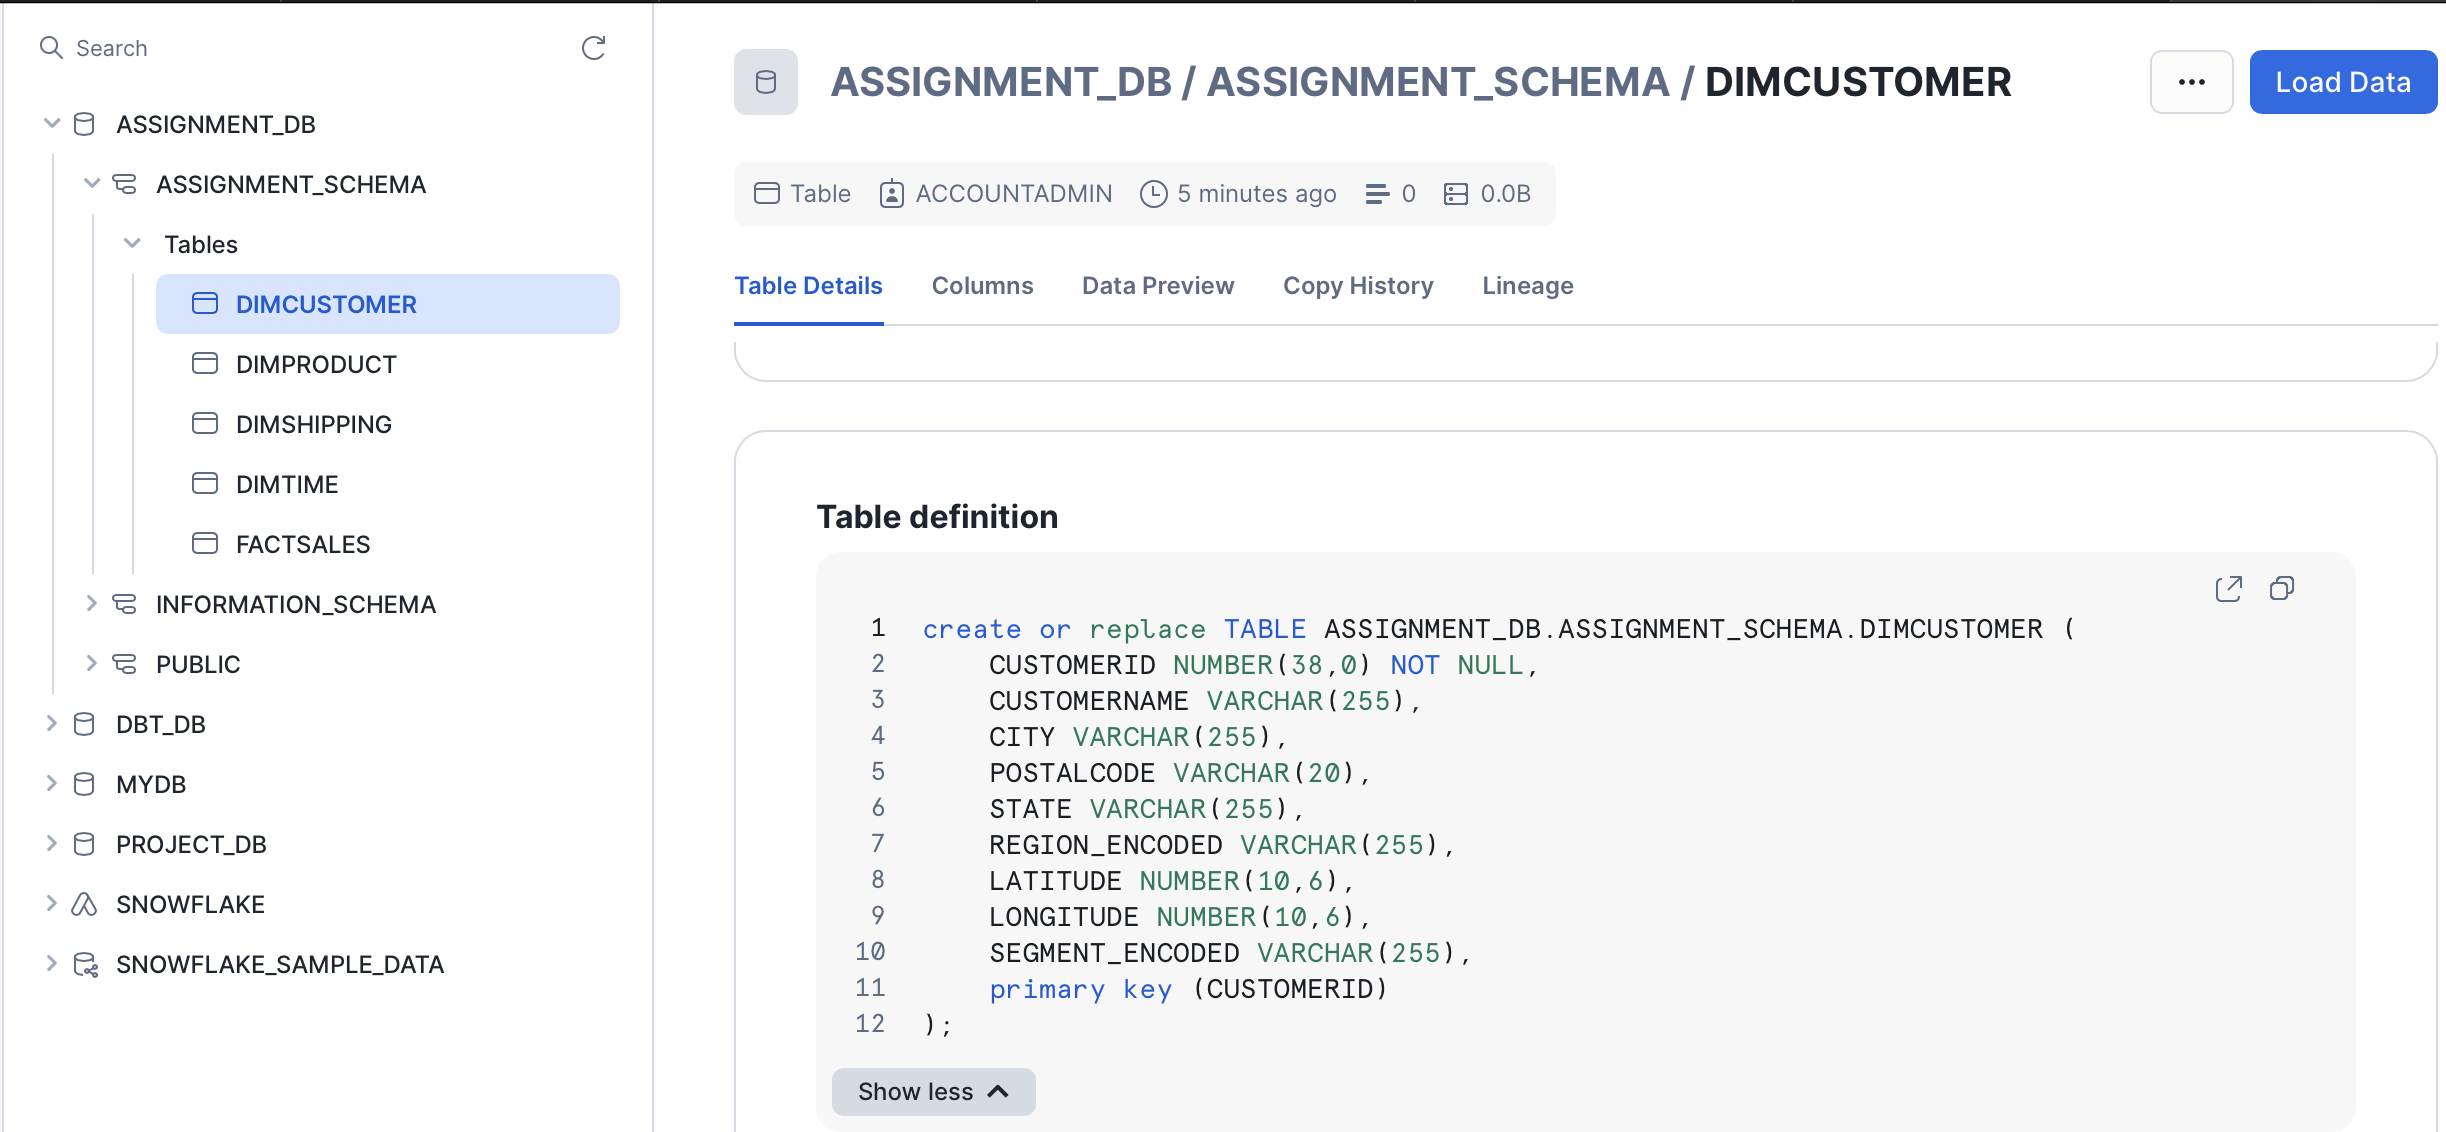

In [37]:
# export cleaned csv
df_v1.to_csv('cleaned_sales_data.csv', index=False)

### LOAD of ETL

1. LOAD data into FACTSALES

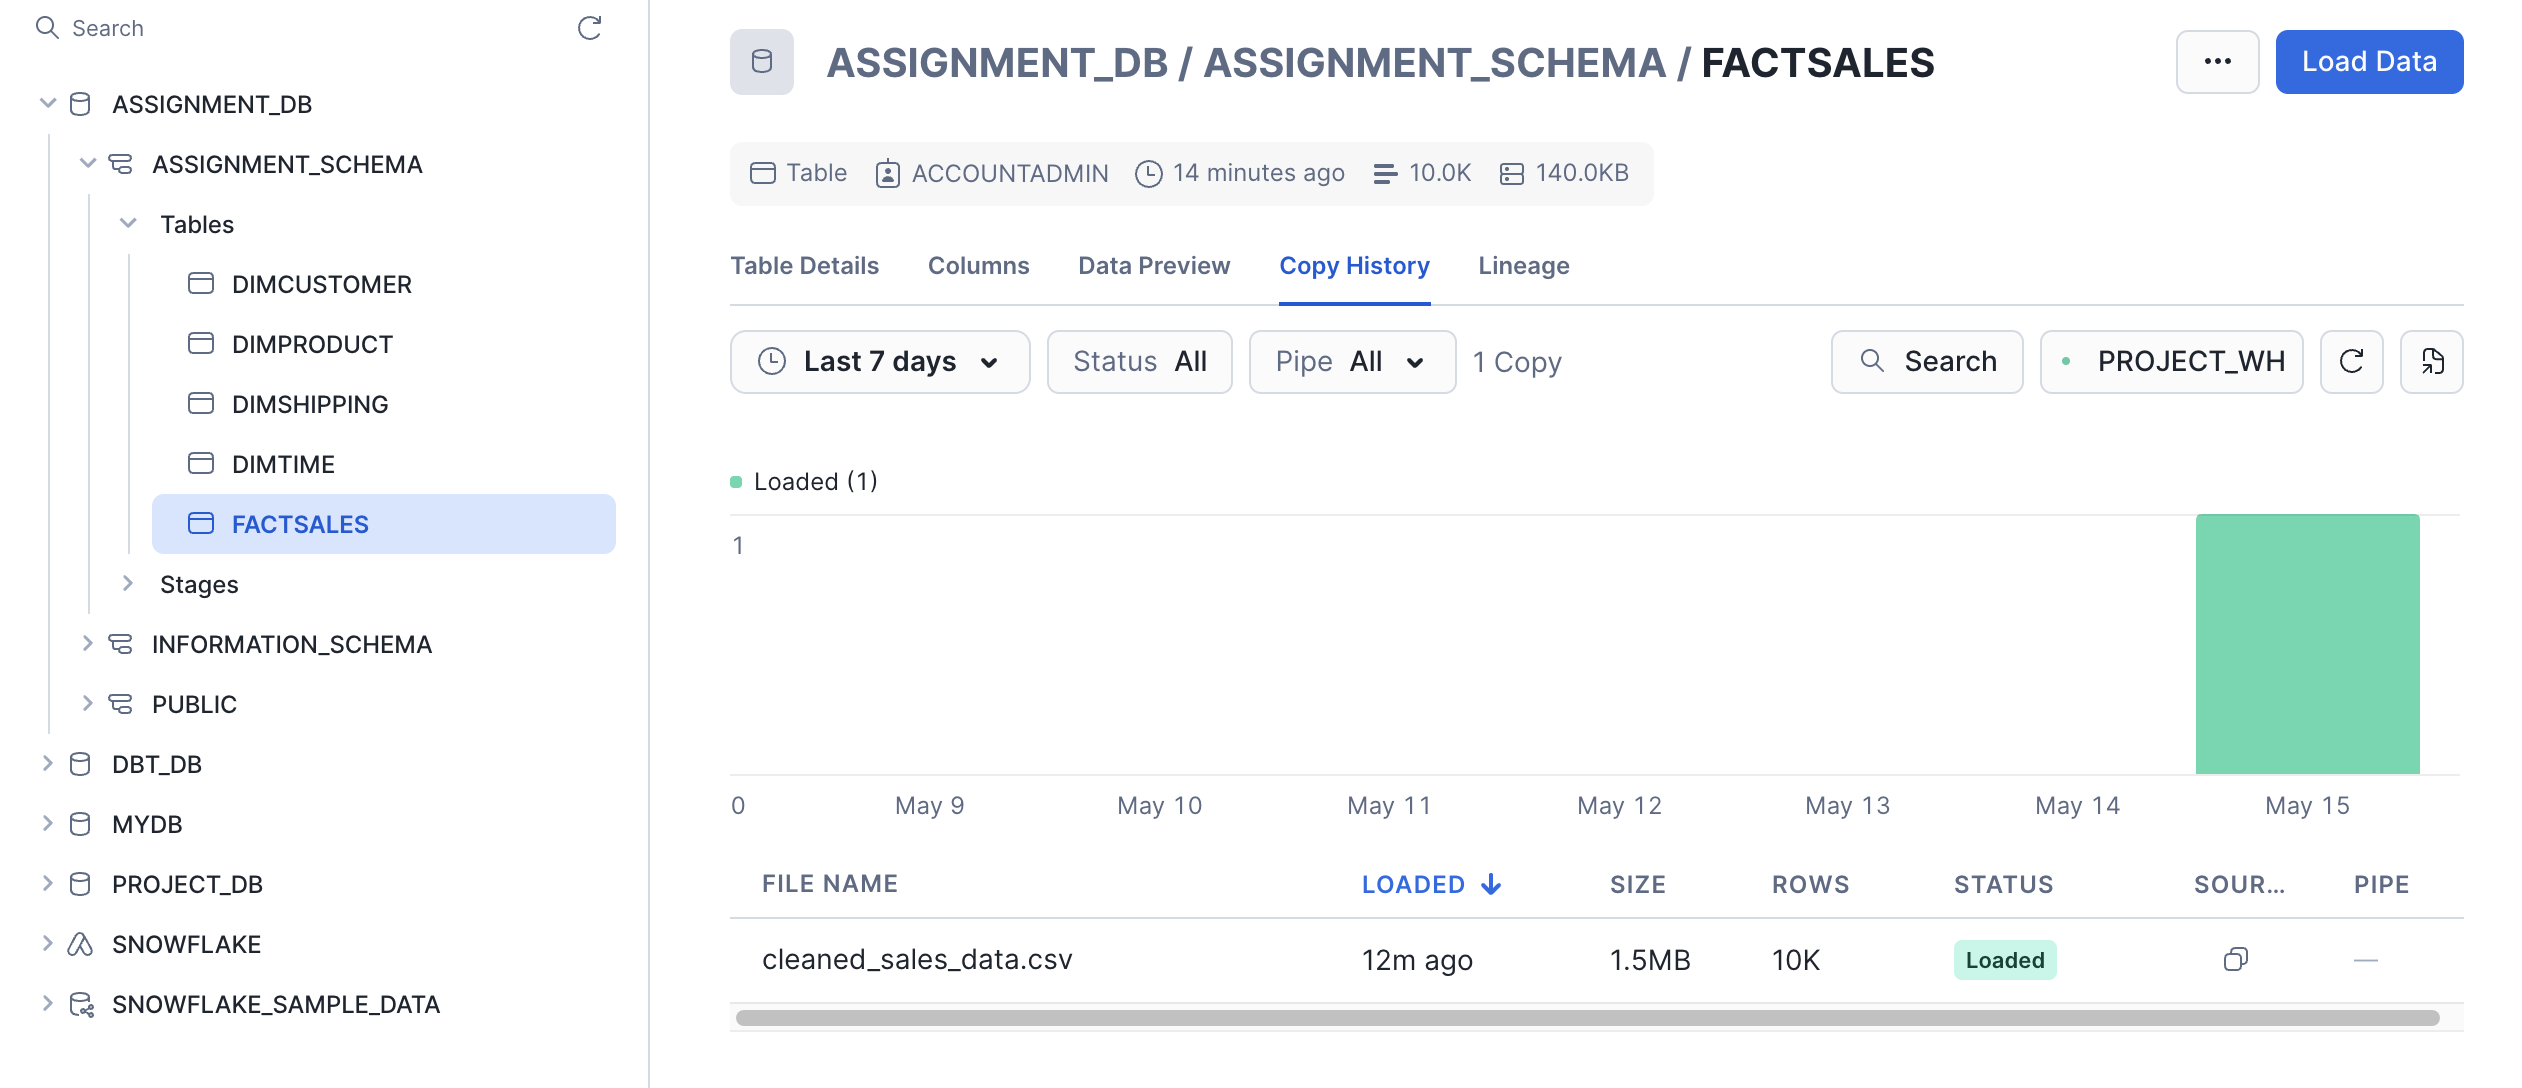

2. LOAD data into DIMTIME

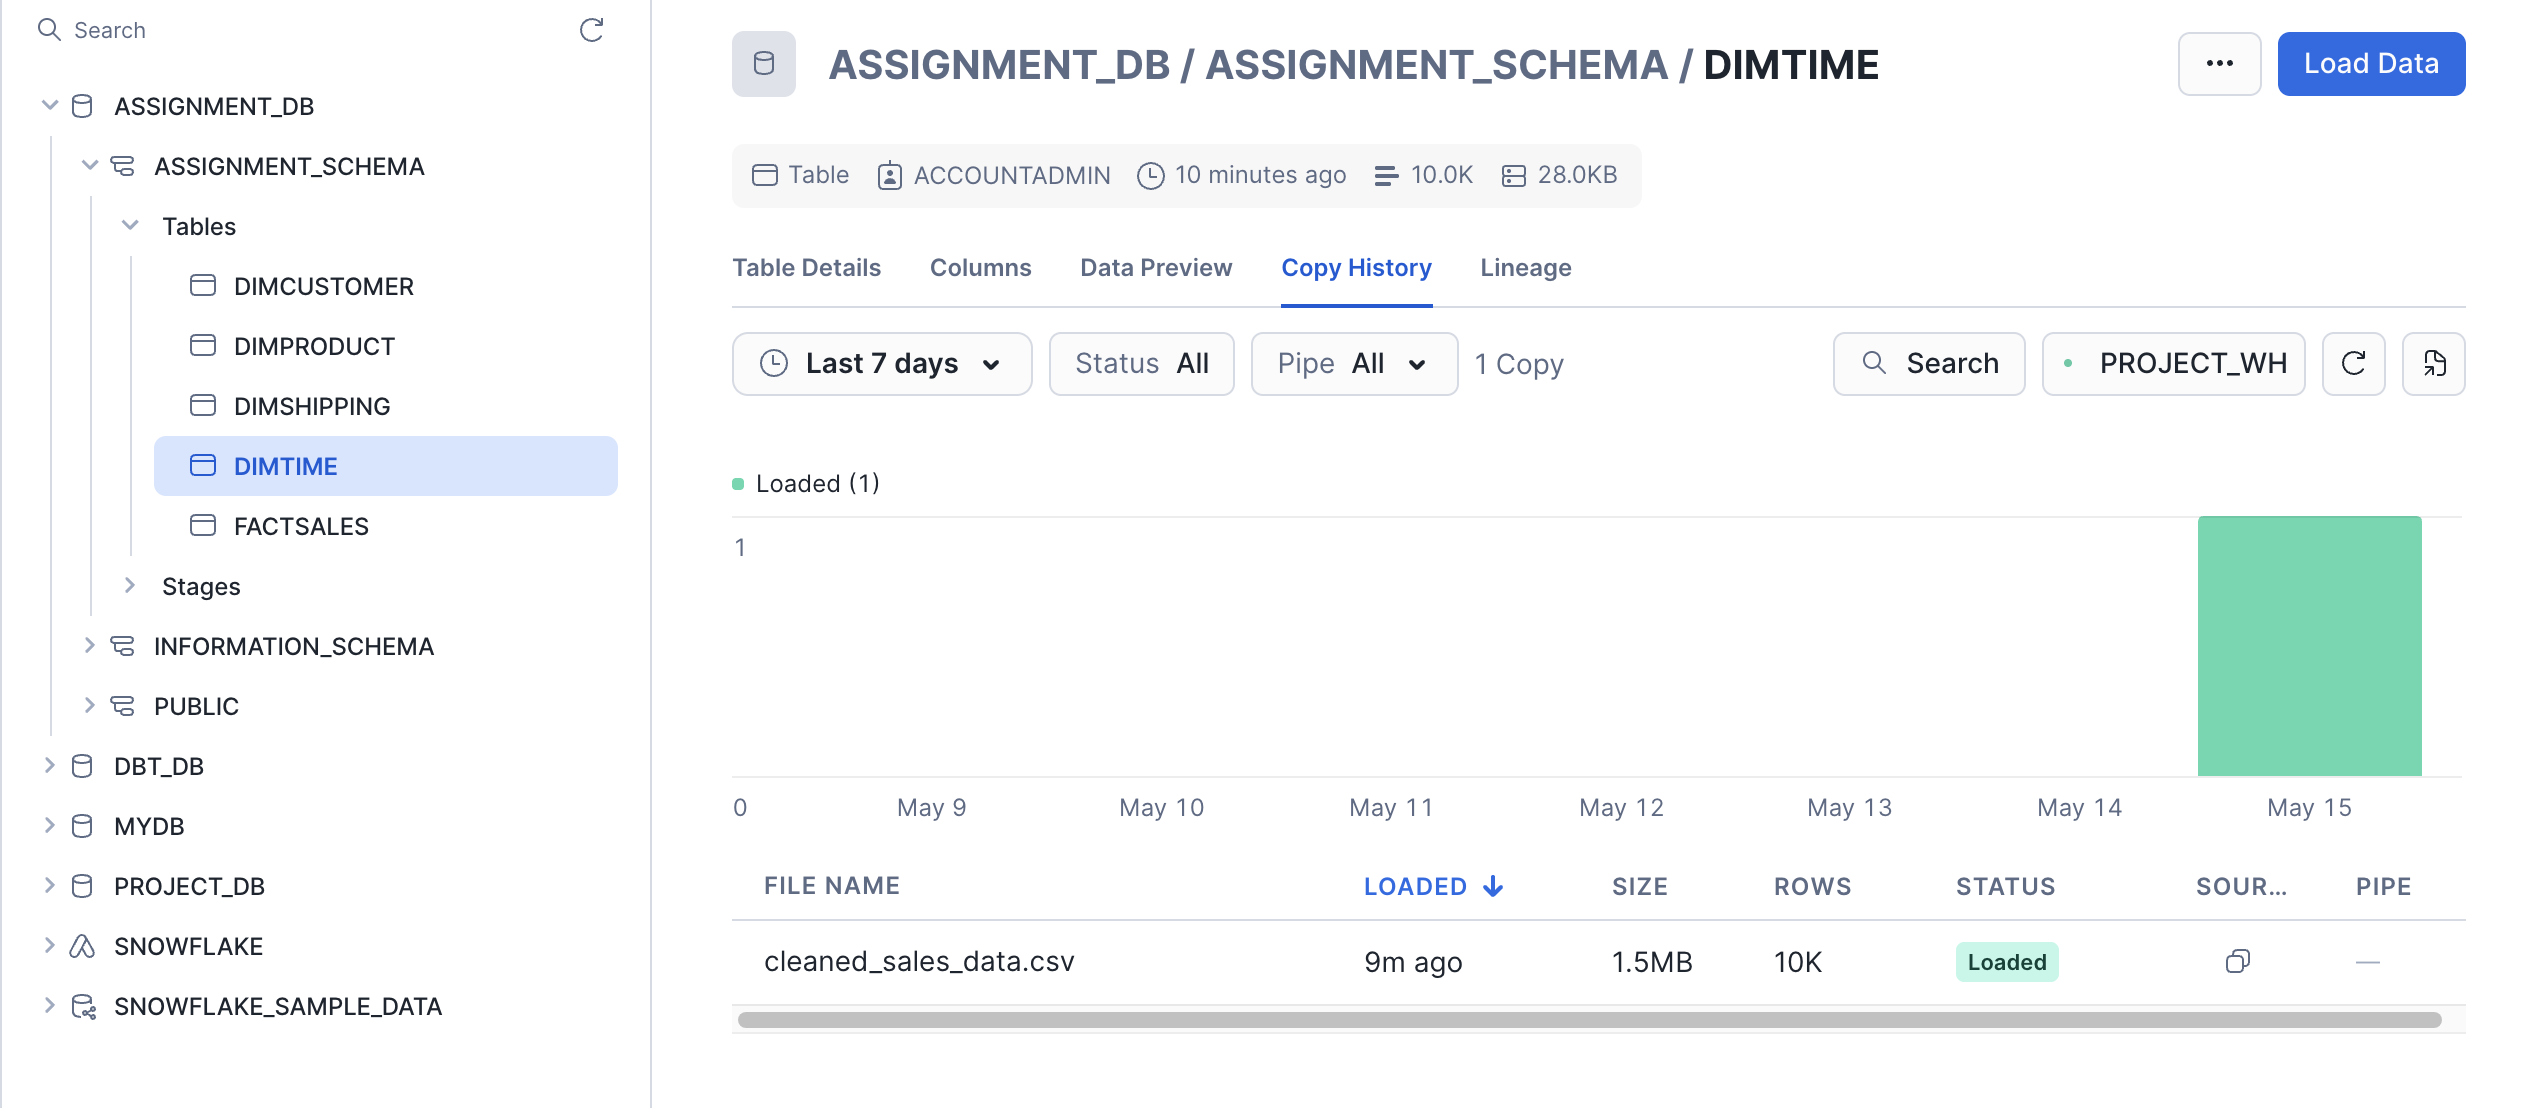

3. LOAD data into DIMSHIPPING

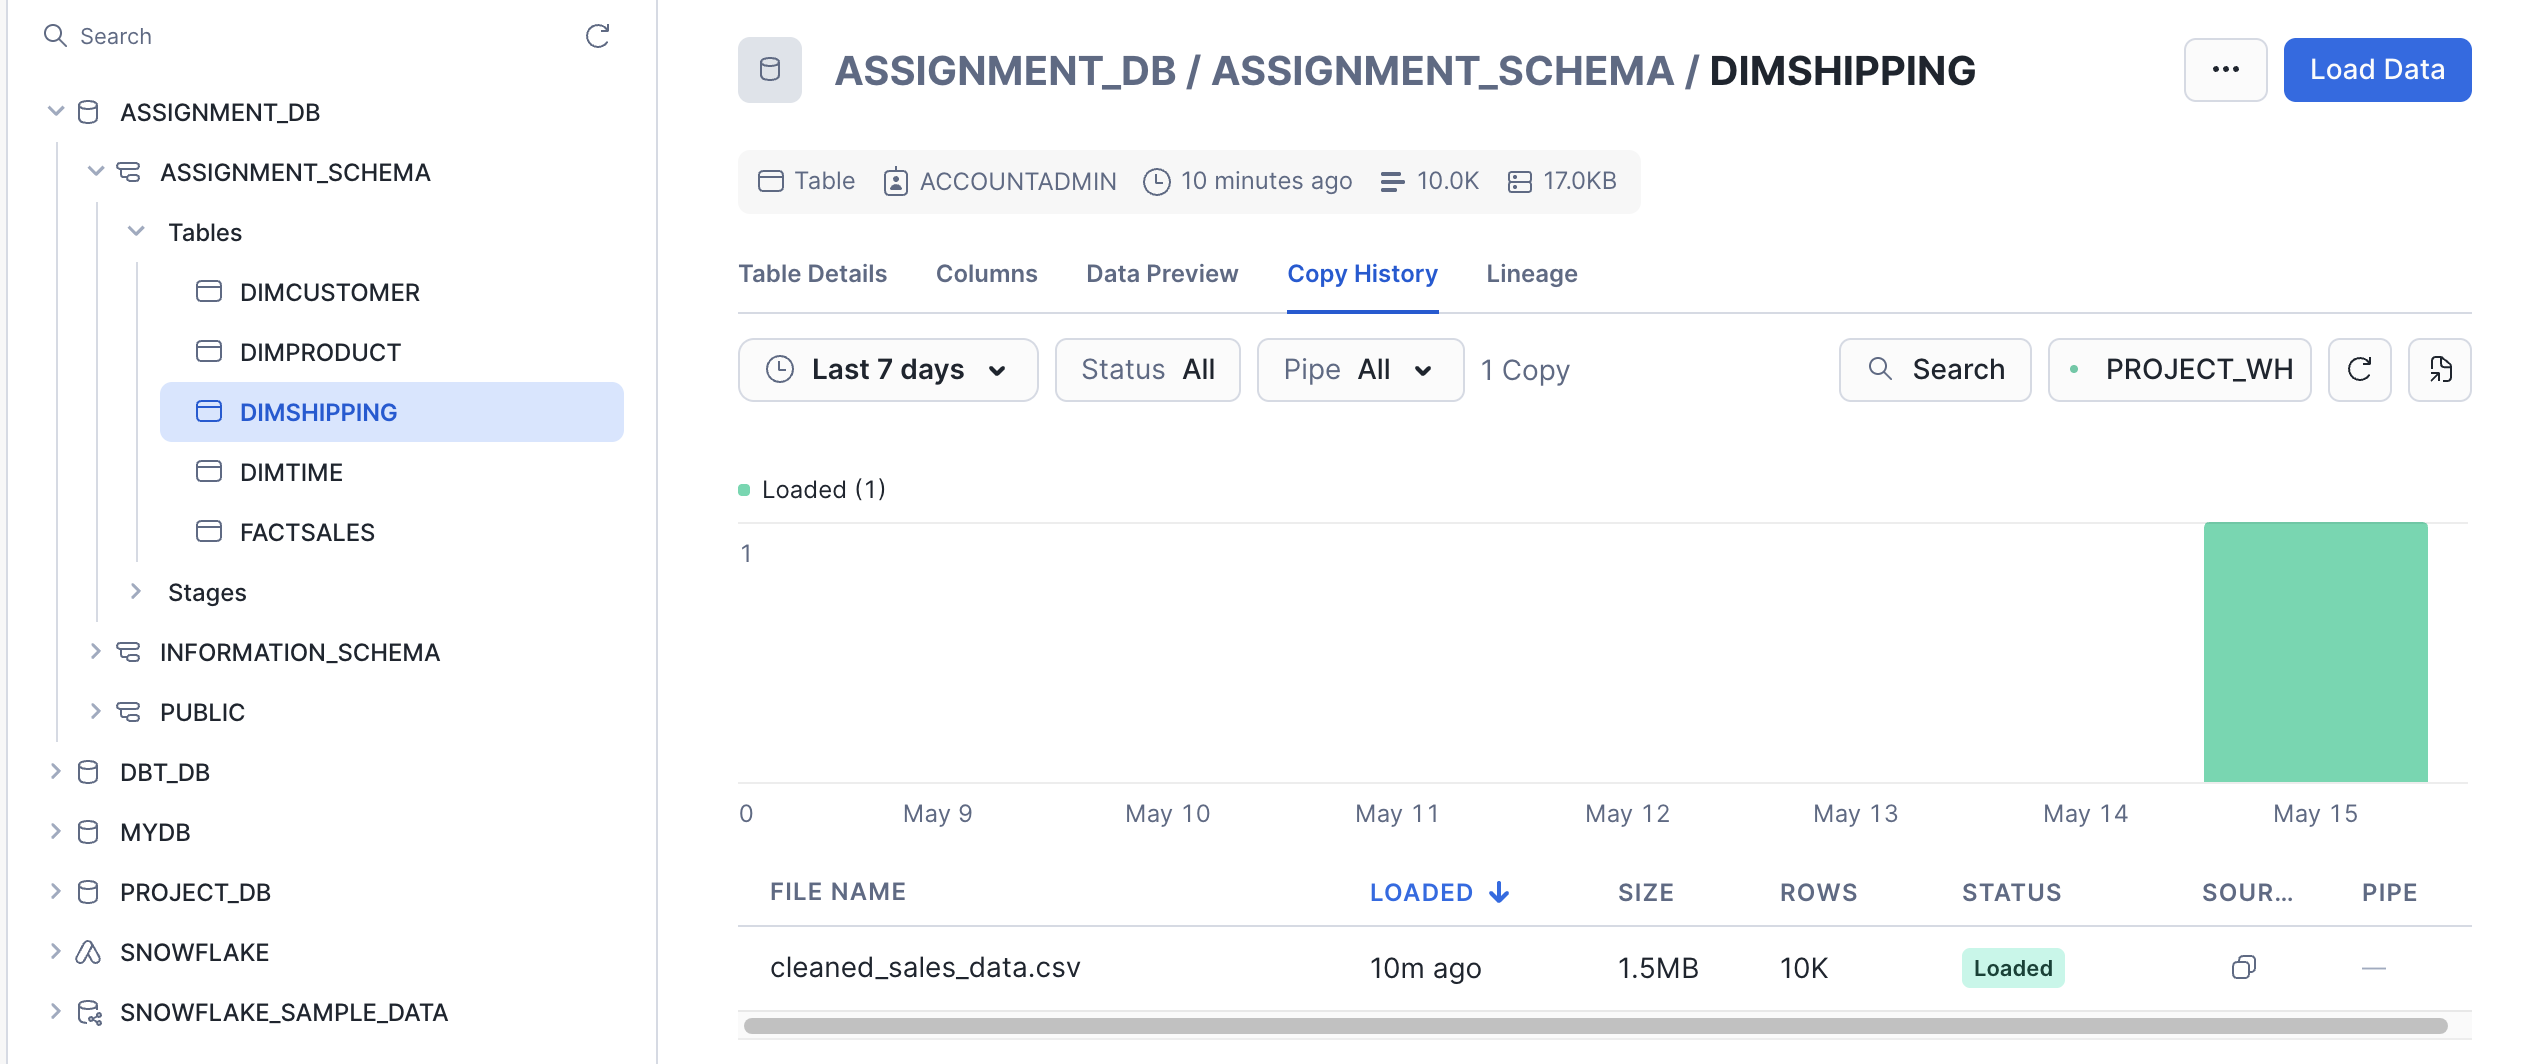

4. LOAD data into DIMPRODUCT

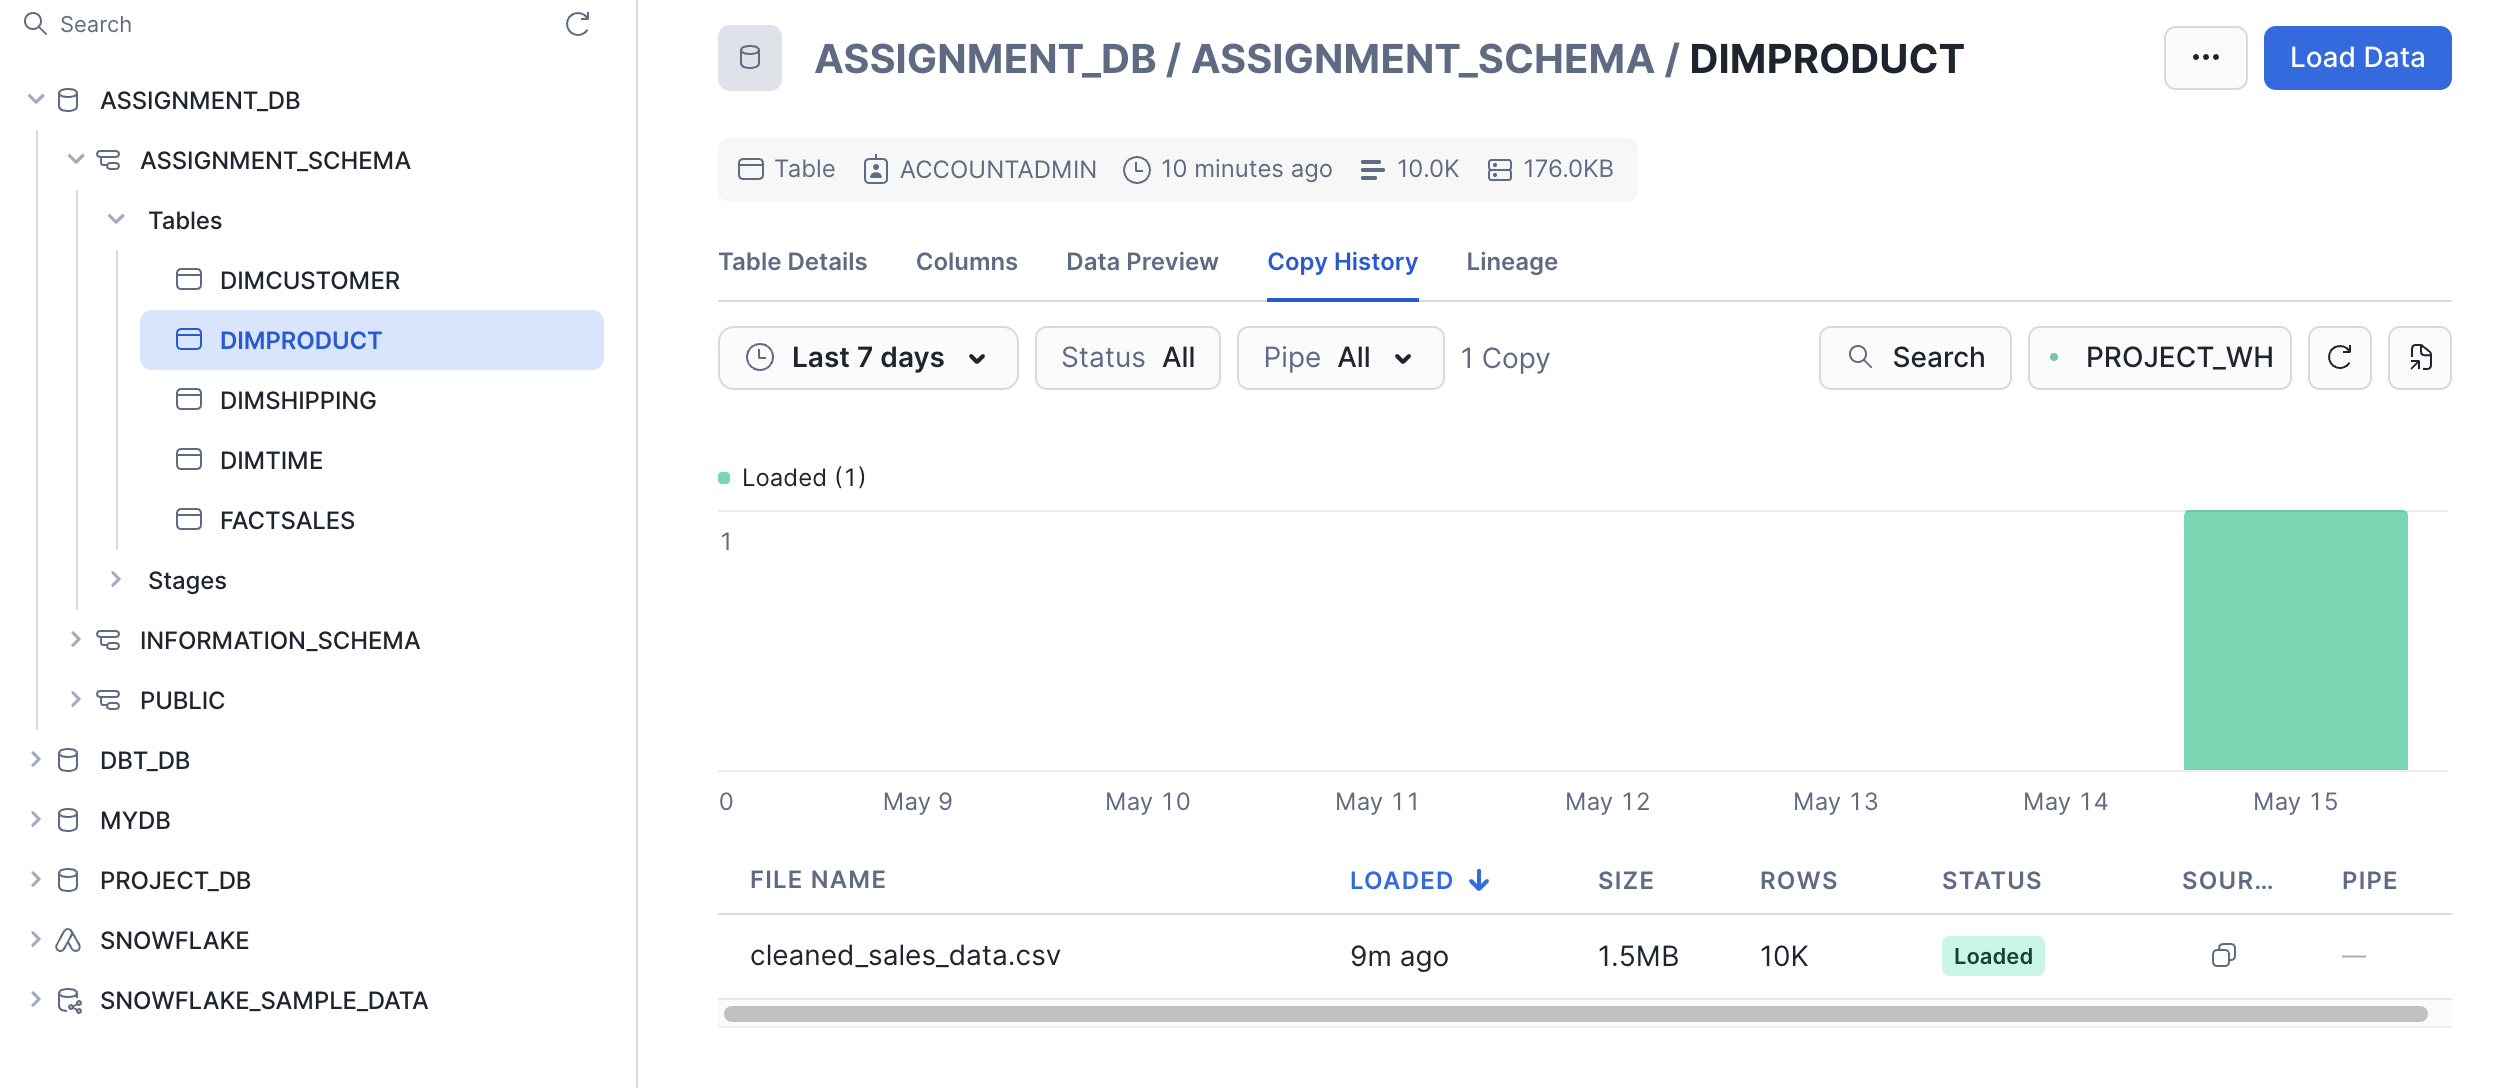

5. LOAD data into DIMCUSTOMER

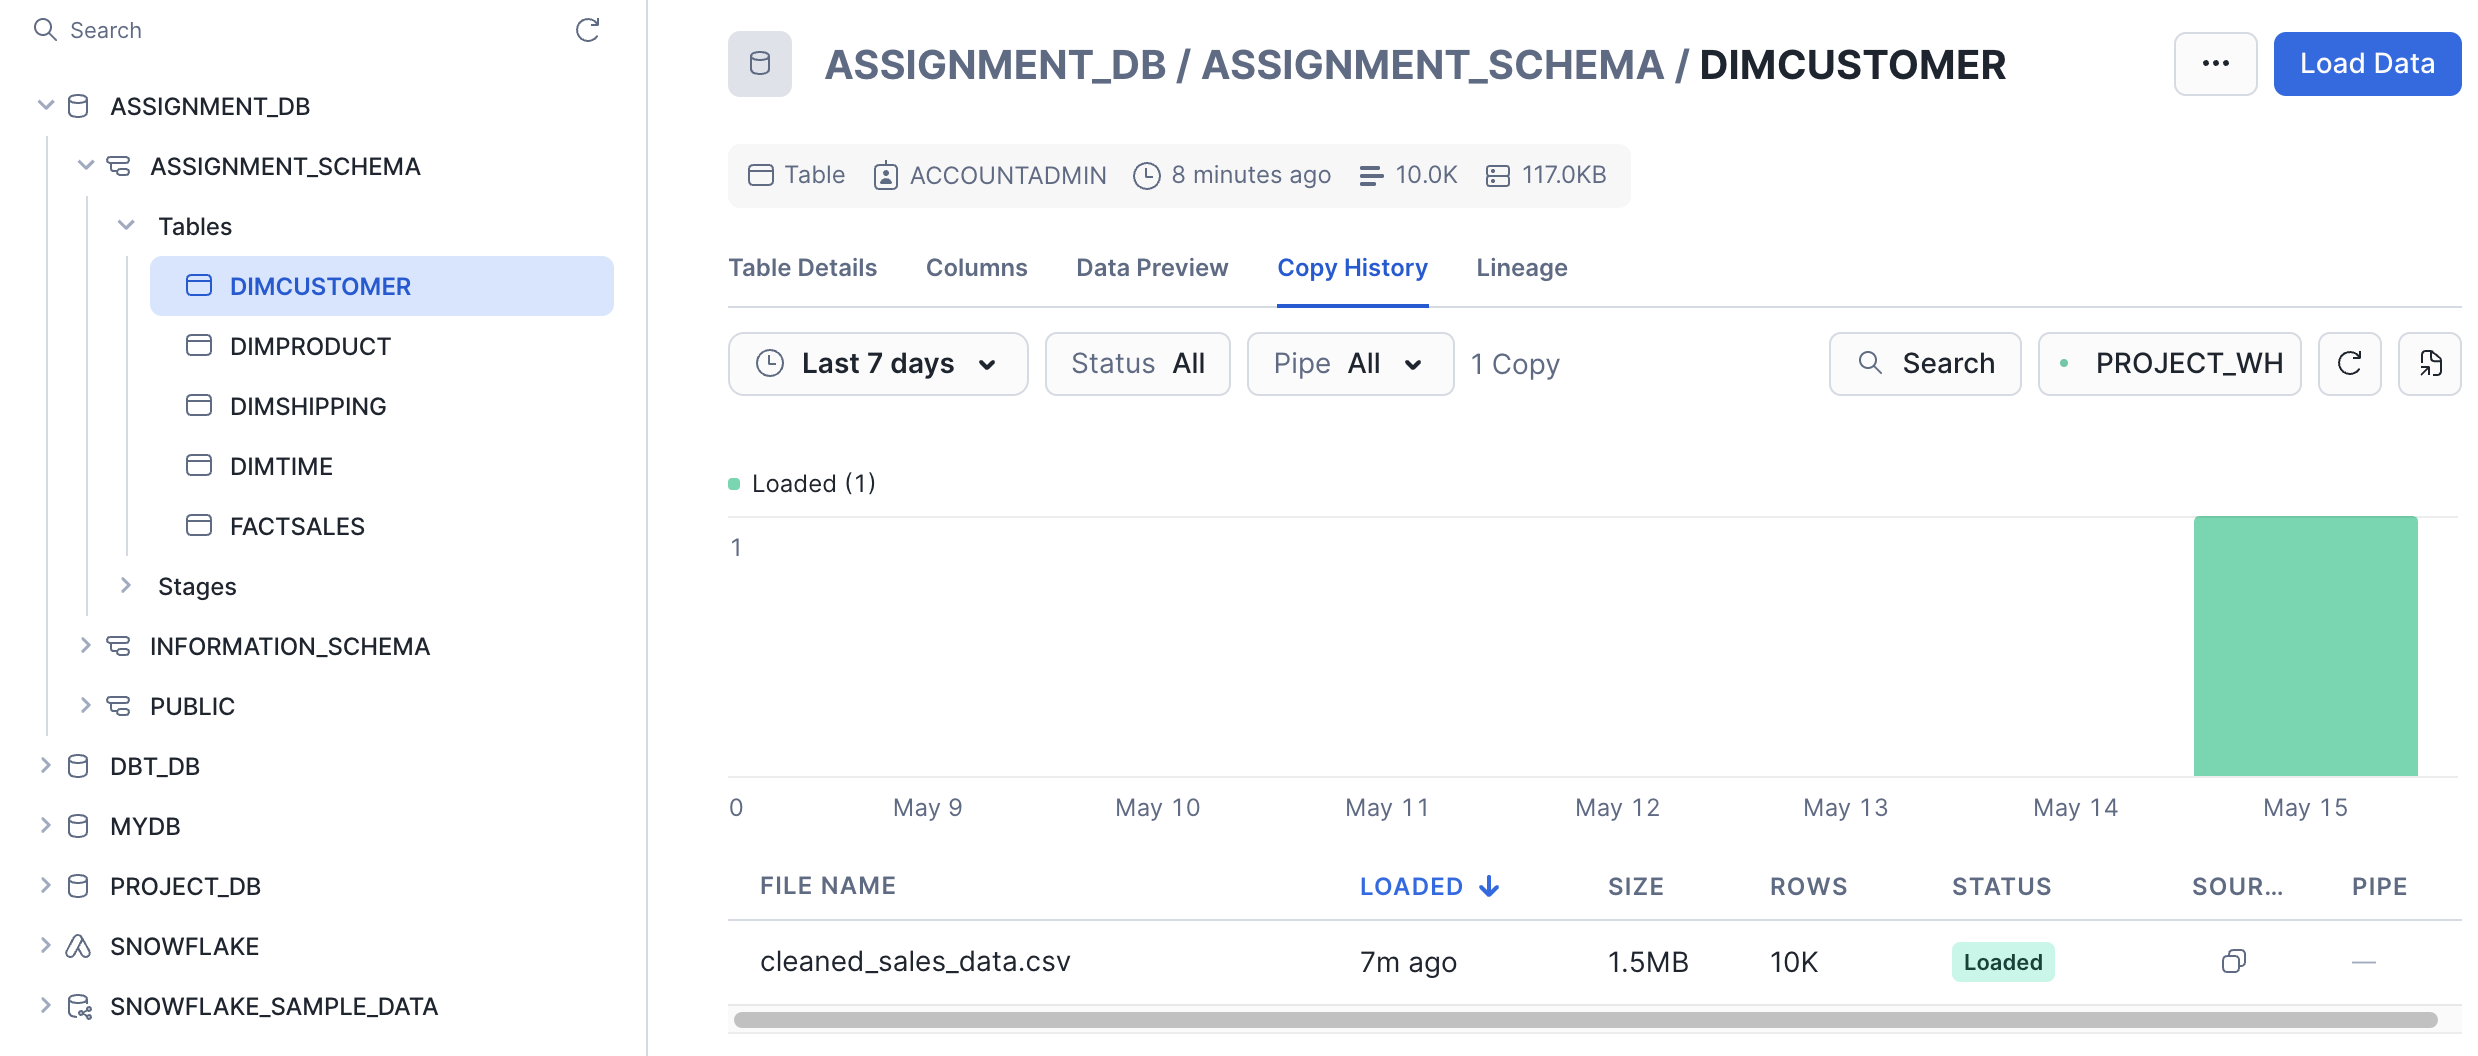

### Step 5 

Data Mining Tasks (Using Data from Warehouse).<br>
Use necessary datamining techniques to complete below tasks.<br>
* Predict Shipment Status
* Predict Sales Forecast
* Predict Order Profitability
* Cluster Orders by Buying Behavior - Group orders/customers by similar buying/shipping
patterns
* Visualize shipment performance across geographies
* Analyze delivery delays or profit trends by latitude/longitude

Configuring snowpark with python in jupyter notebook

In [38]:
# import snowflake.connector

# conn = snowflake.connector.connect(
#     user='Danika',
#     password='wwn2mmA5BsuQPg5',
#     account='WJB17972',
#     warehouse='COMPUTE_WH',
#     database='SALES',
#     schema='SALES_DATA'
# )


In [39]:
import snowflake.connector

try:
    conn = snowflake.connector.connect(
        user='subhabanda',
        password='snowSubha2000#',
        #account='https://yj85186.ap-south-1.aws.snowflakecomputing.com',
        account='POJKKKP-RJ66138',
        warehouse='PROJECT_WH',
        database='ASSIGNMENT_DB',
        schema='ASSIGNMENT_SCHEMA'
)
    print("Connected to Snowflake successfully.")
except Exception as e:
    print(f"Connection failed: {e}")

Connected to Snowflake successfully.


In [40]:
# from snowflake.snowpark import Session

# connection_parameters = {
#     "account": "POJKKKP-RJ66138", 
#     "user": "subhabanda",           
#     "password": "snowSubha2000#",       
#     "role": "ACCOUNTADMIN",               
#     "warehouse": "PROJECT_WH",     
#     "database": "ASSIGNMENT_DB",      
#     "schema": "ASSIGNMENT_SCHEMA"           
# }

# try:
#     session = Session.builder.configs(connection_parameters).create()
#     print("Connected to Snowflake successfully.")
# except Exception as e:
#     print(f"Connection failed: {e}")

In [41]:
query = """   
WITH t1 AS (
    SELECT *, ROW_NUMBER() OVER (ORDER BY ORDERDATE) AS rn
    FROM ASSIGNMENT_DB.ASSIGNMENT_SCHEMA.DIMTIME
),
t2 AS (
    SELECT *, ROW_NUMBER() OVER (ORDER BY SHIPSTATUS_ENCODED) AS rn
    FROM ASSIGNMENT_DB.ASSIGNMENT_SCHEMA.DIMSHIPPING
)
SELECT
    t1.ORDERDATE, t1.SHIPDATE,
    t2.SHIPSTATUS_ENCODED, t2.SHIPMODE_ENCODED,
    t2.DAYSTOSHIPSCHEDULED, t2.DAYSTOSHIPACTUAL
FROM
    t1
JOIN
    t2 ON t1.rn = t2.rn;

"""

In [42]:
try:
    df = pd.read_sql(query, conn)
except Exception as e:
    print("Error:",e)

/var/folders/4k/wvlpxp711yz8cxnbyqjw1zlh0000gn/T/ipykernel_38808/225130294.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


##### 5.1 Predict Shipment Status

##### Pulling data from warehouse

In [43]:
query1 = """
WITH t1 AS (
    SELECT *, ROW_NUMBER() OVER (ORDER BY ORDERDATE) AS rn
    FROM ASSIGNMENT_DB.ASSIGNMENT_SCHEMA.DIMTIME
),
t2 AS (
    SELECT *, ROW_NUMBER() OVER (ORDER BY SHIPSTATUS_ENCODED) AS rn
    FROM ASSIGNMENT_DB.ASSIGNMENT_SCHEMA.DIMSHIPPING
),

t3 AS (
    SELECT *, ROW_NUMBER() OVER (ORDER BY PRODUCTNAME) AS rn
    FROM ASSIGNMENT_DB.ASSIGNMENT_SCHEMA.DIMPRODUCT
),
t4 AS (
    SELECT *, ROW_NUMBER() OVER (ORDER BY CITY) AS rn
    FROM ASSIGNMENT_DB.ASSIGNMENT_SCHEMA.DIMCUSTOMER
),
t5 AS (
    SELECT *, ROW_NUMBER() OVER (ORDER BY ORDERID) AS rn
    FROM ASSIGNMENT_DB.ASSIGNMENT_SCHEMA.FACTSALES
)

SELECT
    t2.SHIPSTATUS_ENCODED,
    t2.SHIPMODE_ENCODED,
    t2.DAYSTOSHIPSCHEDULED,
    t2.DAYSTOSHIPACTUAL,
    t3.PRODUCTNAME,
    t3.CATEGORY_ENCODED,
    t3.SUB_CATEGORY_ENCODED,
    t4.CITY,
    t4.LATITUDE,
    t4.LONGITUDE,
    t4.POSTALCODE,
    t4.STATE,
    t4.REGION_ENCODED,
    t4.SEGMENT_ENCODED,
    t5.DISCOUNT,
    t5.PROFIT,
    t5.PROFITRATIO,
    t5.QUANTITY,
    t5.SALES
FROM
    t5
JOIN t2 ON t5.rn = t2.rn
JOIN t3 ON t5.rn = t3.rn
JOIN t4 ON t5.rn = t4.rn
JOIN t1 ON t5.rn = t1.rn;

"""

In [44]:
df_q1 = pd.read_sql(query1, conn)

/var/folders/4k/wvlpxp711yz8cxnbyqjw1zlh0000gn/T/ipykernel_38808/2758062646.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_q1 = pd.read_sql(query1, conn)


In [45]:
df_q1.columns

Index(['SHIPSTATUS_ENCODED', 'SHIPMODE_ENCODED', 'DAYSTOSHIPSCHEDULED',
       'DAYSTOSHIPACTUAL', 'PRODUCTNAME', 'CATEGORY_ENCODED',
       'SUB_CATEGORY_ENCODED', 'CITY', 'LATITUDE', 'LONGITUDE', 'POSTALCODE',
       'STATE', 'REGION_ENCODED', 'SEGMENT_ENCODED', 'DISCOUNT', 'PROFIT',
       'PROFITRATIO', 'QUANTITY', 'SALES'],
      dtype='object')

In [46]:
df_q1.shape

(9993, 19)

In [47]:
df_q1.head()

,SHIPSTATUS_ENCODED,SHIPMODE_ENCODED,DAYSTOSHIPSCHEDULED,DAYSTOSHIPACTUAL,PRODUCTNAME,CATEGORY_ENCODED,SUB_CATEGORY_ENCODED,CITY,LATITUDE,LONGITUDE,POSTALCODE,STATE,REGION_ENCODED,SEGMENT_ENCODED,DISCOUNT,PROFIT,PROFITRATIO,QUANTITY,SALES
0,1,1,6,5,"#10 Gummed Flap White Envelopes, 100/Box",1,12,Aberdeen,45.4661,-98.4856,57401,South Dakota,3,1,0.0,110.0,29.0,3,378.0
1,1,1,6,5,"#10 Gummed Flap White Envelopes, 100/Box",1,12,Abilene,32.4320,-99.7724,79605,Texas,3,1,0.2,-88.0,-17.5,3,502.0
2,1,1,6,5,"#10 Gummed Flap White Envelopes, 100/Box",1,12,Akron,41.0334,-81.4385,44312,Ohio,2,1,0.2,69.0,35.0,6,197.0
3,1,1,6,5,"#10 Gummed Flap White Envelopes, 100/Box",1,12,Akron,41.0334,-81.4385,44312,Ohio,2,2,0.2,32.0,35.0,6,91.0
4,1,1,6,4,#10 Self-Seal White Envelopes,1,12,Akron,41.0334,-81.4385,44312,Ohio,2,1,0.2,1.0,33.8,1,4.0


##### Feature engineering and preprocessing

in above df_q1 dataframe has importance categorical data.First we should convert those into numerical using label encoding

In [48]:
from sklearn.preprocessing import LabelEncoder

le_city = LabelEncoder()
df_q1['CITY_encoded'] = le_city.fit_transform(df_q1['CITY'])

le_productname = LabelEncoder()
df_q1['PRODUCTNAME_encoded'] = le_city.fit_transform(df_q1['PRODUCTNAME'])

le_state = LabelEncoder()
df_q1['STATE_encoded'] = le_city.fit_transform(df_q1['STATE'])

In [49]:
df_q1.head()

,SHIPSTATUS_ENCODED,SHIPMODE_ENCODED,DAYSTOSHIPSCHEDULED,DAYSTOSHIPACTUAL,PRODUCTNAME,CATEGORY_ENCODED,SUB_CATEGORY_ENCODED,CITY,LATITUDE,LONGITUDE,...,REGION_ENCODED,SEGMENT_ENCODED,DISCOUNT,PROFIT,PROFITRATIO,QUANTITY,SALES,CITY_encoded,PRODUCTNAME_encoded,STATE_encoded
0,1,1,6,5,"#10 Gummed Flap White Envelopes, 100/Box",1,12,Aberdeen,45.4661,-98.4856,...,3,1,0.0,110.0,29.0,3,378.0,0,0,39
1,1,1,6,5,"#10 Gummed Flap White Envelopes, 100/Box",1,12,Abilene,32.4320,-99.7724,...,3,1,0.2,-88.0,-17.5,3,502.0,1,0,41
2,1,1,6,5,"#10 Gummed Flap White Envelopes, 100/Box",1,12,Akron,41.0334,-81.4385,...,2,1,0.2,69.0,35.0,6,197.0,2,0,33
3,1,1,6,5,"#10 Gummed Flap White Envelopes, 100/Box",1,12,Akron,41.0334,-81.4385,...,2,2,0.2,32.0,35.0,6,91.0,2,0,33
4,1,1,6,4,#10 Self-Seal White Envelopes,1,12,Akron,41.0334,-81.4385,...,2,1,0.2,1.0,33.8,1,4.0,2,1,33


In [50]:
#drop unnecassary categorical columns
df_q1.drop(['PRODUCTNAME','CITY','STATE'], axis=1, inplace=True) 

In [51]:
df_q1.head()

,SHIPSTATUS_ENCODED,SHIPMODE_ENCODED,DAYSTOSHIPSCHEDULED,DAYSTOSHIPACTUAL,CATEGORY_ENCODED,SUB_CATEGORY_ENCODED,LATITUDE,LONGITUDE,POSTALCODE,REGION_ENCODED,SEGMENT_ENCODED,DISCOUNT,PROFIT,PROFITRATIO,QUANTITY,SALES,CITY_encoded,PRODUCTNAME_encoded,STATE_encoded
0,1,1,6,5,1,12,45.4661,-98.4856,57401,3,1,0.0,110.0,29.0,3,378.0,0,0,39
1,1,1,6,5,1,12,32.4320,-99.7724,79605,3,1,0.2,-88.0,-17.5,3,502.0,1,0,41
2,1,1,6,5,1,12,41.0334,-81.4385,44312,2,1,0.2,69.0,35.0,6,197.0,2,0,33
3,1,1,6,5,1,12,41.0334,-81.4385,44312,2,2,0.2,32.0,35.0,6,91.0,2,0,33
4,1,1,6,4,1,12,41.0334,-81.4385,44312,2,1,0.2,1.0,33.8,1,4.0,2,1,33


In [52]:
df_q1.shape

(9993, 19)

In [53]:
df_q1_copy = df_q1.copy() #make copy from original

##### Data mining techniques, evaluation

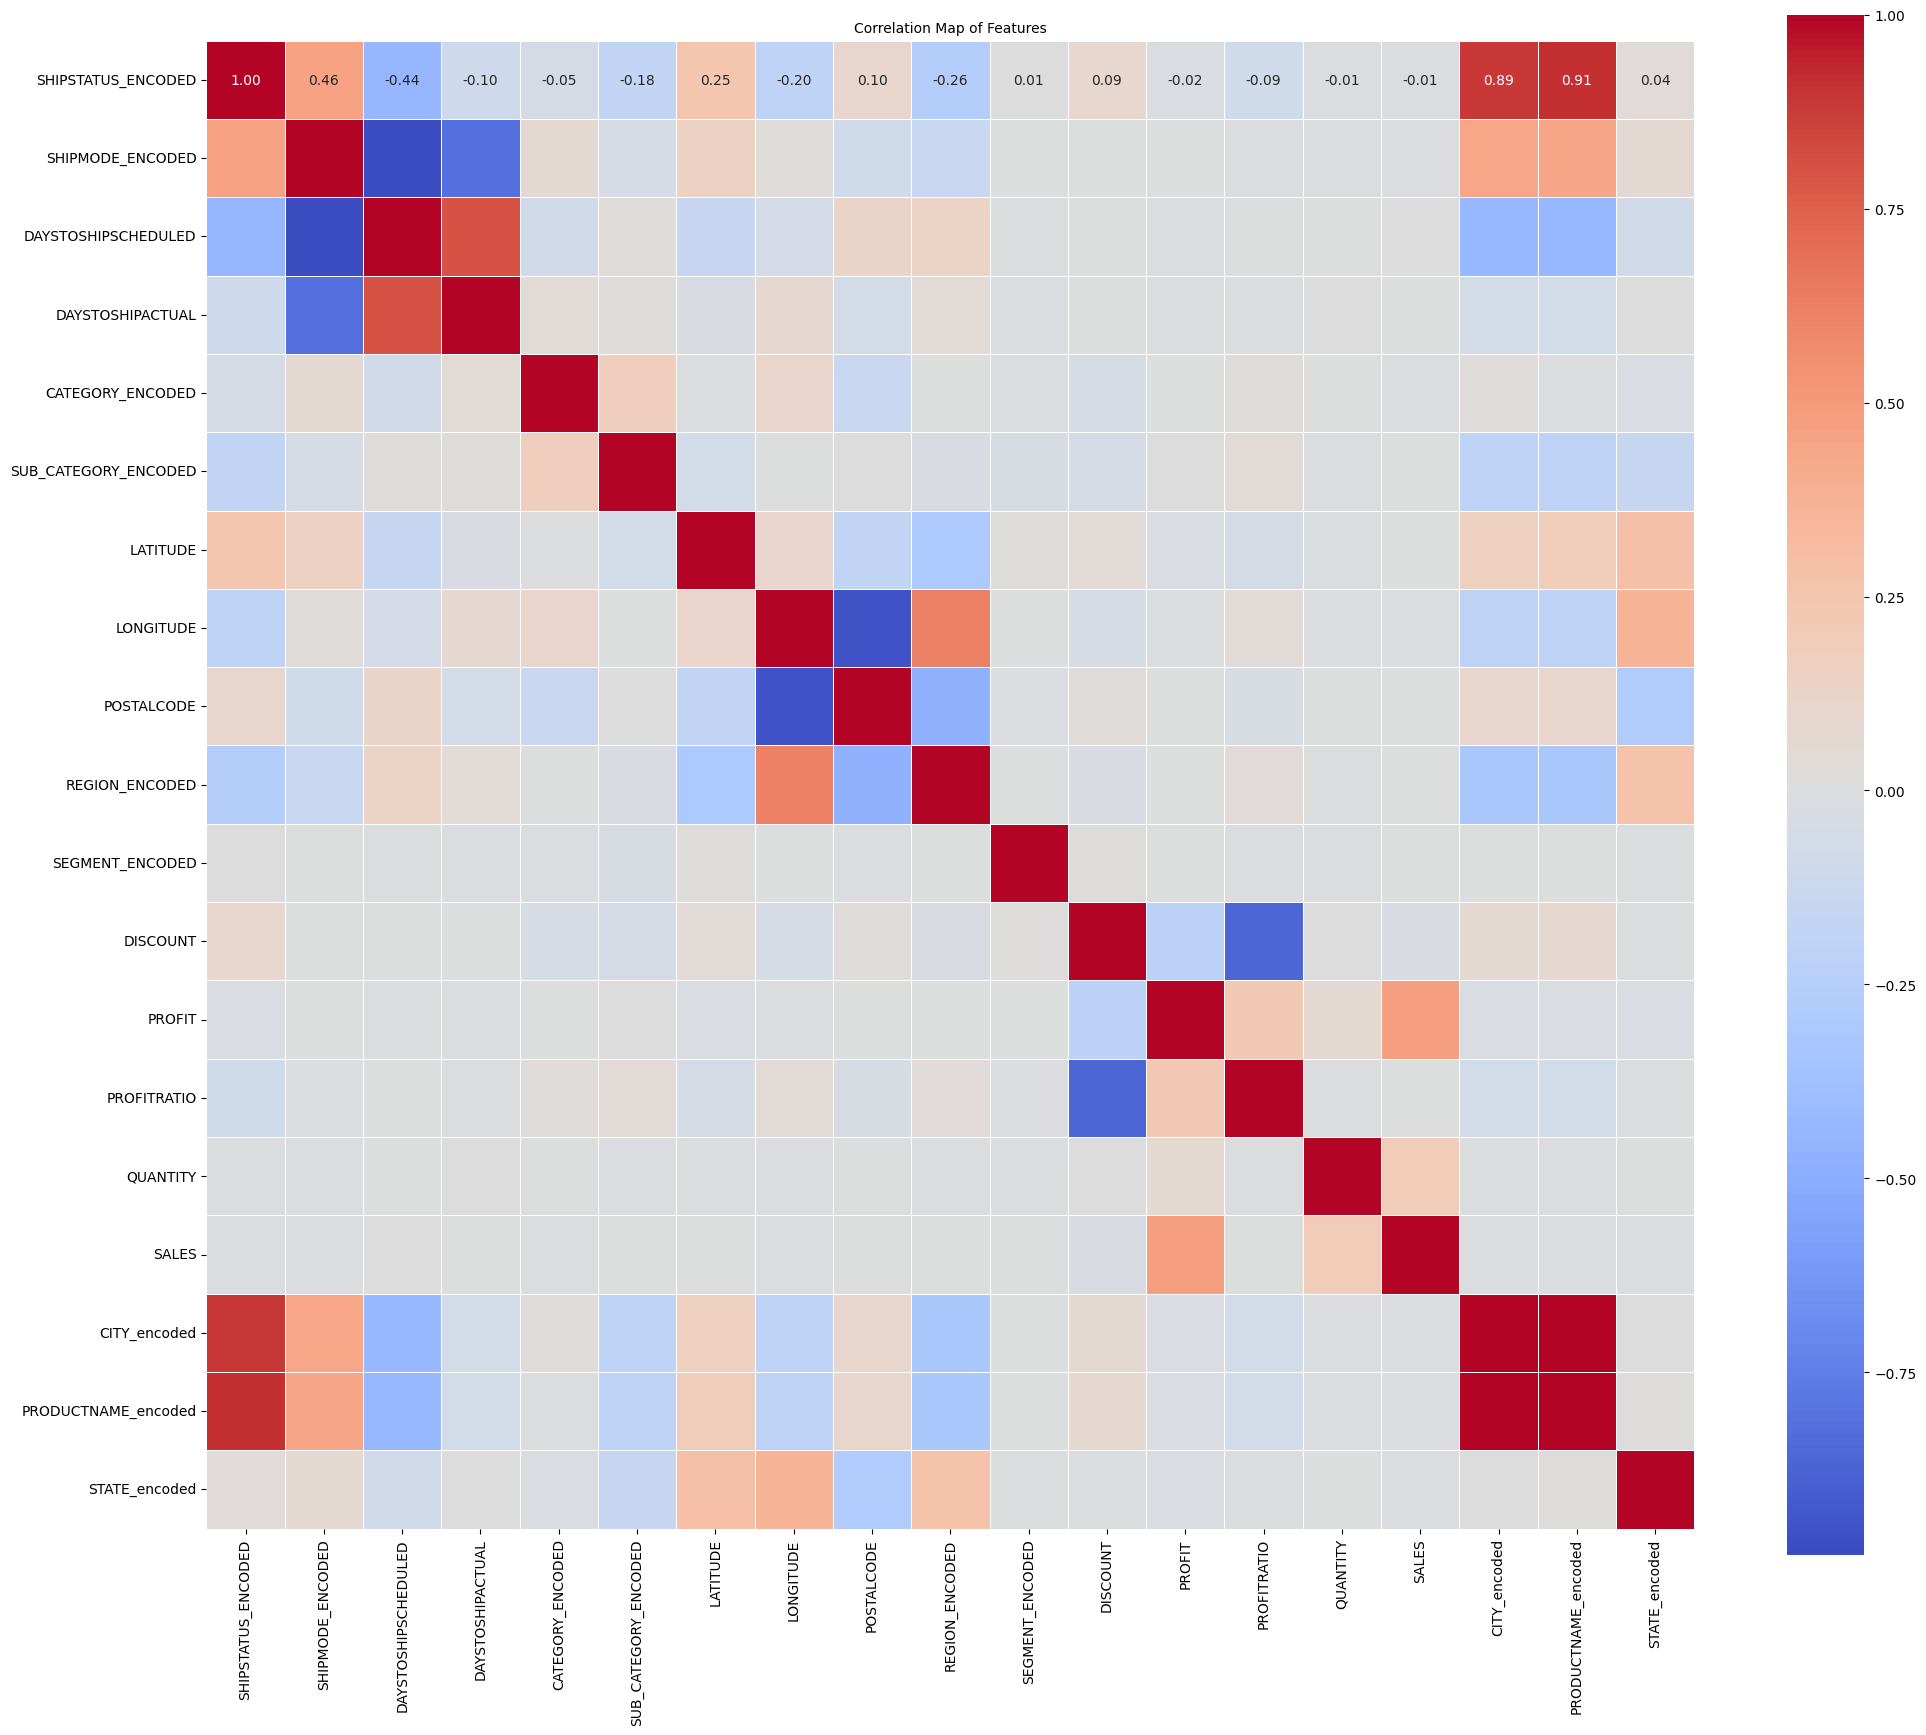

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

corr_matrix = df_q1.corr()

plt.figure(figsize=(24, 20))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, linewidths=0.5)
plt.title("Correlation Map of Features", fontsize=10)
plt.show()

In [55]:
Y = df_q1_copy['SHIPSTATUS_ENCODED'] #CREATE target variable
X = df_q1_copy.drop(['SHIPSTATUS_ENCODED'], axis=1) #create features

In [56]:
from sklearn.model_selection import train_test_split

#spliting dataset into train and test(20%)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [57]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, Y_train)

RandomForestClassifier(random_state=42)

##### Evaluation with accuracy

In [58]:
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(Y_test, y_pred))

Accuracy: 0.9984992496248124


##### Graphs and visualizations

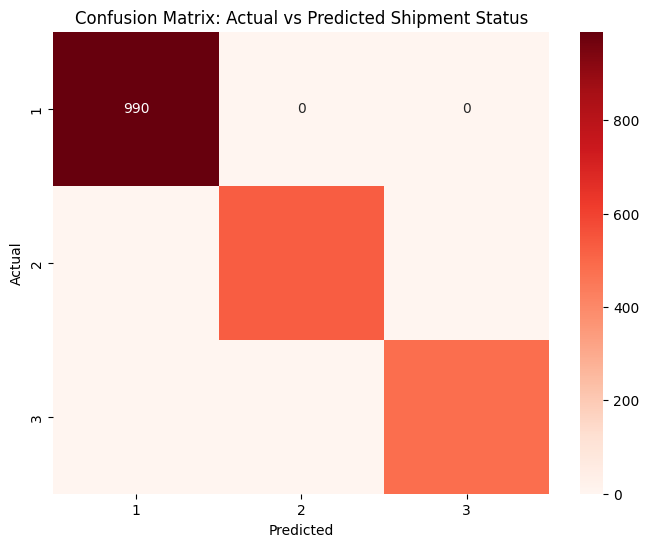

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

comparison_df = pd.DataFrame({'Actual': Y_test, 'Predicted': y_pred})
from sklearn.metrics import confusion_matrix
conf_matrix = confusion_matrix(Y_test, y_pred)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Reds', xticklabels=np.unique(Y), yticklabels=np.unique(Y))
plt.title("Confusion Matrix: Actual vs Predicted Shipment Status")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

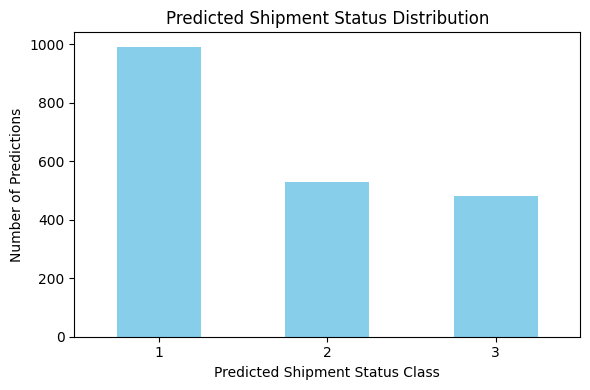

In [60]:
import matplotlib.pyplot as plt

# Count how many predictions fell into each class
prediction_counts = pd.Series(y_pred).value_counts().sort_index()

# Plot as a bar chart
plt.figure(figsize=(6, 4))
prediction_counts.plot(kind='bar', color='skyblue')
plt.title("Predicted Shipment Status Distribution")
plt.xlabel("Predicted Shipment Status Class")
plt.ylabel("Number of Predictions")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


##### Brief explanation of findings

1. ShipMode_encoded has the strongest influence on shipment status.
2. Features like Profit, Region_encoded, and ProductName_encoded show weak or neutral correlation.
3. Class 3 has lower performance, suggesting a class imbalance or overlapping features.


    'Shipped Early': 1,
    'Shipped Late': 2,
    'Shipped On Time': 3



* Most shipments were predicted as “Shipped Early”
* A moderate number as “Shipped Late”
* The least number as “Shipped On Time”

##### 5.2 Predict Sales Forecast

##### Data pulled from warehouse

In [61]:
query2 = """
WITH t1 AS (
    SELECT *, ROW_NUMBER() OVER (ORDER BY ORDERDATE) AS rn
    FROM ASSIGNMENT_DB.ASSIGNMENT_SCHEMA.DIMTIME
),
t2 AS (
    SELECT *, ROW_NUMBER() OVER (ORDER BY SHIPSTATUS_ENCODED) AS rn
    FROM ASSIGNMENT_DB.ASSIGNMENT_SCHEMA.DIMSHIPPING
),

t3 AS (
    SELECT *, ROW_NUMBER() OVER (ORDER BY PRODUCTNAME) AS rn
    FROM ASSIGNMENT_DB.ASSIGNMENT_SCHEMA.DIMPRODUCT
),
t4 AS (
    SELECT *, ROW_NUMBER() OVER (ORDER BY CITY) AS rn
    FROM ASSIGNMENT_DB.ASSIGNMENT_SCHEMA.DIMCUSTOMER
),
t5 AS (
    SELECT *, ROW_NUMBER() OVER (ORDER BY ORDERID) AS rn
    FROM ASSIGNMENT_DB.ASSIGNMENT_SCHEMA.FACTSALES
)

SELECT
    t1.ORDERDATE,
    t1.SHIPDATE,
    t2.SHIPSTATUS_ENCODED,
    t2.SHIPMODE_ENCODED,
    t2.DAYSTOSHIPSCHEDULED,
    t2.DAYSTOSHIPACTUAL,
    t3.PRODUCTNAME,
    t3.CATEGORY_ENCODED,
    t3.SUB_CATEGORY_ENCODED,
    t4.CITY,
    t4.LATITUDE,
    t4.LONGITUDE,
    t4.POSTALCODE,
    t4.STATE,
    t4.REGION_ENCODED,
    t4.SEGMENT_ENCODED,
    t5.DISCOUNT,
    t5.PROFIT,
    t5.PROFITRATIO,
    t5.QUANTITY,
    t5.SALES,
    t5.SALESPERCUSTOMER,
    t5.SALESFORECAST
FROM
    t5
JOIN t2 ON t5.rn = t2.rn
JOIN t3 ON t5.rn = t3.rn
JOIN t4 ON t5.rn = t4.rn
JOIN t1 ON t5.rn = t1.rn;

"""

In [62]:
df_q2 = pd.read_sql(query2, conn)

/var/folders/4k/wvlpxp711yz8cxnbyqjw1zlh0000gn/T/ipykernel_38808/1206029902.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_q2 = pd.read_sql(query2, conn)


In [63]:
df_q2.head()

,ORDERDATE,SHIPDATE,SHIPSTATUS_ENCODED,SHIPMODE_ENCODED,DAYSTOSHIPSCHEDULED,DAYSTOSHIPACTUAL,PRODUCTNAME,CATEGORY_ENCODED,SUB_CATEGORY_ENCODED,CITY,...,STATE,REGION_ENCODED,SEGMENT_ENCODED,DISCOUNT,PROFIT,PROFITRATIO,QUANTITY,SALES,SALESPERCUSTOMER,SALESFORECAST
0,2011-01-04,2011-01-08,1,1,6,5,"#10 Gummed Flap White Envelopes, 100/Box",1,12,Aberdeen,...,South Dakota,3,1,0.0,110.0,29.0,3,378.0,377.97,495.0
1,2011-01-05,2011-01-09,1,1,6,5,"#10 Gummed Flap White Envelopes, 100/Box",1,12,Abilene,...,Texas,3,1,0.2,-88.0,-17.5,3,502.0,502.49,658.0
2,2011-01-05,2011-01-09,1,1,6,5,"#10 Gummed Flap White Envelopes, 100/Box",1,12,Akron,...,Ohio,2,1,0.2,69.0,35.0,6,197.0,196.70,258.0
3,2011-01-05,2011-01-09,1,1,6,5,"#10 Gummed Flap White Envelopes, 100/Box",1,12,Akron,...,Ohio,2,2,0.2,32.0,35.0,6,91.0,91.06,119.0
4,2011-01-06,2011-01-13,1,1,6,4,#10 Self-Seal White Envelopes,1,12,Akron,...,Ohio,2,1,0.2,1.0,33.8,1,4.0,3.93,5.0


##### Feature engineering and preprocessing

in above df_q1 dataframe has importance categorical data.First we should convert those into numerical using label encoding

In [64]:
from sklearn.preprocessing import LabelEncoder

le_city = LabelEncoder()
df_q2['CITY_encoded'] = le_city.fit_transform(df_q2['CITY'])

le_productname = LabelEncoder()
df_q2['PRODUCTNAME_encoded'] = le_city.fit_transform(df_q2['PRODUCTNAME'])

le_state = LabelEncoder()
df_q2['STATE_encoded'] = le_city.fit_transform(df_q2['STATE'])

In [65]:
df_q2.head()

,ORDERDATE,SHIPDATE,SHIPSTATUS_ENCODED,SHIPMODE_ENCODED,DAYSTOSHIPSCHEDULED,DAYSTOSHIPACTUAL,PRODUCTNAME,CATEGORY_ENCODED,SUB_CATEGORY_ENCODED,CITY,...,DISCOUNT,PROFIT,PROFITRATIO,QUANTITY,SALES,SALESPERCUSTOMER,SALESFORECAST,CITY_encoded,PRODUCTNAME_encoded,STATE_encoded
0,2011-01-04,2011-01-08,1,1,6,5,"#10 Gummed Flap White Envelopes, 100/Box",1,12,Aberdeen,...,0.0,110.0,29.0,3,378.0,377.97,495.0,0,0,39
1,2011-01-05,2011-01-09,1,1,6,5,"#10 Gummed Flap White Envelopes, 100/Box",1,12,Abilene,...,0.2,-88.0,-17.5,3,502.0,502.49,658.0,1,0,41
2,2011-01-05,2011-01-09,1,1,6,5,"#10 Gummed Flap White Envelopes, 100/Box",1,12,Akron,...,0.2,69.0,35.0,6,197.0,196.70,258.0,2,0,33
3,2011-01-05,2011-01-09,1,1,6,5,"#10 Gummed Flap White Envelopes, 100/Box",1,12,Akron,...,0.2,32.0,35.0,6,91.0,91.06,119.0,2,0,33
4,2011-01-06,2011-01-13,1,1,6,4,#10 Self-Seal White Envelopes,1,12,Akron,...,0.2,1.0,33.8,1,4.0,3.93,5.0,2,1,33


In [66]:
#drop unnecassary categorical columns
df_q2.drop(['PRODUCTNAME','CITY','STATE'], axis=1, inplace=True) 

In [67]:
df_q2.head()

,ORDERDATE,SHIPDATE,SHIPSTATUS_ENCODED,SHIPMODE_ENCODED,DAYSTOSHIPSCHEDULED,DAYSTOSHIPACTUAL,CATEGORY_ENCODED,SUB_CATEGORY_ENCODED,LATITUDE,LONGITUDE,...,DISCOUNT,PROFIT,PROFITRATIO,QUANTITY,SALES,SALESPERCUSTOMER,SALESFORECAST,CITY_encoded,PRODUCTNAME_encoded,STATE_encoded
0,2011-01-04,2011-01-08,1,1,6,5,1,12,45.4661,-98.4856,...,0.0,110.0,29.0,3,378.0,377.97,495.0,0,0,39
1,2011-01-05,2011-01-09,1,1,6,5,1,12,32.4320,-99.7724,...,0.2,-88.0,-17.5,3,502.0,502.49,658.0,1,0,41
2,2011-01-05,2011-01-09,1,1,6,5,1,12,41.0334,-81.4385,...,0.2,69.0,35.0,6,197.0,196.70,258.0,2,0,33
3,2011-01-05,2011-01-09,1,1,6,5,1,12,41.0334,-81.4385,...,0.2,32.0,35.0,6,91.0,91.06,119.0,2,0,33
4,2011-01-06,2011-01-13,1,1,6,4,1,12,41.0334,-81.4385,...,0.2,1.0,33.8,1,4.0,3.93,5.0,2,1,33


In [68]:
df_q2.shape

(9993, 23)

##### Data mining techniques, evaluation

In [69]:
df_q2_copy = df_q2.copy() #make copy from original

In [70]:
df_q2_copy.drop(['ORDERDATE','SHIPDATE'],axis=1,inplace=True)

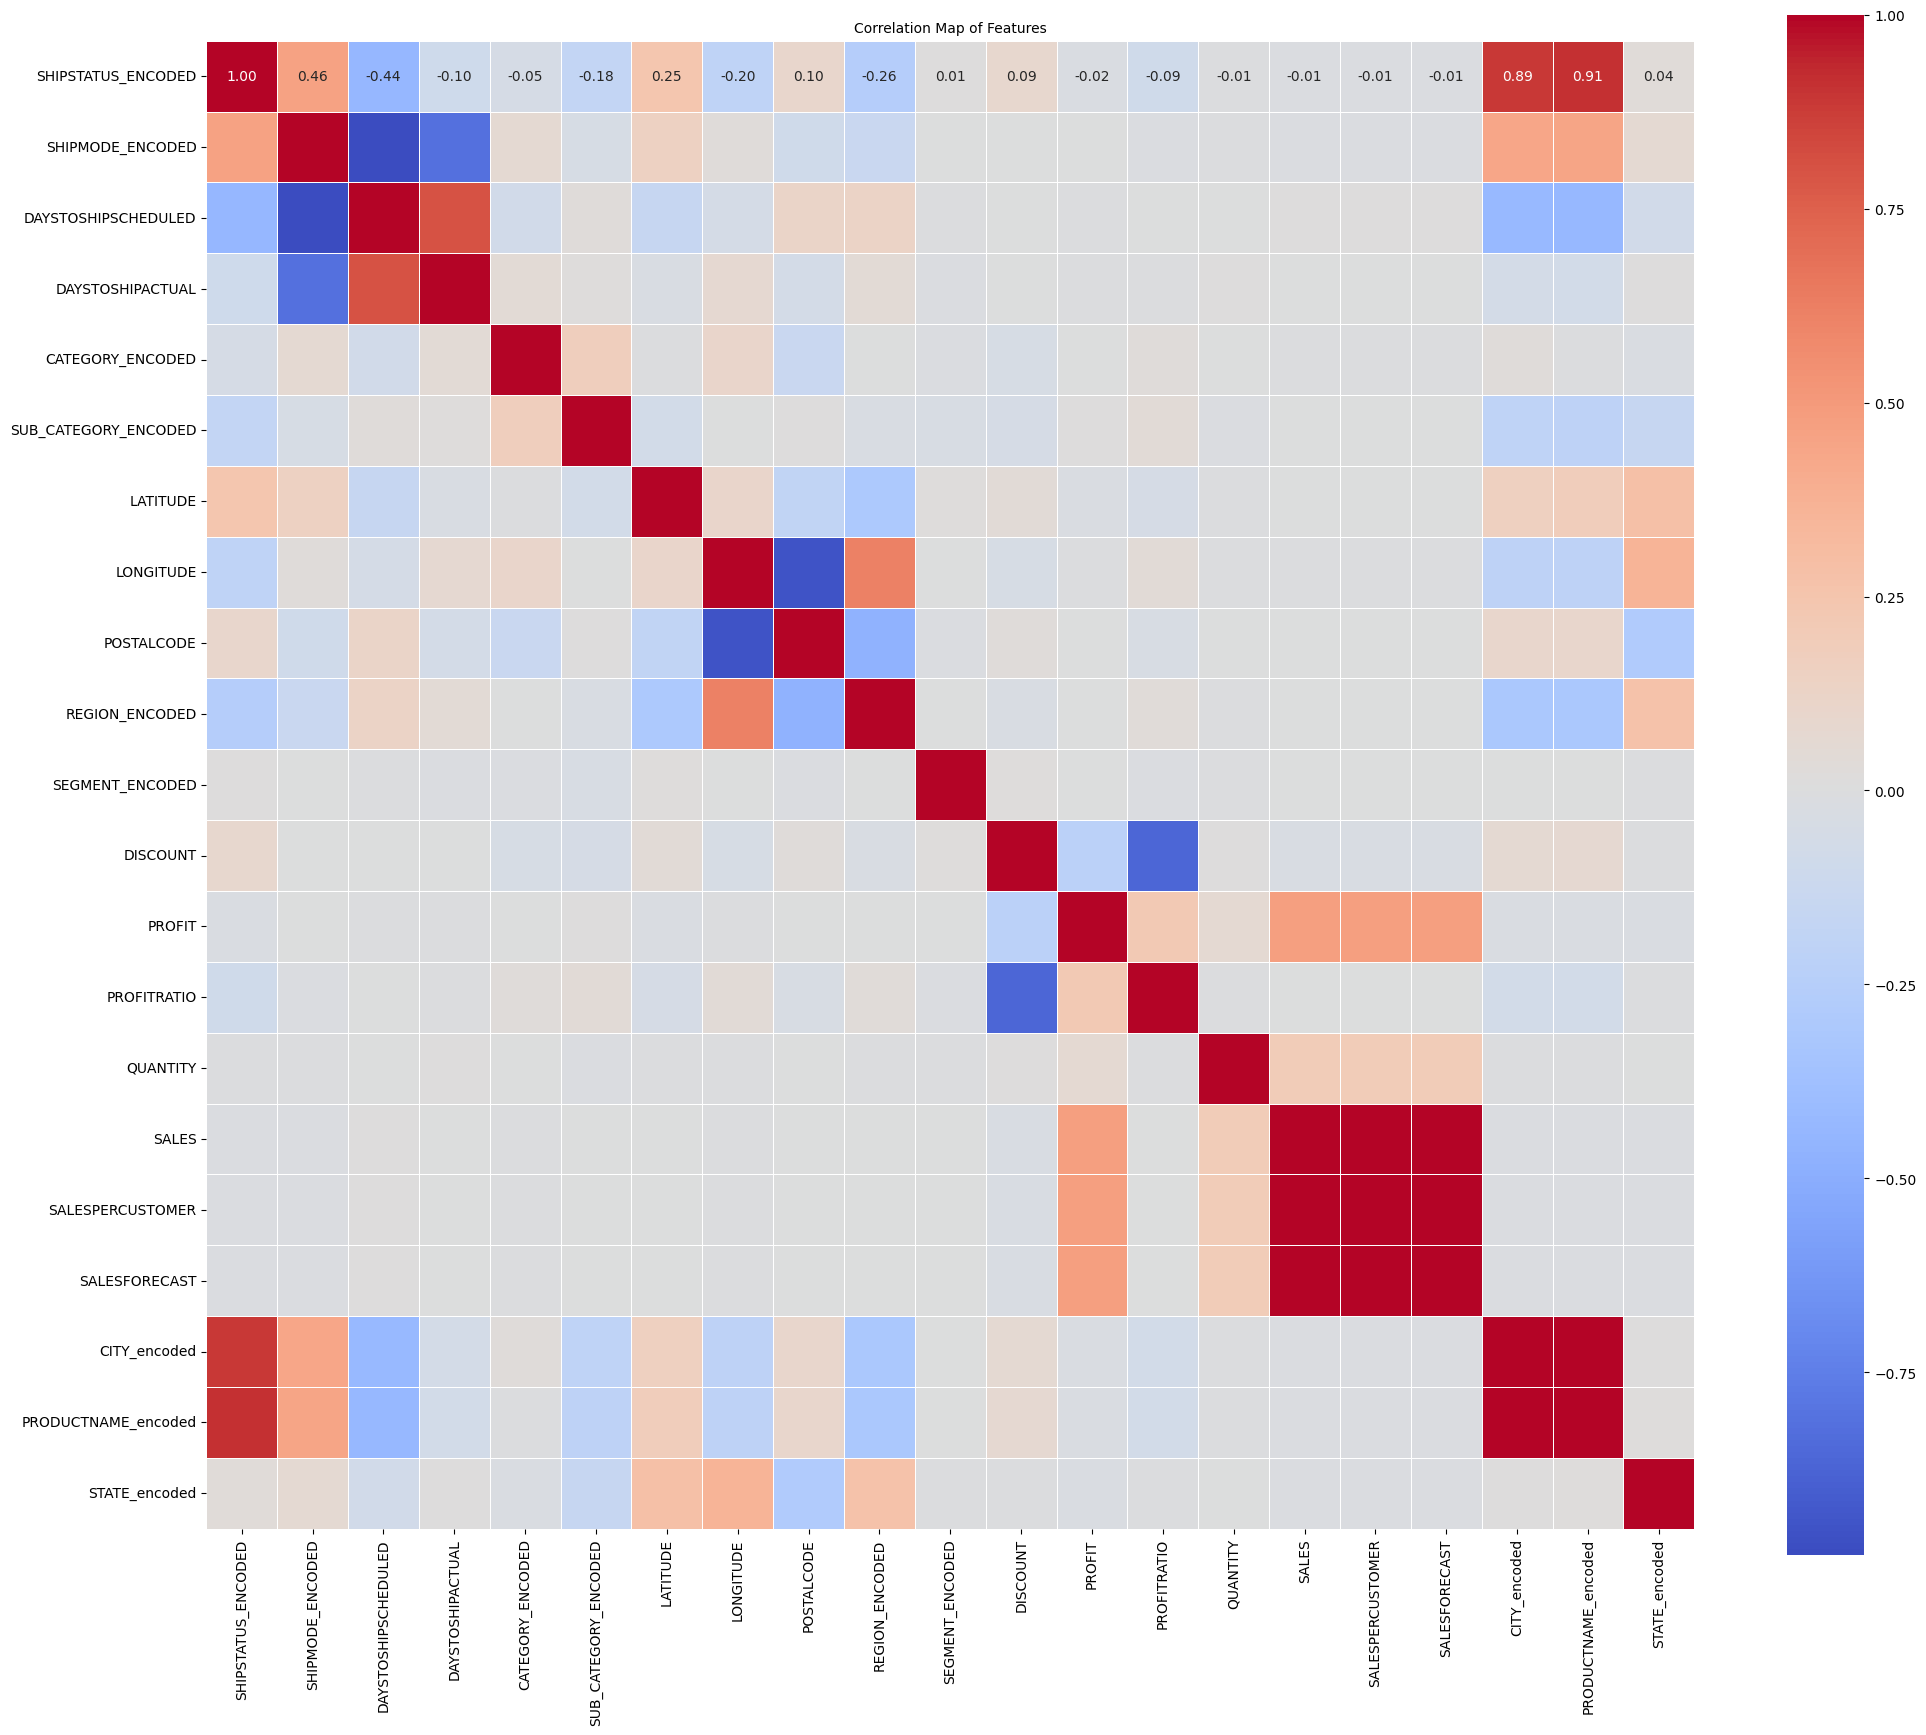

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

corr_matrix = df_q2_copy.corr() 

plt.figure(figsize=(24, 20))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, linewidths=0.5)
plt.title("Correlation Map of Features", fontsize=10)
plt.show()

According to this correlation map . we have to remove following columns

In [72]:
dropCols = [
 'CATEGORY_ENCODED', 'SUB_CATEGORY_ENCODED', 'LATITUDE', 'LONGITUDE',
 'POSTALCODE', 'CITY_encoded', 'STATE_encoded',
 'PRODUCTNAME_encoded', 'DAYSTOSHIPSCHEDULED',
 'DAYSTOSHIPACTUAL', 'SHIPSTATUS_ENCODED','SHIPMODE_ENCODED','REGION_ENCODED','SEGMENT_ENCODED'
]

In [73]:
df_q2_copy.drop(dropCols,axis=1,inplace=True)

In [74]:
df_q2_copy.head()

,DISCOUNT,PROFIT,PROFITRATIO,QUANTITY,SALES,SALESPERCUSTOMER,SALESFORECAST
0,0.0,110.0,29.0,3,378.0,377.97,495.0
1,0.2,-88.0,-17.5,3,502.0,502.49,658.0
2,0.2,69.0,35.0,6,197.0,196.70,258.0
3,0.2,32.0,35.0,6,91.0,91.06,119.0
4,0.2,1.0,33.8,1,4.0,3.93,5.0


In [75]:
Y = df_q2_copy['SALESFORECAST'] #CREATE target variable
X = df_q2_copy.drop(['SALESFORECAST'], axis=1) #create features

In [76]:
from sklearn.model_selection import train_test_split

#spliting dataset into train and test(20%)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [77]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor()
model.fit(X_train, Y_train)

RandomForestRegressor()

In [78]:
y_pred = model.predict(X_test)

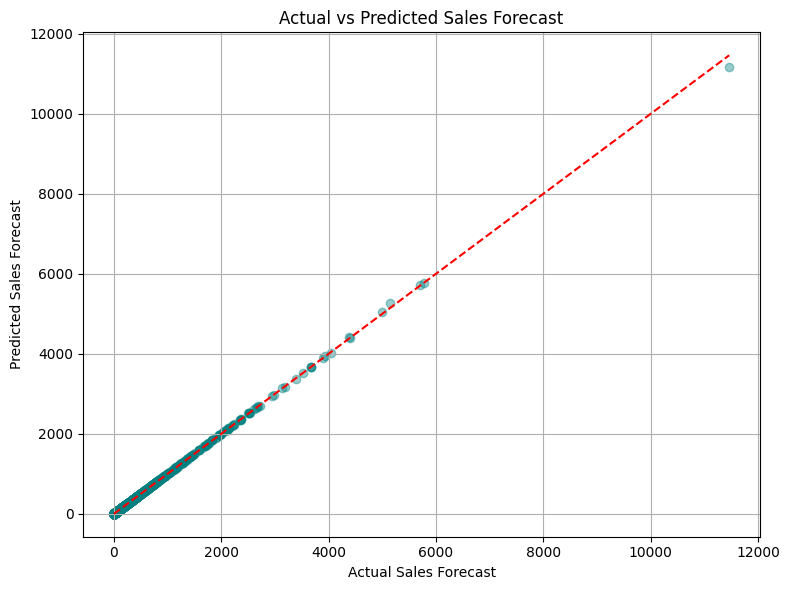

In [79]:
import matplotlib.pyplot as plt

# Plot actual vs predicted values
plt.figure(figsize=(8, 6))
plt.scatter(Y_test, y_pred, alpha=0.4, color='teal')
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--')
plt.xlabel('Actual Sales Forecast')
plt.ylabel('Predicted Sales Forecast')
plt.title('Actual vs Predicted Sales Forecast')
plt.grid(True)
plt.tight_layout()
plt.show()


##### Evaluation with rmse and r-squard

In [80]:
from sklearn.metrics import root_mean_squared_error, r2_score

rmse = root_mean_squared_error(Y_test, y_pred)
r2 = r2_score(Y_test, y_pred)

print("root mean squre error: ",rmse)
print("r-squard: ",r2)


root mean squre error:  7.592584571161184
r-squard:  0.9998439814090101


##### Graphs and visualizations

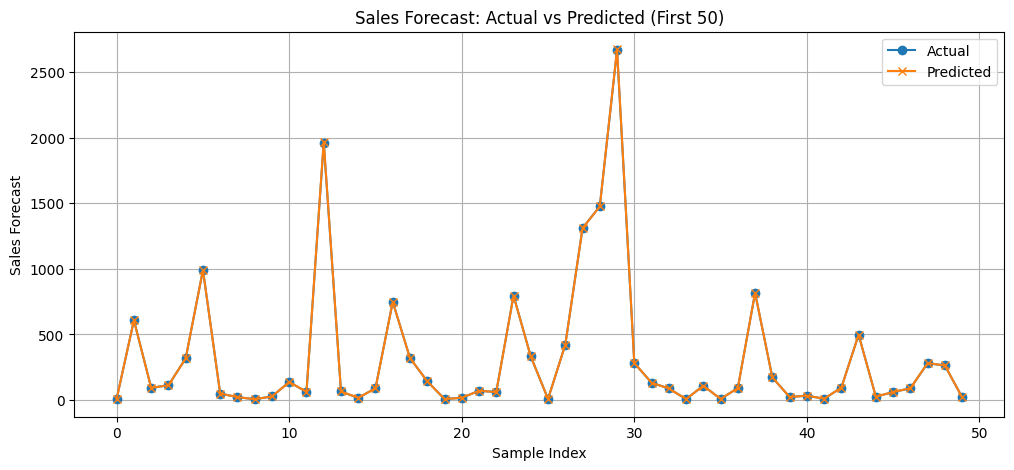

In [81]:
plt.figure(figsize=(12, 5))
plt.plot(Y_test[:50].values, label='Actual', marker='o')
plt.plot(y_pred[:50], label='Predicted', marker='x')
plt.title('Sales Forecast: Actual vs Predicted (First 50)')
plt.xlabel('Sample Index')
plt.ylabel('Sales Forecast')
plt.legend()
plt.grid(True)
plt.show()


In [82]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
import numpy as np

# Initialize the model
model = RandomForestRegressor(n_estimators=100, random_state=42)

# Perform 5-fold cross-validation using negative RMSE
cv_scores = cross_val_score(
    model,
    X,Y,cv=5,scoring='neg_root_mean_squared_error' 
)

cv_rmse_scores = -cv_scores
avg_rmse = np.mean(cv_rmse_scores)

print("Cross-Validation RMSEs:", cv_rmse_scores)
print("Average RMSE:", avg_rmse)


Cross-Validation RMSEs: [261.16193423  12.58291787  81.20647655  45.17165291  26.90125612]
Average RMSE: 85.4048475373217


##### Brief explanation of findings

This sales forecasting model offers a powerful tool for decision-makers to predict and manage future sales. With minimal input and high precision, it supports better budgeting, smarter promotions, and efficient inventory planning—delivering a competitive business advantage

##### 5.3 Predict Order Profitability

In [83]:
query3 = """
WITH t1 AS (
    SELECT *, ROW_NUMBER() OVER (ORDER BY ORDERDATE) AS rn
    FROM ASSIGNMENT_DB.ASSIGNMENT_SCHEMA.DIMTIME
),
t2 AS (
    SELECT *, ROW_NUMBER() OVER (ORDER BY SHIPSTATUS_ENCODED) AS rn
    FROM ASSIGNMENT_DB.ASSIGNMENT_SCHEMA.DIMSHIPPING
),

t3 AS (
    SELECT *, ROW_NUMBER() OVER (ORDER BY PRODUCTNAME) AS rn
    FROM ASSIGNMENT_DB.ASSIGNMENT_SCHEMA.DIMPRODUCT
),
t4 AS (
    SELECT *, ROW_NUMBER() OVER (ORDER BY CITY) AS rn
    FROM ASSIGNMENT_DB.ASSIGNMENT_SCHEMA.DIMCUSTOMER
),
t5 AS (
    SELECT *, ROW_NUMBER() OVER (ORDER BY ORDERID) AS rn
    FROM ASSIGNMENT_DB.ASSIGNMENT_SCHEMA.FACTSALES
)

SELECT
    t2.SHIPSTATUS_ENCODED,
    t2.SHIPMODE_ENCODED,
    t2.DAYSTOSHIPSCHEDULED,
    t2.DAYSTOSHIPACTUAL,
    t3.CATEGORY_ENCODED, 
    t3.SUB_CATEGORY_ENCODED,
    t4.REGION_ENCODED,
    t4.SEGMENT_ENCODED,
    t5.DISCOUNT,
    t5.PROFIT,
    t5.PROFITRATIO,
    t5.QUANTITY,
    t5.SALES,
    t5.SALESPERCUSTOMER,
FROM
    t5
JOIN t2 ON t5.rn = t2.rn
JOIN t3 ON t5.rn = t3.rn
JOIN t4 ON t5.rn = t4.rn
JOIN t1 ON t5.rn = t1.rn;

"""

In [84]:
df_q3 = pd.read_sql(query3, conn)

/var/folders/4k/wvlpxp711yz8cxnbyqjw1zlh0000gn/T/ipykernel_38808/492894181.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_q3 = pd.read_sql(query3, conn)


In [85]:
df_q3.head()

,SHIPSTATUS_ENCODED,SHIPMODE_ENCODED,DAYSTOSHIPSCHEDULED,DAYSTOSHIPACTUAL,CATEGORY_ENCODED,SUB_CATEGORY_ENCODED,REGION_ENCODED,SEGMENT_ENCODED,DISCOUNT,PROFIT,PROFITRATIO,QUANTITY,SALES,SALESPERCUSTOMER
0,1,1,6,5,1,12,3,1,0.0,110.0,29.0,3,378.0,377.97
1,1,1,6,5,1,12,3,1,0.2,-88.0,-17.5,3,502.0,502.49
2,1,1,6,5,1,12,2,1,0.2,69.0,35.0,6,197.0,196.70
3,1,1,6,5,1,12,2,2,0.2,32.0,35.0,6,91.0,91.06
4,1,1,6,4,1,12,2,1,0.2,1.0,33.8,1,4.0,3.93


##### Feature engineering and preprocessing

Column: PROFIT
Number of outliers: 1924
------------------------------


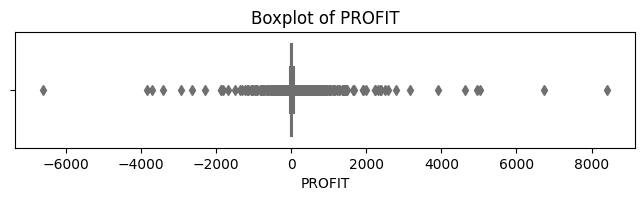

Column: SALES
Number of outliers: 1166
------------------------------


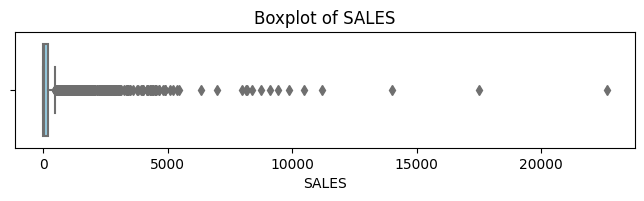

Column: DISCOUNT
Number of outliers: 856
------------------------------


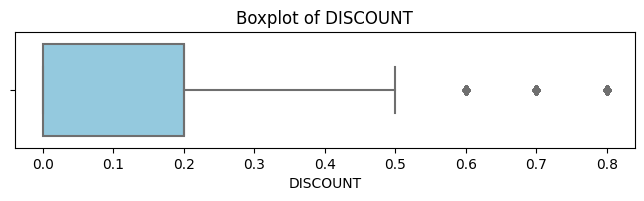

In [86]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Columns to analyze
columns_to_check = ['PROFIT', 'SALES', 'DISCOUNT']

for col in columns_to_check:
    # Calculate IQR
    Q1 = df_q3[col].quantile(0.25)
    Q3 = df_q3[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify outliers
    outliers = df_q3[(df_q3[col] < lower_bound) | (df_q3[col] > upper_bound)]

    print(f"Column: {col}")
    print(f"Number of outliers: {len(outliers)}")
    print("-" * 30)

    # Plot boxplot
    plt.figure(figsize=(8, 1.5))
    sns.boxplot(x=df_q3[col], color='skyblue')
    plt.title(f'Boxplot of {col}')
    plt.show()


In [87]:
df_q3_copy = df_q3.copy()

In [88]:
df_q3_copy = df_q3_copy[(df_q3_copy[col] >= lower_bound) & (df_q3_copy[col] <= upper_bound)]

Column: PROFIT
Number of outliers: 1508
------------------------------


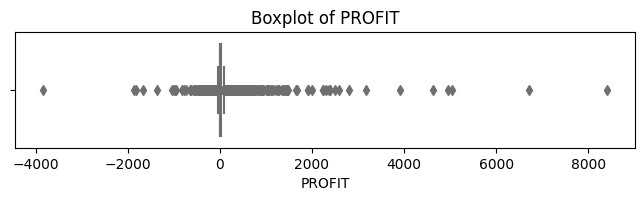

Column: SALES
Number of outliers: 1020
------------------------------


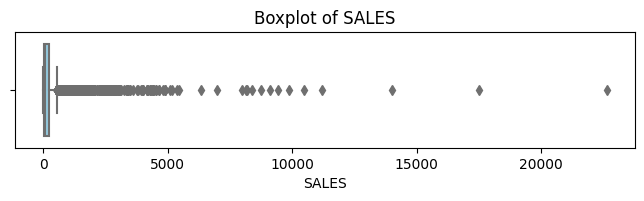

Column: DISCOUNT
Number of outliers: 0
------------------------------


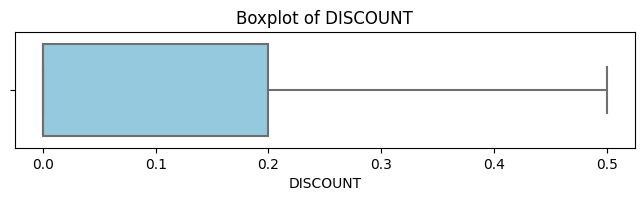

In [89]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Columns to analyze
columns_to_check = ['PROFIT', 'SALES', 'DISCOUNT']

for col in columns_to_check:
    # Calculate IQR
    Q1 = df_q3_copy[col].quantile(0.25)
    Q3 = df_q3_copy[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify outliers
    outliers = df_q3_copy[(df_q3_copy[col] < lower_bound) | (df_q3_copy[col] > upper_bound)]

    print(f"Column: {col}")
    print(f"Number of outliers: {len(outliers)}")
    print("-" * 30)

    # Plot boxplot
    plt.figure(figsize=(8, 1.5))
    sns.boxplot(x=df_q3_copy[col], color='skyblue')
    plt.title(f'Boxplot of {col}')
    plt.show()


In [90]:
df_q3 = df_q3_copy

In [91]:
df_q3.head()

,SHIPSTATUS_ENCODED,SHIPMODE_ENCODED,DAYSTOSHIPSCHEDULED,DAYSTOSHIPACTUAL,CATEGORY_ENCODED,SUB_CATEGORY_ENCODED,REGION_ENCODED,SEGMENT_ENCODED,DISCOUNT,PROFIT,PROFITRATIO,QUANTITY,SALES,SALESPERCUSTOMER
0,1,1,6,5,1,12,3,1,0.0,110.0,29.0,3,378.0,377.97
1,1,1,6,5,1,12,3,1,0.2,-88.0,-17.5,3,502.0,502.49
2,1,1,6,5,1,12,2,1,0.2,69.0,35.0,6,197.0,196.70
3,1,1,6,5,1,12,2,2,0.2,32.0,35.0,6,91.0,91.06
4,1,1,6,4,1,12,2,1,0.2,1.0,33.8,1,4.0,3.93


In [92]:
df_q3.shape

(9137, 14)

##### Data mining techniques, evaluation

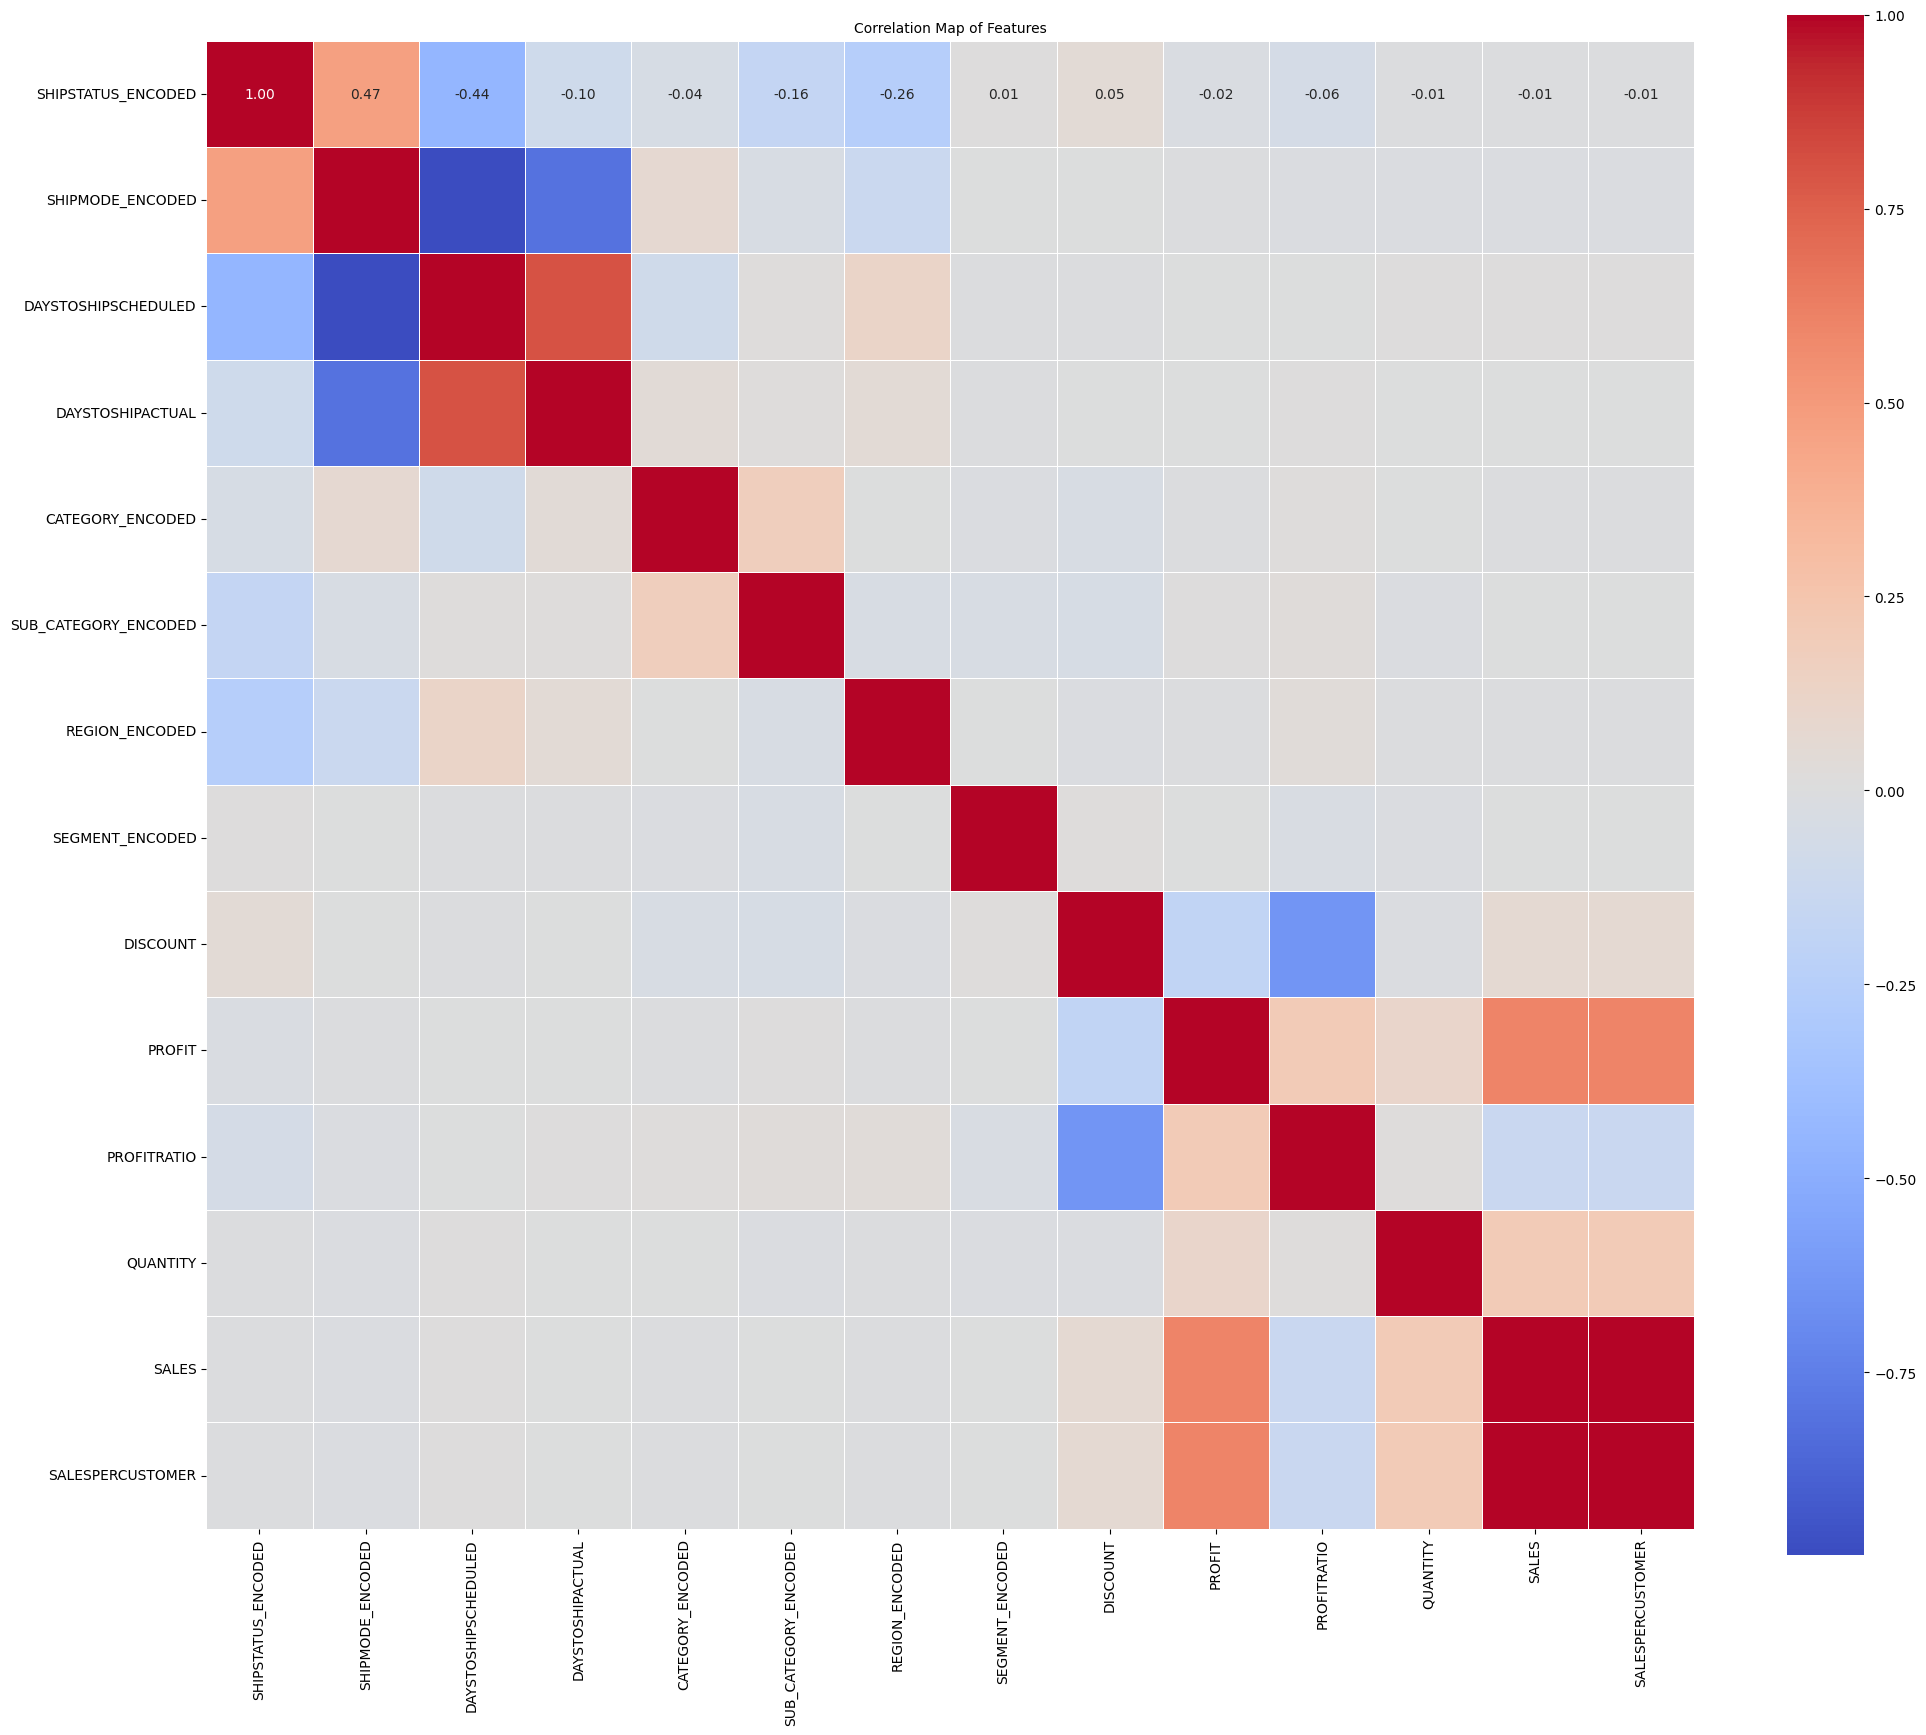

In [93]:
import matplotlib.pyplot as plt
import seaborn as sns

corr_matrix = df_q3.corr() 

plt.figure(figsize=(24, 20))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, linewidths=0.5)
plt.title("Correlation Map of Features", fontsize=10)
plt.show()

In [94]:
dropCols = ['SALESPERCUSTOMER','DAYSTOSHIPACTUAL','SUB_CATEGORY_ENCODED']
df_q3.drop(dropCols,axis=1,inplace=True)

In [95]:
df_q3.head()

,SHIPSTATUS_ENCODED,SHIPMODE_ENCODED,DAYSTOSHIPSCHEDULED,CATEGORY_ENCODED,REGION_ENCODED,SEGMENT_ENCODED,DISCOUNT,PROFIT,PROFITRATIO,QUANTITY,SALES
0,1,1,6,1,3,1,0.0,110.0,29.0,3,378.0
1,1,1,6,1,3,1,0.2,-88.0,-17.5,3,502.0
2,1,1,6,1,2,1,0.2,69.0,35.0,6,197.0
3,1,1,6,1,2,2,0.2,32.0,35.0,6,91.0
4,1,1,6,1,2,1,0.2,1.0,33.8,1,4.0


In [96]:
Y = df_q3['PROFIT'] #target variable
X = df_q3.drop(['PROFIT'],axis=1) #create feature

##### Evaluation with rmse and r-squard

In [97]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, r2_score

# Split data
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Train model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, Y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
rmse = root_mean_squared_error(Y_test, y_pred)
r2 = r2_score(Y_test, y_pred)

rmse, r2 

(35.05790422926044, 0.9450298194341162)

##### Graphs and visualizations

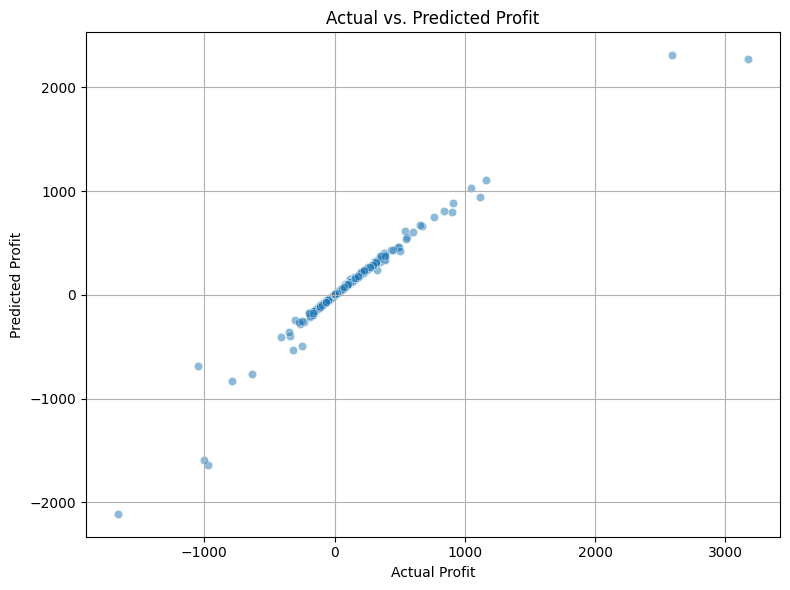

In [98]:
# Plot predicted vs actual
plt.figure(figsize=(8, 6))
sns.scatterplot(x=Y_test, y=y_pred, alpha=0.5)
plt.xlabel("Actual Profit")
plt.ylabel("Predicted Profit")
plt.title("Actual vs. Predicted Profit")
plt.grid(True)
plt.tight_layout()
plt.show()

##### 5.4 Cluster Orders by Buying Behavior - Group orders by similar buying patterns

In [99]:
query4 = ''' 
WITH t1 AS (
    SELECT *, ROW_NUMBER() OVER (ORDER BY ORDERDATE) AS rn
    FROM ASSIGNMENT_DB.ASSIGNMENT_SCHEMA.DIMTIME
),
t2 AS (
    SELECT *, ROW_NUMBER() OVER (ORDER BY SHIPSTATUS_ENCODED) AS rn
    FROM ASSIGNMENT_DB.ASSIGNMENT_SCHEMA.DIMSHIPPING
),

t3 AS (
    SELECT *, ROW_NUMBER() OVER (ORDER BY PRODUCTNAME) AS rn
    FROM ASSIGNMENT_DB.ASSIGNMENT_SCHEMA.DIMPRODUCT
),
t4 AS (
    SELECT *, ROW_NUMBER() OVER (ORDER BY CITY) AS rn
    FROM ASSIGNMENT_DB.ASSIGNMENT_SCHEMA.DIMCUSTOMER
),
t5 AS (
    SELECT *, ROW_NUMBER() OVER (ORDER BY ORDERID) AS rn
    FROM ASSIGNMENT_DB.ASSIGNMENT_SCHEMA.FACTSALES
)

SELECT
    t3.CATEGORY_ENCODED, 
    t3.SUB_CATEGORY_ENCODED,
    t4.SEGMENT_ENCODED,
    t5.DISCOUNT,
    t5.PROFIT,
    t5.PROFITRATIO,
    t5.QUANTITY,
    t5.SALES,
    t5.SALESPERCUSTOMER,
FROM
    t5
JOIN t2 ON t5.rn = t2.rn
JOIN t3 ON t5.rn = t3.rn
JOIN t4 ON t5.rn = t4.rn
JOIN t1 ON t5.rn = t1.rn;

'''

In [100]:
df_q4 = pd.read_sql(query4, conn)

/var/folders/4k/wvlpxp711yz8cxnbyqjw1zlh0000gn/T/ipykernel_38808/4102763816.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_q4 = pd.read_sql(query4, conn)


In [101]:
df_q4.head()

,CATEGORY_ENCODED,SUB_CATEGORY_ENCODED,SEGMENT_ENCODED,DISCOUNT,PROFIT,PROFITRATIO,QUANTITY,SALES,SALESPERCUSTOMER
0,1,12,1,0.0,110.0,29.0,3,378.0,377.97
1,1,12,1,0.2,-88.0,-17.5,3,502.0,502.49
2,1,12,1,0.2,69.0,35.0,6,197.0,196.70
3,1,12,2,0.2,32.0,35.0,6,91.0,91.06
4,1,12,1,0.2,1.0,33.8,1,4.0,3.93


##### Feature engineering and preprocessing

In [102]:
from sklearn.preprocessing import StandardScaler
X_cluster = df_q4

# Normalize data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

##### Data mining techniques, evaluation

In [103]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

# Find optimal number of clusters using silhouette score
silhouette_scores = []
k_range = range(2, 10)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    score = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_scores.append(score)

##### Evaluation with silhouette_score

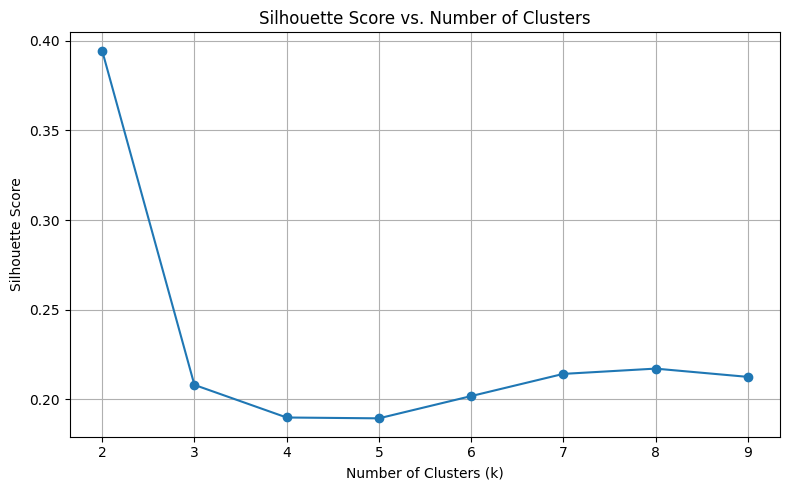

In [104]:
# Plot silhouette scores to find the best k
plt.figure(figsize=(8, 5))
plt.plot(k_range, silhouette_scores, marker='o')
plt.title("Silhouette Score vs. Number of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.tight_layout()
plt.show()

according to silhouette score, optimal_k is 2

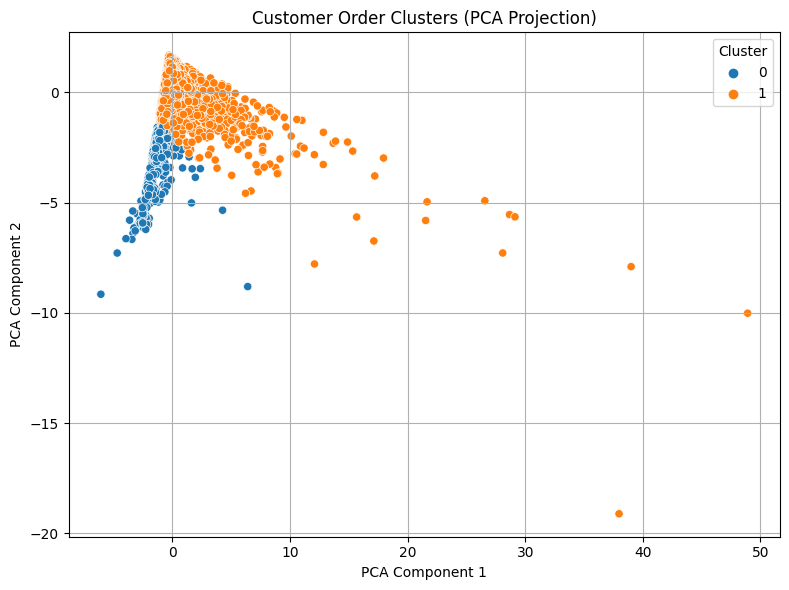

In [105]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

optimal_k = 2
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
df_q4['Cluster'] = kmeans.fit_predict(X_scaled)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df_q4['PCA1'] = X_pca[:, 0]
df_q4['PCA2'] = X_pca[:, 1]

# Visualize
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_q4, x='PCA1', y='PCA2', hue='Cluster', palette='tab10')
plt.title("Customer Order Clusters (PCA Projection)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)
plt.tight_layout()
plt.show()

##### 5.5 Visualize shipment performance across geographies

In [106]:
query5 = """     
WITH t1 AS (
    SELECT *, ROW_NUMBER() OVER (ORDER BY ORDERDATE) AS rn
    FROM ASSIGNMENT_DB.ASSIGNMENT_SCHEMA.DIMTIME
),
t2 AS (
    SELECT *, ROW_NUMBER() OVER (ORDER BY SHIPSTATUS_ENCODED) AS rn
    FROM ASSIGNMENT_DB.ASSIGNMENT_SCHEMA.DIMSHIPPING
),

t3 AS (
    SELECT *, ROW_NUMBER() OVER (ORDER BY PRODUCTNAME) AS rn
    FROM ASSIGNMENT_DB.ASSIGNMENT_SCHEMA.DIMPRODUCT
),
t4 AS (
    SELECT *, ROW_NUMBER() OVER (ORDER BY CITY) AS rn
    FROM ASSIGNMENT_DB.ASSIGNMENT_SCHEMA.DIMCUSTOMER
),
t5 AS (
    SELECT *, ROW_NUMBER() OVER (ORDER BY ORDERID) AS rn
    FROM ASSIGNMENT_DB.ASSIGNMENT_SCHEMA.FACTSALES
)

SELECT
    t2.SHIPSTATUS_ENCODED,
    t2.SHIPMODE_ENCODED,
    t2.DAYSTOSHIPSCHEDULED,
    t2.DAYSTOSHIPACTUAL,
    t3.CATEGORY_ENCODED, 
    t3.SUB_CATEGORY_ENCODED,
    t4.LATITUDE,
    t4.LONGITUDE,
    t4.STATE
FROM
    t5
JOIN t2 ON t5.rn = t2.rn
JOIN t3 ON t5.rn = t3.rn
JOIN t4 ON t5.rn = t4.rn
JOIN t1 ON t5.rn = t1.rn;

"""

In [107]:
df_q5 = pd.read_sql(query5, conn)

/var/folders/4k/wvlpxp711yz8cxnbyqjw1zlh0000gn/T/ipykernel_38808/2436508198.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_q5 = pd.read_sql(query5, conn)


In [108]:
df_q5.head()

,SHIPSTATUS_ENCODED,SHIPMODE_ENCODED,DAYSTOSHIPSCHEDULED,DAYSTOSHIPACTUAL,CATEGORY_ENCODED,SUB_CATEGORY_ENCODED,LATITUDE,LONGITUDE,STATE
0,1,1,6,5,1,12,45.4661,-98.4856,South Dakota
1,1,1,6,5,1,12,32.4320,-99.7724,Texas
2,1,1,6,5,1,12,41.0334,-81.4385,Ohio
3,1,1,6,5,1,12,41.0334,-81.4385,Ohio
4,1,1,6,4,1,12,41.0334,-81.4385,Ohio


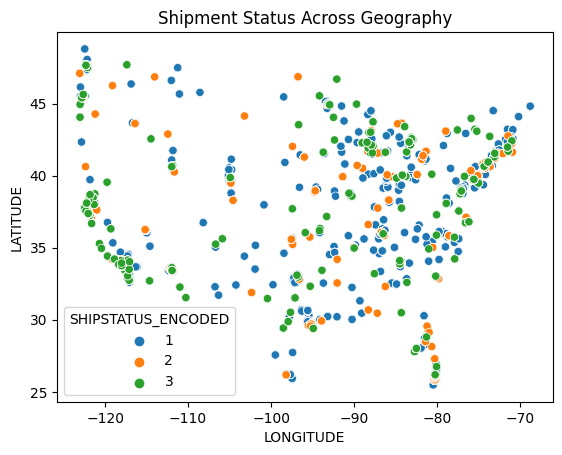

In [109]:
sns.scatterplot(data=df_q5, x='LONGITUDE', y='LATITUDE', hue='SHIPSTATUS_ENCODED')
plt.title('Shipment Status Across Geography')
plt.show()

##### 5.6 Analyze delivery delays or profit trends by latitude/longitude

##### Data pulled from warehouse

In [110]:
query6 = """
WITH t1 AS (
    SELECT *, ROW_NUMBER() OVER (ORDER BY ORDERDATE) AS rn
    FROM ASSIGNMENT_DB.ASSIGNMENT_SCHEMA.DIMTIME
),
t2 AS (
    SELECT *, ROW_NUMBER() OVER (ORDER BY SHIPSTATUS_ENCODED) AS rn
    FROM ASSIGNMENT_DB.ASSIGNMENT_SCHEMA.DIMSHIPPING
),

t3 AS (
    SELECT *, ROW_NUMBER() OVER (ORDER BY PRODUCTNAME) AS rn
    FROM ASSIGNMENT_DB.ASSIGNMENT_SCHEMA.DIMPRODUCT
),
t4 AS (
    SELECT *, ROW_NUMBER() OVER (ORDER BY CITY) AS rn
    FROM ASSIGNMENT_DB.ASSIGNMENT_SCHEMA.DIMCUSTOMER
),
t5 AS (
    SELECT *, ROW_NUMBER() OVER (ORDER BY ORDERID) AS rn
    FROM ASSIGNMENT_DB.ASSIGNMENT_SCHEMA.FACTSALES
)

SELECT
    t2.DAYSTOSHIPSCHEDULED,
    t2.DAYSTOSHIPACTUAL,
    t4.CITY,
    t4.LATITUDE,
    t4.LONGITUDE,
    t4.STATE,
    t5.ORDERID,
    t5.DISCOUNT,
    t5.PROFIT,
    t5.QUANTITY,
    t5.SALES
FROM
    t5
JOIN t2 ON t5.rn = t2.rn
JOIN t3 ON t5.rn = t3.rn
JOIN t4 ON t5.rn = t4.rn
JOIN t1 ON t5.rn = t1.rn;

"""

In [111]:
df_q6 = pd.read_sql(query6,conn)

/var/folders/4k/wvlpxp711yz8cxnbyqjw1zlh0000gn/T/ipykernel_38808/1861922320.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_q6 = pd.read_sql(query6,conn)


In [112]:
df_q6.head()

,DAYSTOSHIPSCHEDULED,DAYSTOSHIPACTUAL,CITY,LATITUDE,LONGITUDE,STATE,ORDERID,DISCOUNT,PROFIT,QUANTITY,SALES
0,6,5,Aberdeen,45.4661,-98.4856,South Dakota,CA-2011-100006,0.0,110.0,3,378.0
1,6,5,Abilene,32.4320,-99.7724,Texas,CA-2011-100090,0.2,-88.0,3,502.0
2,6,5,Akron,41.0334,-81.4385,Ohio,CA-2011-100090,0.2,69.0,6,197.0
3,6,5,Akron,41.0334,-81.4385,Ohio,CA-2011-100293,0.2,32.0,6,91.0
4,6,4,Akron,41.0334,-81.4385,Ohio,CA-2011-100328,0.2,1.0,1,4.0


##### Data mining techniques, evaluation

In [113]:
import plotly.express as px

#Feature Engineering
df_q6['ShippingDelay'] = df_q6['DAYSTOSHIPACTUAL'] - df_q6['DAYSTOSHIPSCHEDULED']

#Group by coordinates and calculate average delivery delay and profit
latlong_summary = df_q6.groupby(['LATITUDE', 'LONGITUDE']).agg({
    'ShippingDelay': 'mean',
    'PROFIT': 'mean',
    'ORDERID': 'count'
}).reset_index().rename(columns={
    'ShippingDelay': 'AvgShippingDelay',
    'PROFIT': 'AvgProfit',
    'ORDERID': 'OrderCount'
})

#Evaluation metrics (simple descriptive)
avg_delay = latlong_summary['AvgShippingDelay'].mean()
avg_profit = latlong_summary['AvgProfit'].mean()


##### Graphs and visualizations

In [114]:
# 1. Heat scatter of delivery delays
fig1 = px.scatter_geo(latlong_summary,
                      lat='LATITUDE',
                      lon='LONGITUDE',
                      color='AvgShippingDelay',
                      size='OrderCount',
                      hover_name='AvgShippingDelay',
                      title='Average Delivery Delay by Location',
                      projection='natural earth')
fig1.show()

# 2. Heat scatter of profit trends
fig2 = px.scatter_geo(latlong_summary,
                      lat='LATITUDE',
                      lon='LONGITUDE',
                      color='AvgProfit',
                      size='OrderCount',
                      hover_name='AvgProfit',
                      title='Average Profit by Location',
                      projection='natural earth')
fig2.show()

avg_delay, avg_profit


(-0.5310038511800921, 30.750377457196787)

### Data visualization with power BI

dashboard link - https://app.powerbi.com/groups/me/reports/f2f8b9ae-5fd4-4f35-9517-8f843fc752cc/307a28d0c082b02d05c5?experience=power-bi

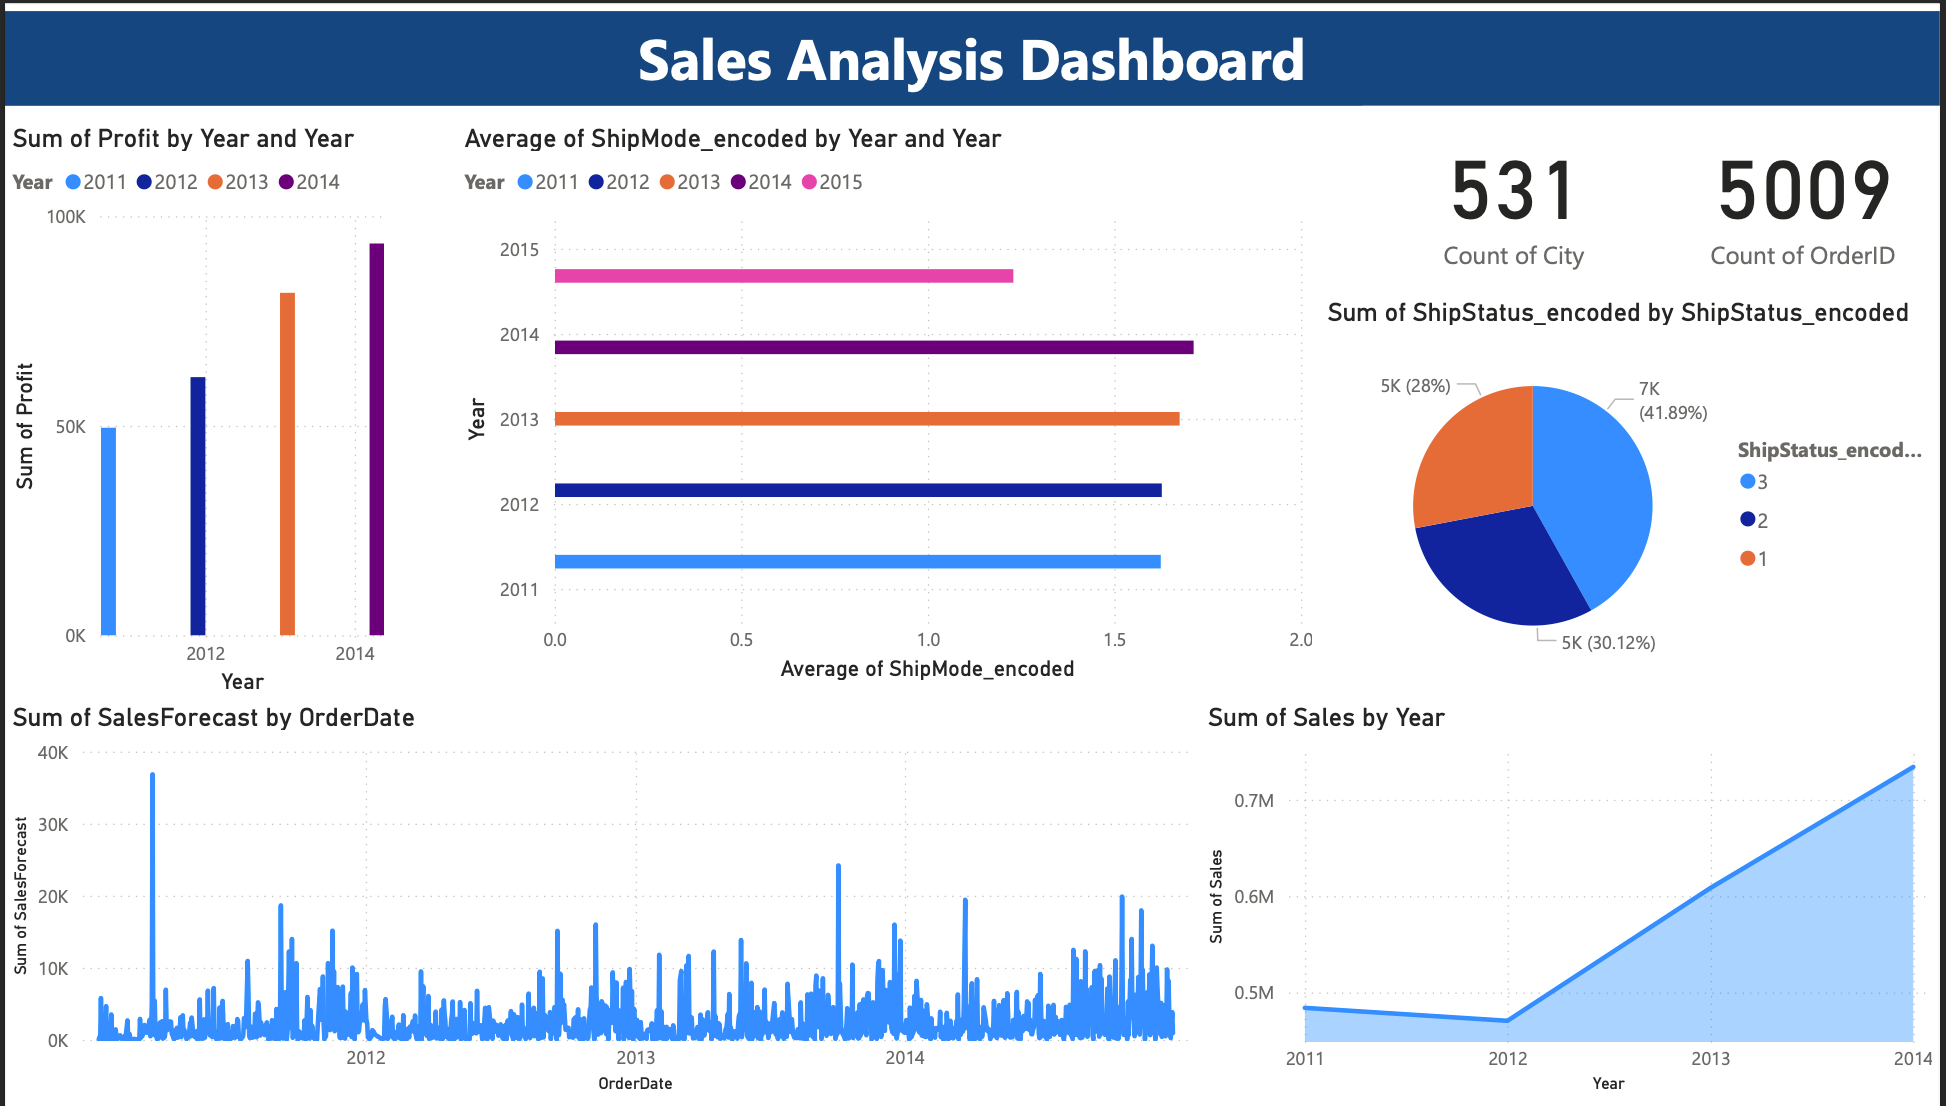

Insights

### **1. Profit Growth Over Time**

* The **sum of profit** steadily increased from **2011 to 2014**, with the most significant jump between **2012 and 2013**, and again from **2013 to 2014**.
* This indicates improving **operational efficiency** or better **pricing strategies** over the years.

---

### **2. Shipment Mode Trends**

* The **average `ShipMode_encoded`** value increased until **2014**, then **dropped in 2015**.
* This suggests a possible **shift to simpler or slower shipping modes** in 2015, or a change in how shipping is being categorized.

---

### **3. Geographic and Order Coverage**

* **531 unique cities** and **5009 total orders** are recorded, indicating a **broad national presence** and **moderate order volume**.
* This scale allows for regional performance analysis.

---

### **4. Shipment Status Distribution**

* **ShipStatus\_encoded = 3** (blue) makes up the largest portion at **\~42%**
* The other two statuses (`2` and `1`) are almost evenly split (\~30% each).
* This distribution may reflect different fulfillment or delivery outcomes; **status 3 likely indicates success**, but would need decoding to confirm.

---

### **5. Sales Forecast Trends**

* The **sales forecast** (bottom-left graph) shows a steady and **increasing trend** in expected sales over time with **seasonal spikes**.
* Suggests **growth in demand** and potentially **well-performing predictive models**.

---

### **6. Actual Sales Performance**

* The **sum of sales** has grown significantly, especially between **2012 and 2014**, surpassing **\$700,000 by 2014**.
* Indicates **strong revenue growth** aligning with profit growth.

---

### Summary Recommendations:

* Continue investing in regions with increasing forecast spikes.
* Investigate what led to the **dip in ShipMode\_encoded average** in 2015 — did shipping changes affect customer experience or costs?
* Analyze **profit margins by ship status** to optimize fulfillment strategy.
* Use peak periods from forecast data to plan inventory and promotions.
